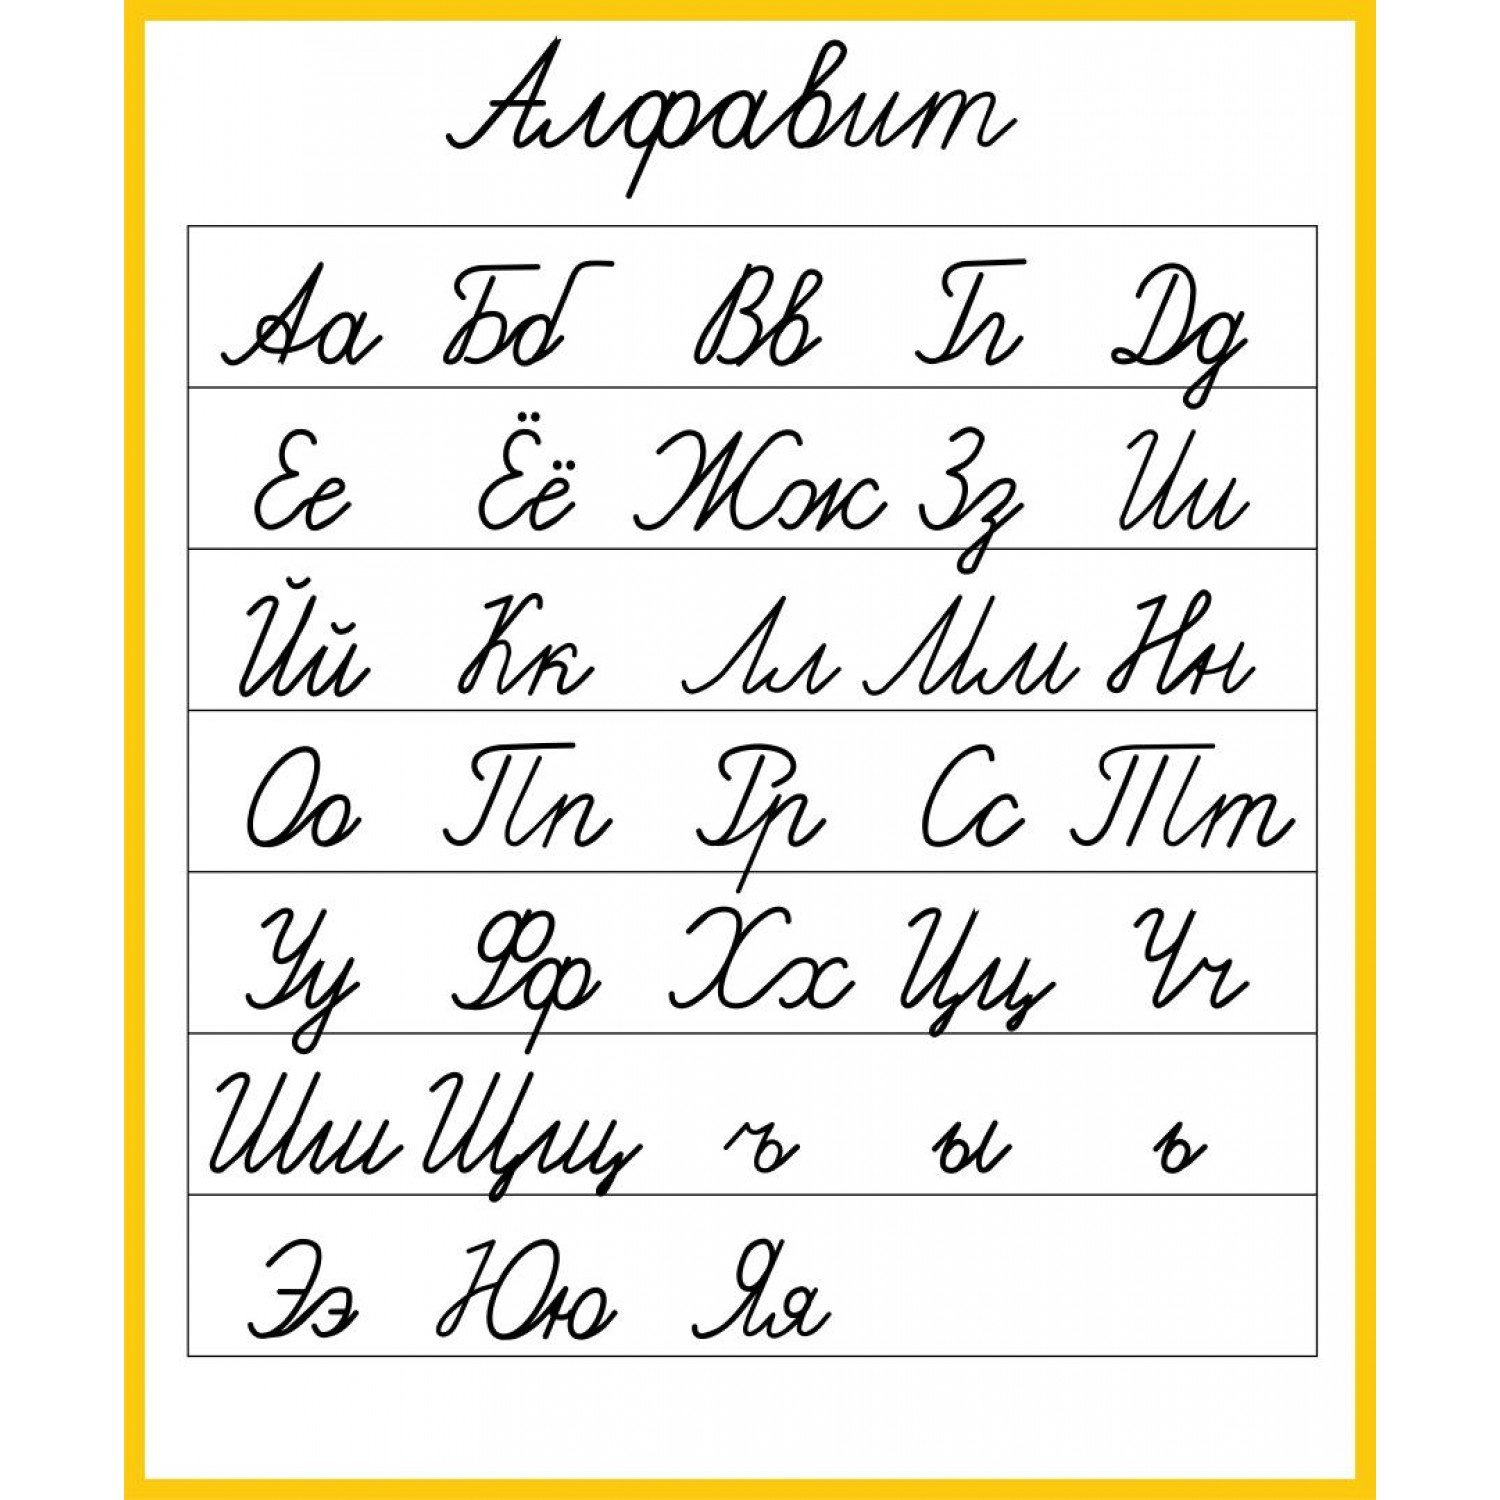

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image

display(Image(filename='alphabet_rus.jpg', width=490))


In [2]:
import importlib
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image
# Перезагрузка модуля. Надо перезагружать эту ячейку, если что-то поменяли в генераторе
importlib.reload(importlib.import_module('mnist_synthetic.lower_case_letters_generator'))
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator

generator = LowerCaseLettersGenerator(seed=42)

transform_nearest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.NEAREST),
])

transform_bilinear = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize(28, interpolation=transforms.InterpolationMode.BILINEAR),
])

transform_bicubic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.BICUBIC),
])  

In [3]:
def plot_single_image(img, label: str):
    """Отображает одно изображение без аугментаций."""
    if img.ndim == 3 and img.shape[0] == 1:
        img = img[0]  # (1, H, W) -> (H, W)
    elif img.ndim == 3 and img.shape[2] == 1:
        img = img[:, :, 0]  # (H, W, 1) -> (H, W)

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Label: {label} | Shape: {img.shape}')
    plt.axis('off')
    plt.show()

In [4]:
# У меня Винда, а на ней torch не хочет делать bicubic интерполяцию без преобразования в pil
def tensor_to_pil(img):
    # img: np.ndarray (H, W) или (H, W, 1)
    if img.ndim == 3 and img.shape[2] == 1:
        img = img[:, :, 0]
    return Image.fromarray(img, mode='L')  # 'L' = grayscale

def plot_rotated_with_interpolations(img, label: str, angle: int = 30):
    pil_img = tensor_to_pil(img)

    # Все интерполяции работают с PIL
    rot_n = transforms.RandomRotation((angle, angle), interpolation=transforms.InterpolationMode.NEAREST)
    rot_b = transforms.RandomRotation((angle, angle), interpolation=transforms.InterpolationMode.BILINEAR)
    rot_c = transforms.RandomRotation((angle, angle), interpolation=transforms.InterpolationMode.BICUBIC)

    img_n = transforms.ToTensor()(rot_n(pil_img)).squeeze().numpy()
    img_b = transforms.ToTensor()(rot_b(pil_img)).squeeze().numpy()
    img_c = transforms.ToTensor()(rot_c(pil_img)).squeeze().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(img_n, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f'NEAREST ({angle}°)')
    axes[1].axis('off')

    axes[2].imshow(img_b, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'BILINEAR ({angle}°)')
    axes[2].axis('off')

    axes[3].imshow(img_c, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f'BICUBIC ({angle}°)')
    axes[3].axis('off')

    plt.suptitle(f'Label: {label}')
    plt.tight_layout()
    plt.show()

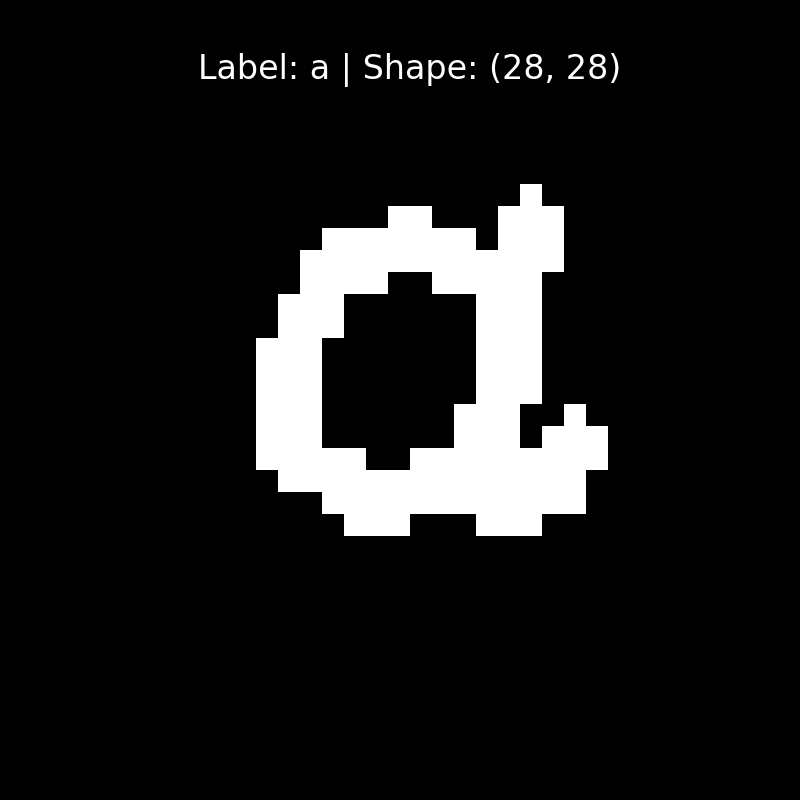

In [5]:
# Генерация изображений
img = generator.generate_а()
label = 'а'
plot_single_image(img, label)

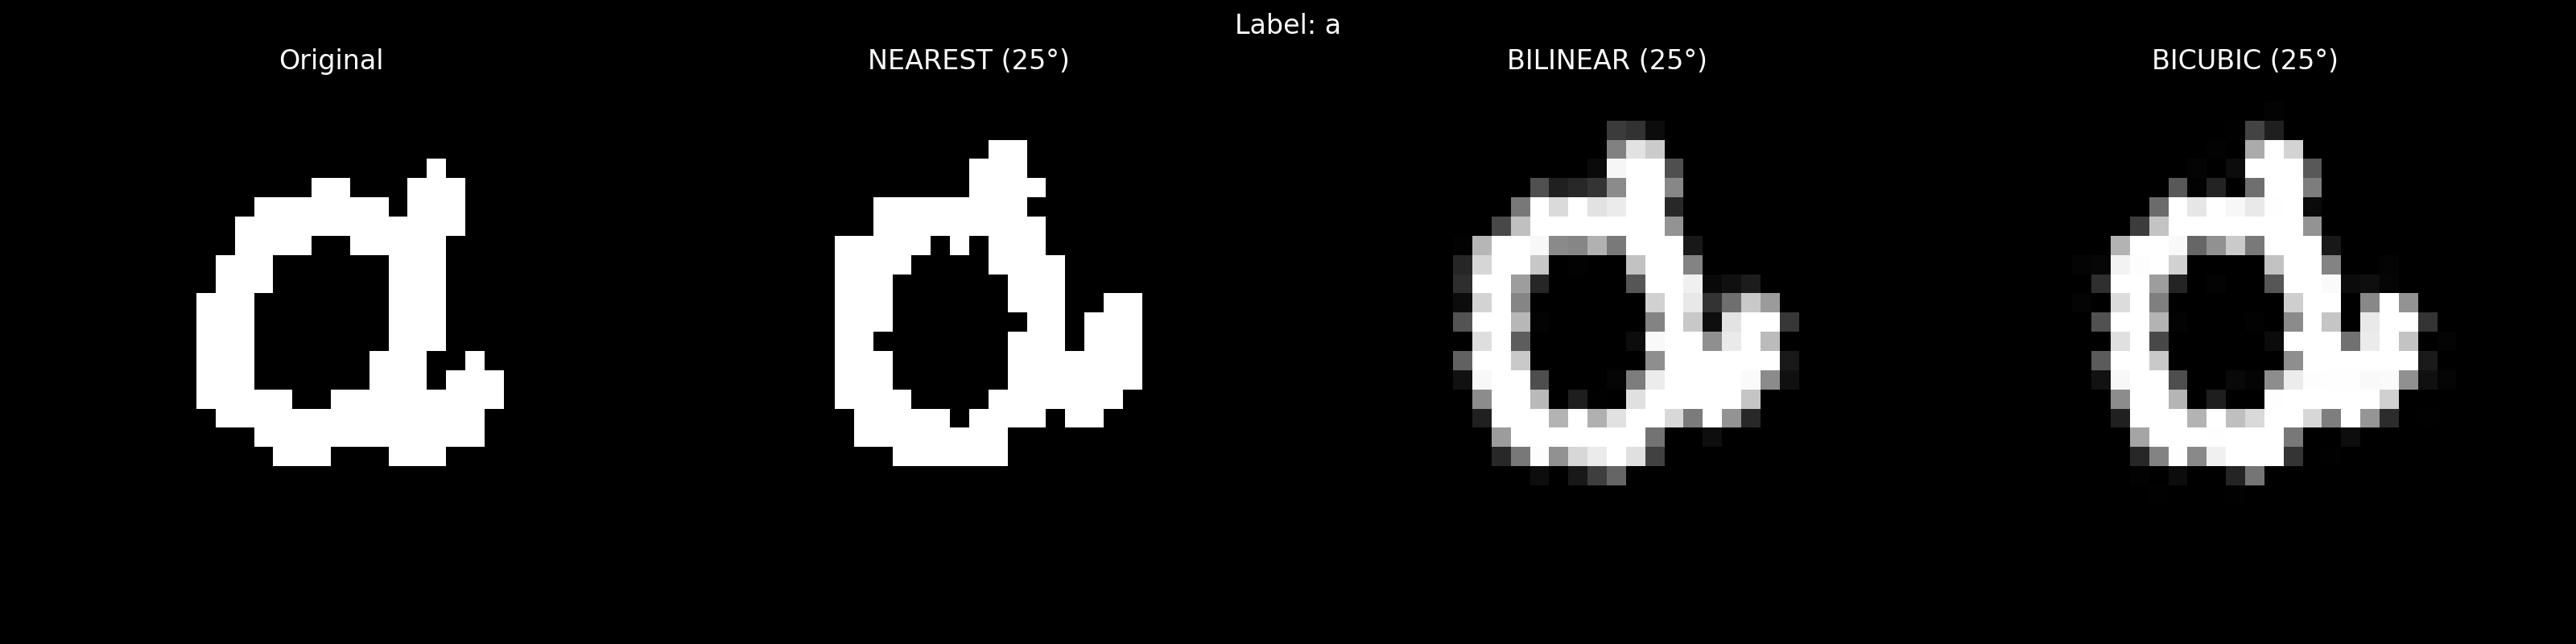

In [6]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['а'])
plot_rotated_with_interpolations(img, label, angle=25)

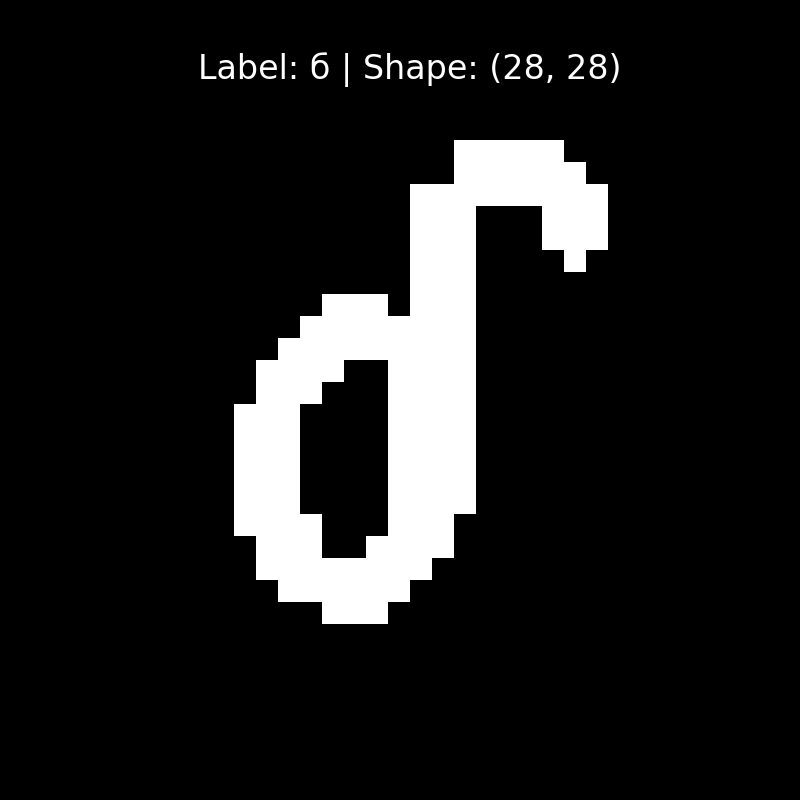

In [7]:
img = generator.generate_б()
label = 'б'
plot_single_image(img, label)

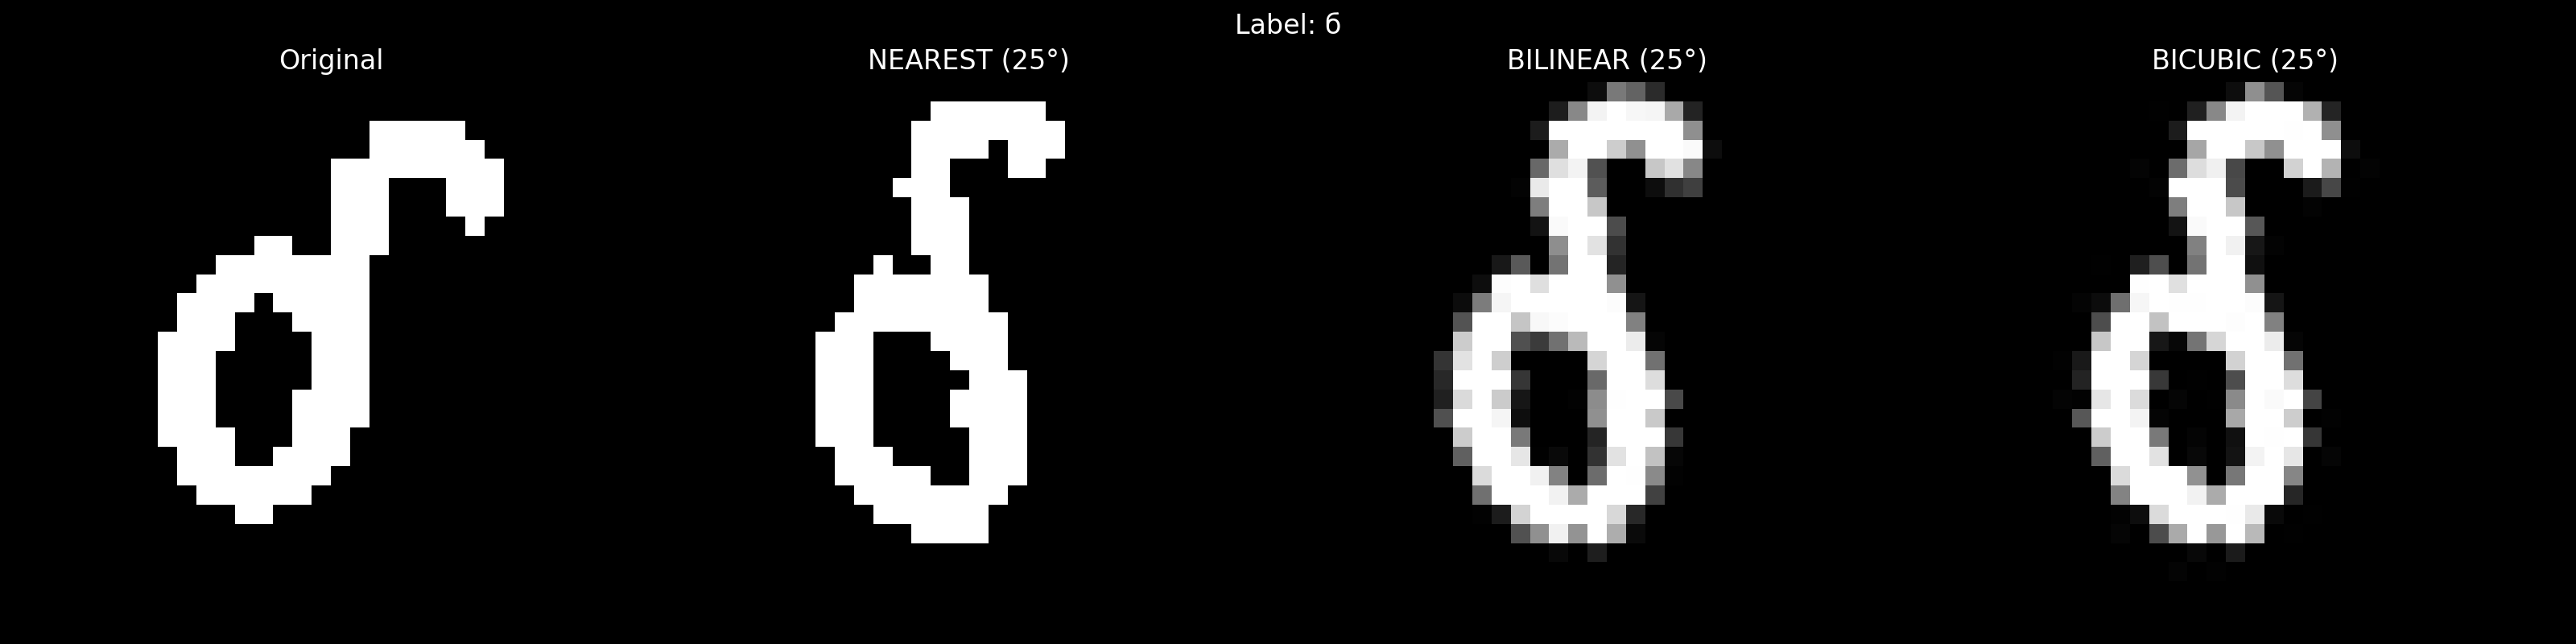

In [8]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['б'])
plot_rotated_with_interpolations(img, label, angle=25)

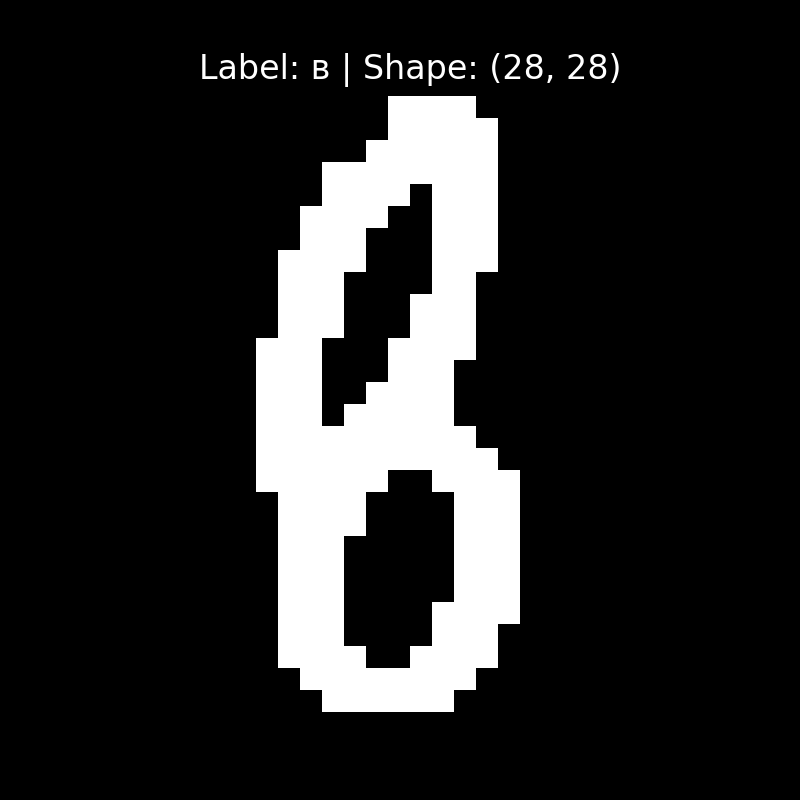

In [9]:
img = generator.generate_в()
label = 'в'
plot_single_image(img, label)

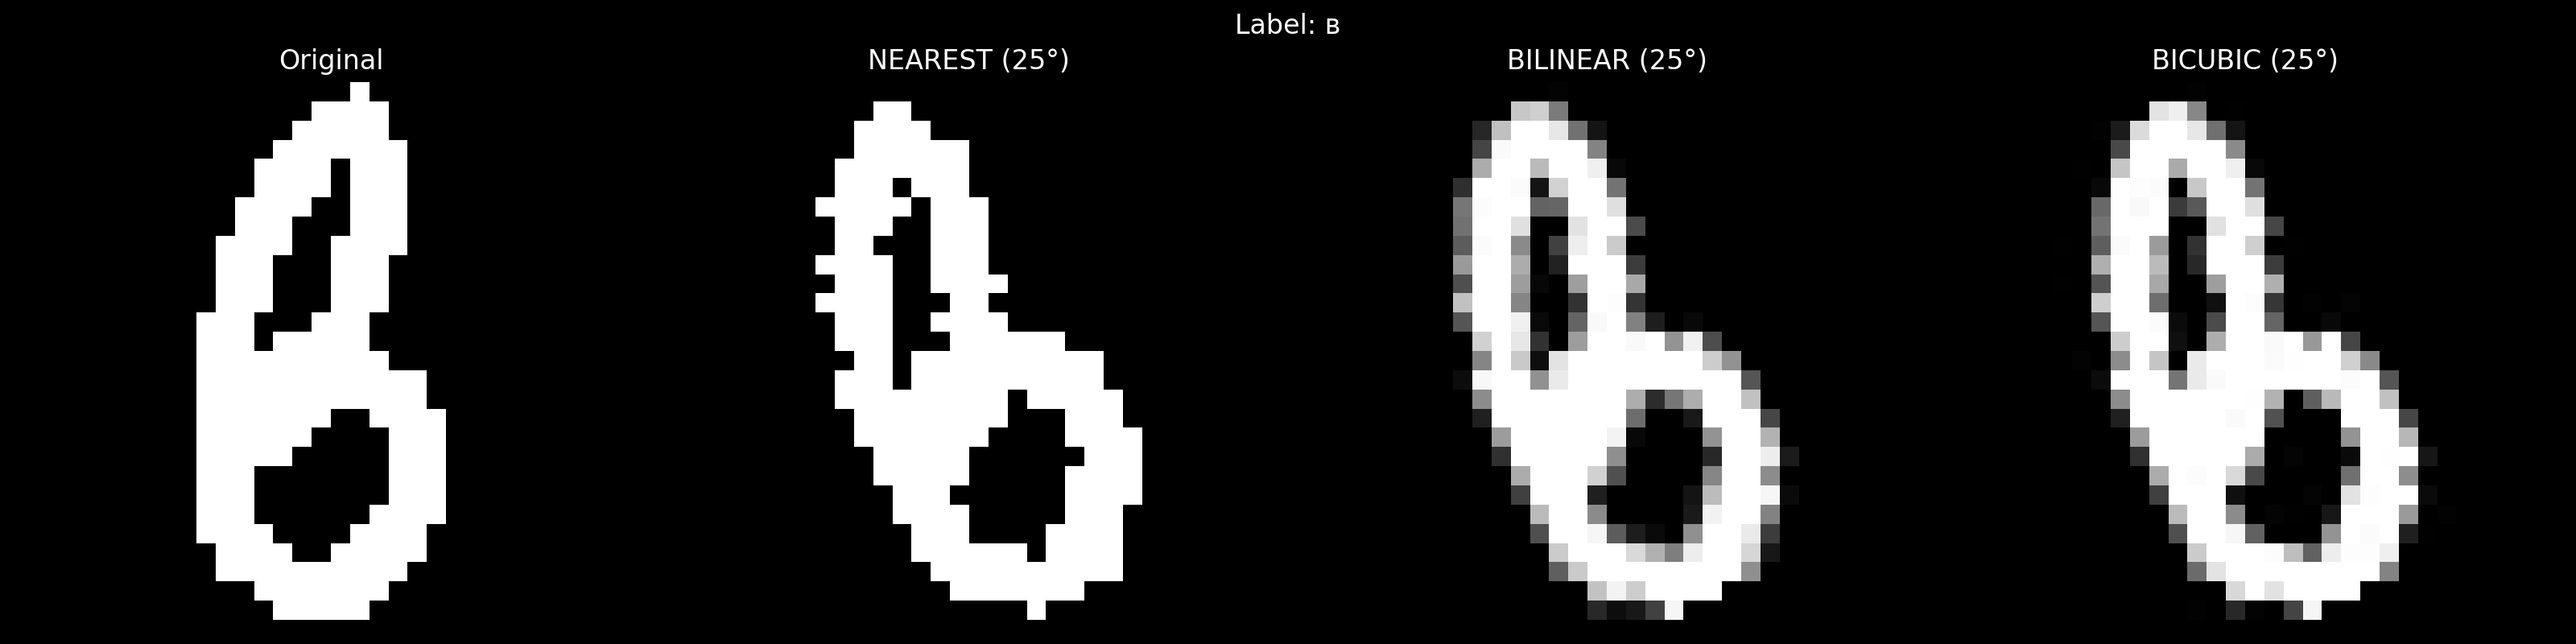

In [10]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['в'])
plot_rotated_with_interpolations(img, label, angle=25)

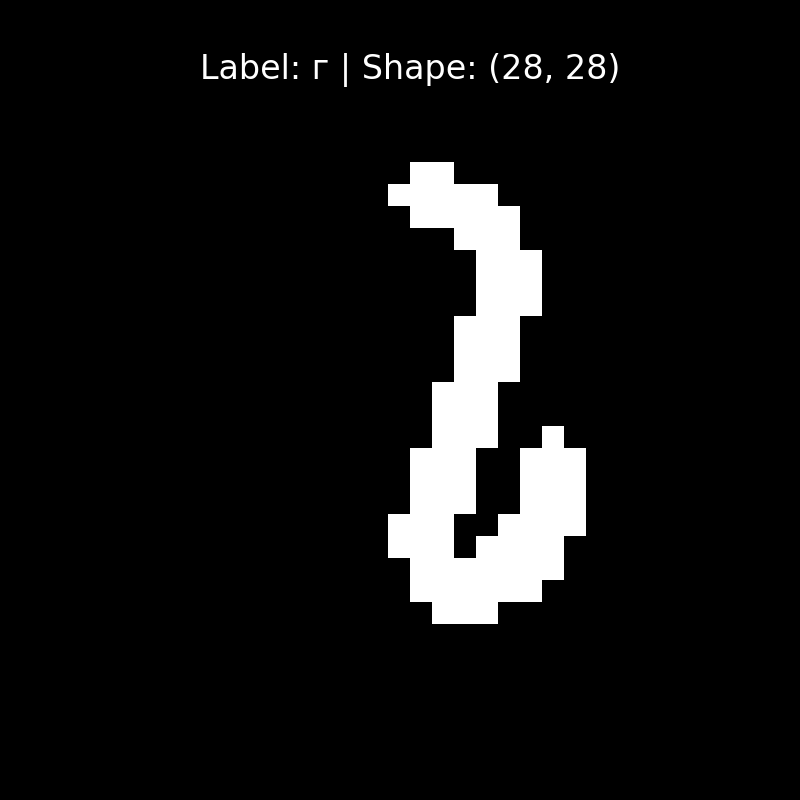

In [11]:
# Генерация изображений
img = generator.generate_г()
label = 'г'
plot_single_image(img, label)

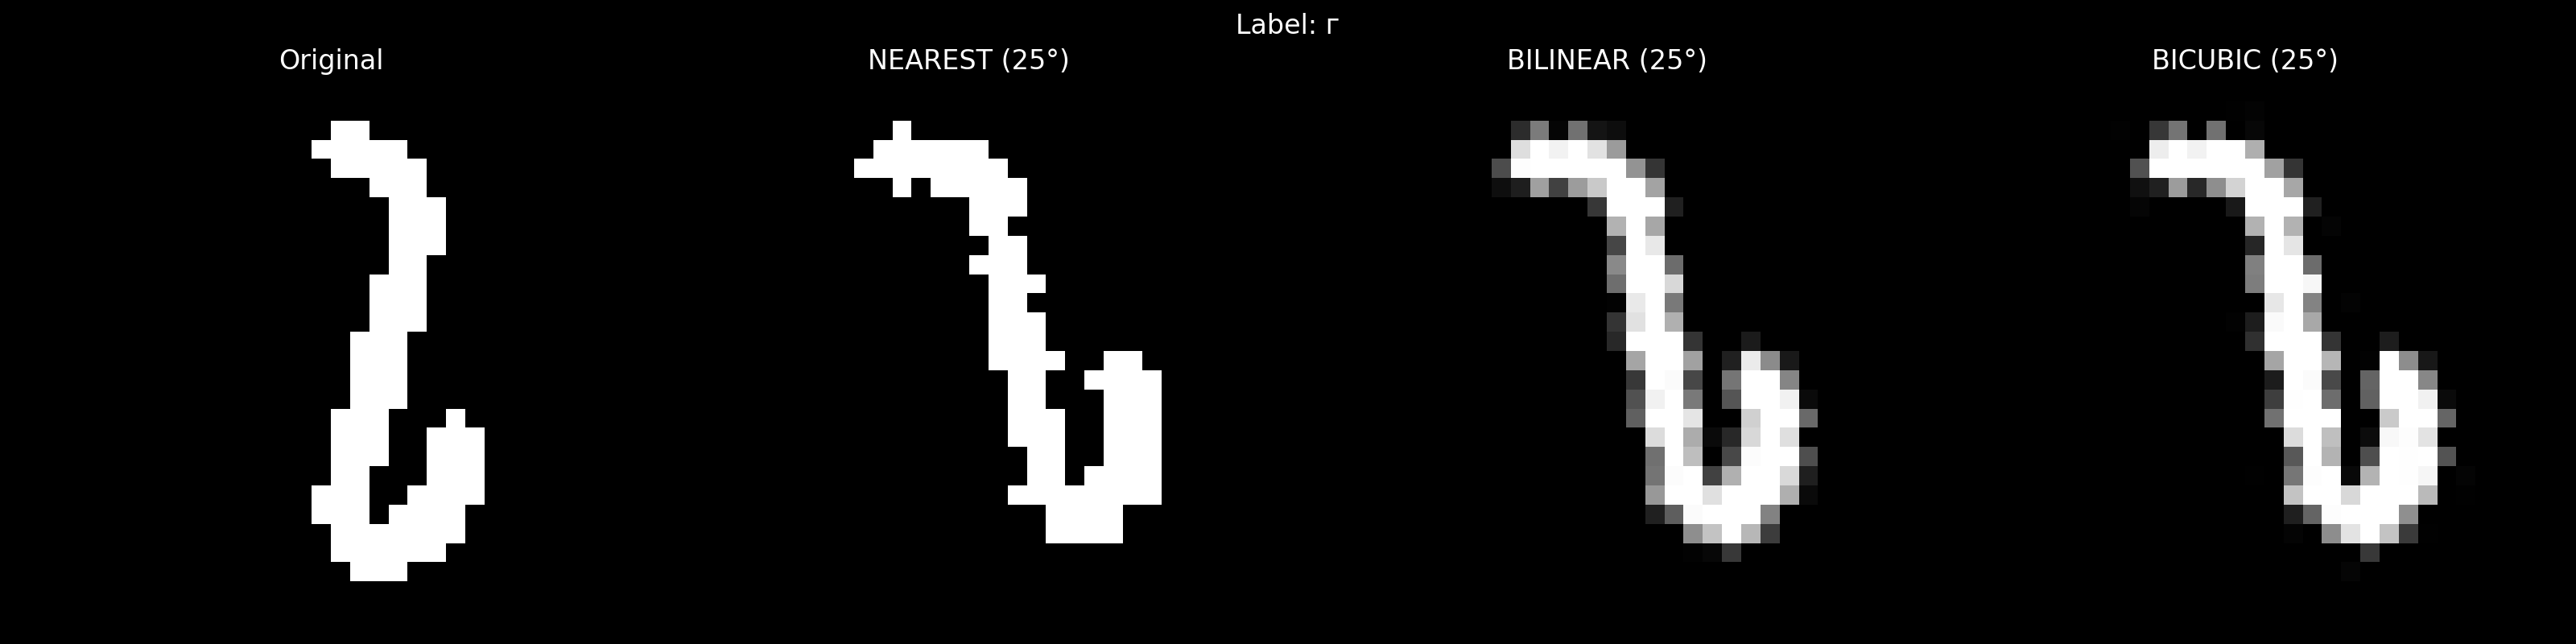

In [12]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['г'])
plot_rotated_with_interpolations(img, label, angle=25)

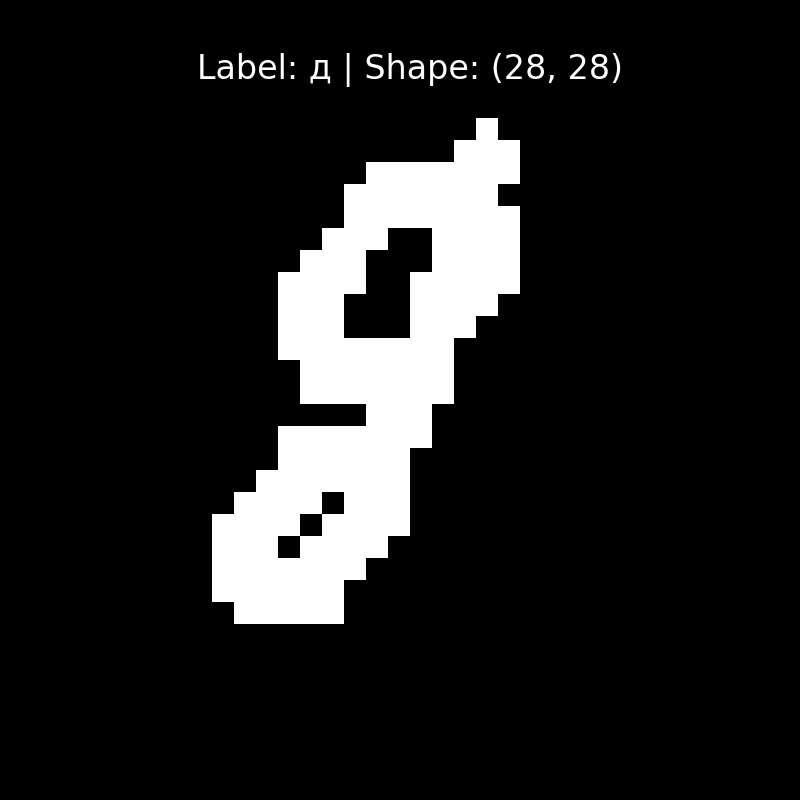

In [13]:
# Генерация изображений
# Не доделано
img = generator.generate_д()
label = 'д'
plot_single_image(img, label)

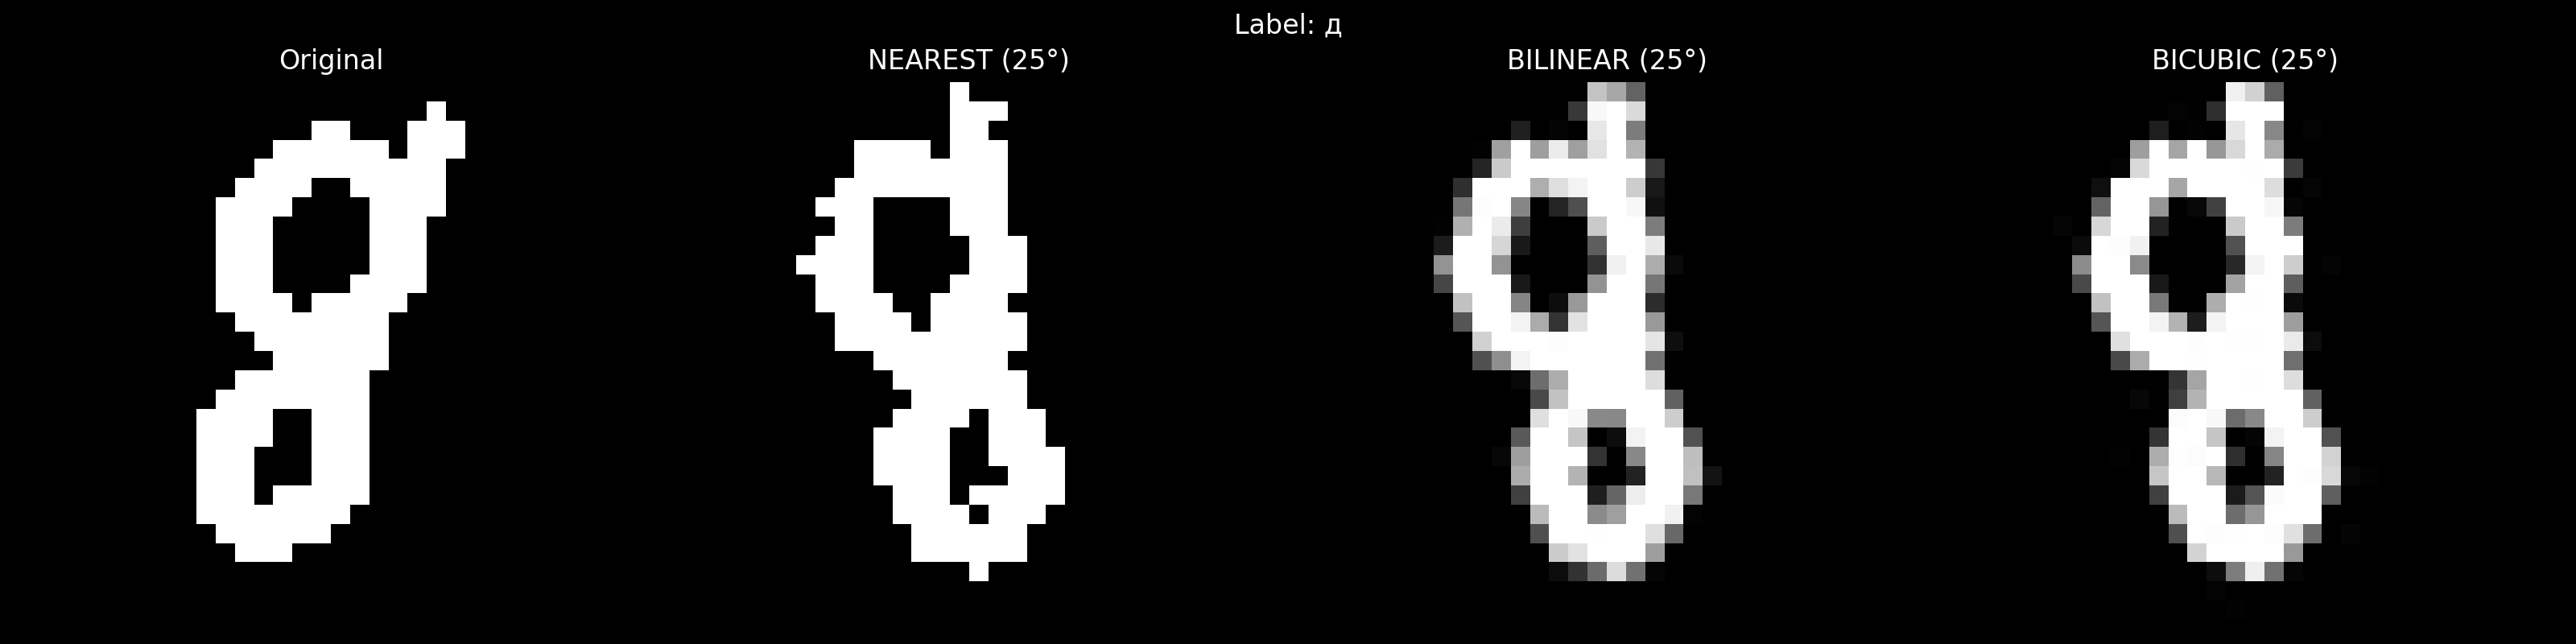

In [14]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['д'])
plot_rotated_with_interpolations(img, label, angle=25)

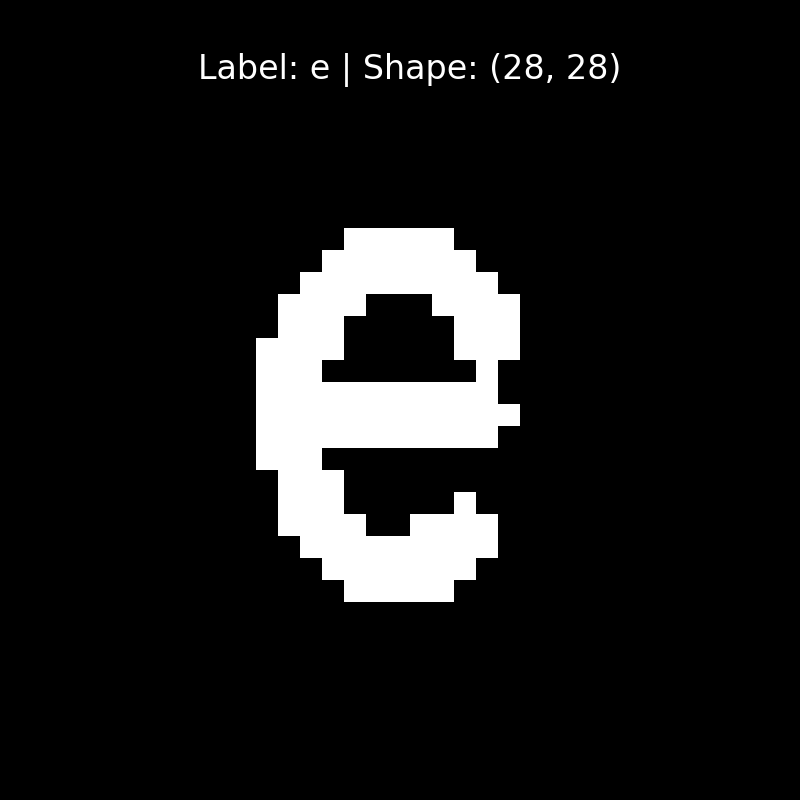

In [15]:
# Генерация изображений
# Не доделано
img = generator.generate_е()
label = 'е'
plot_single_image(img, label)

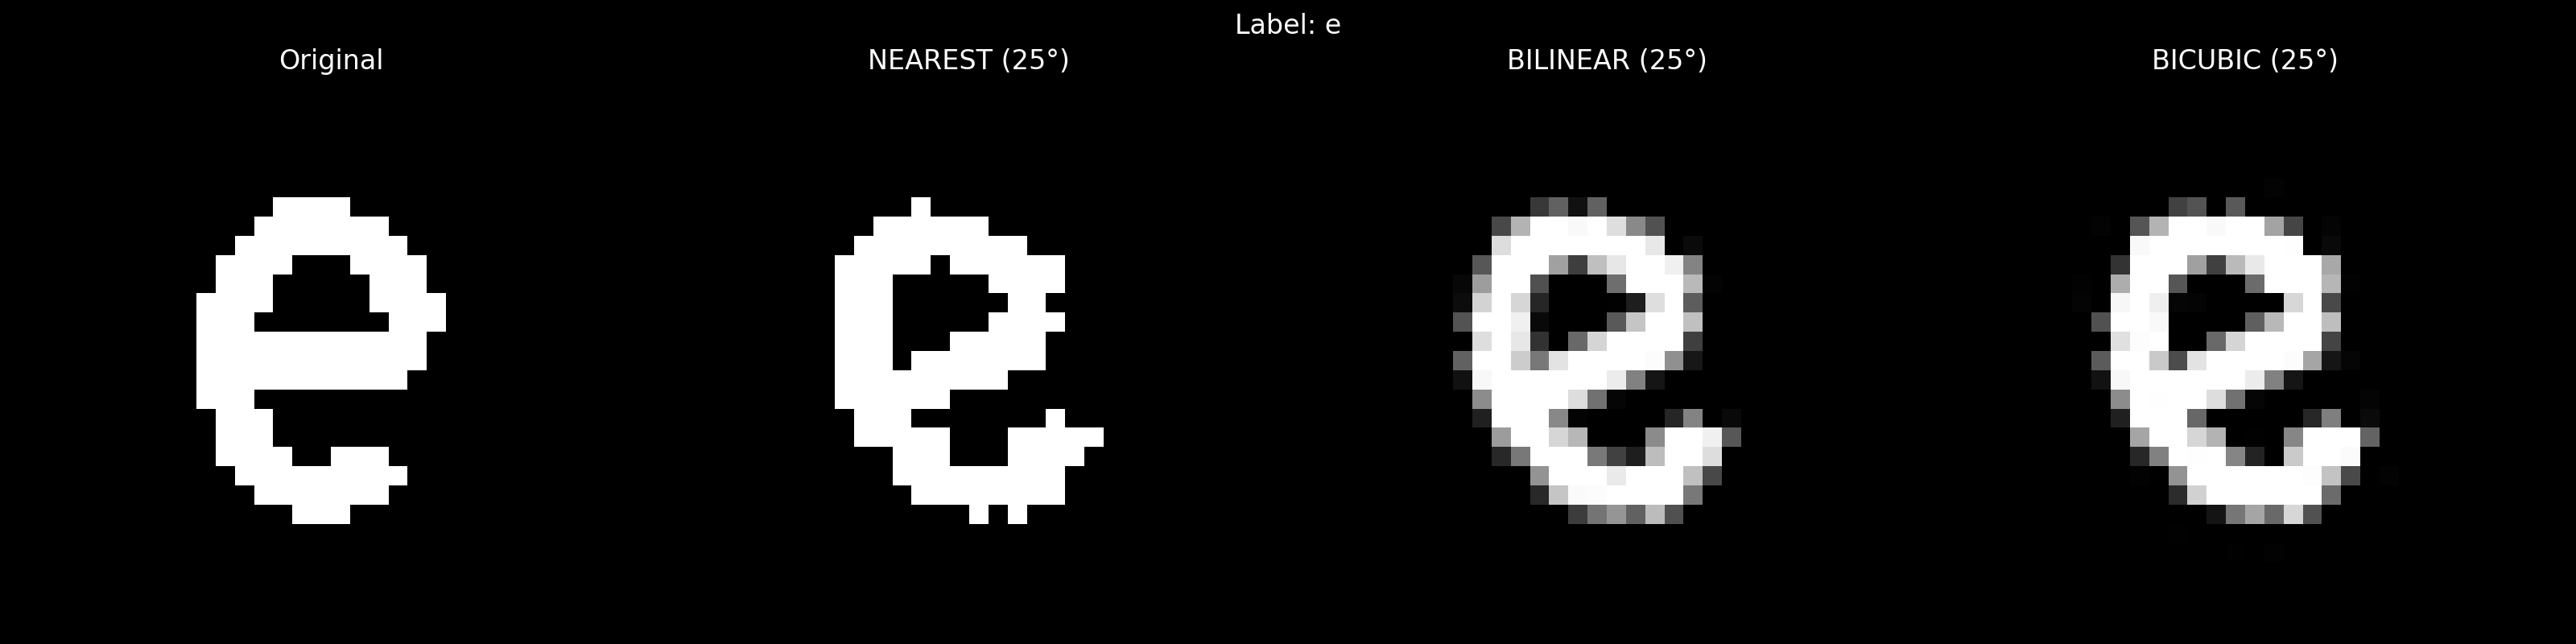

In [16]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['е'])
plot_rotated_with_interpolations(img, label, angle=25)

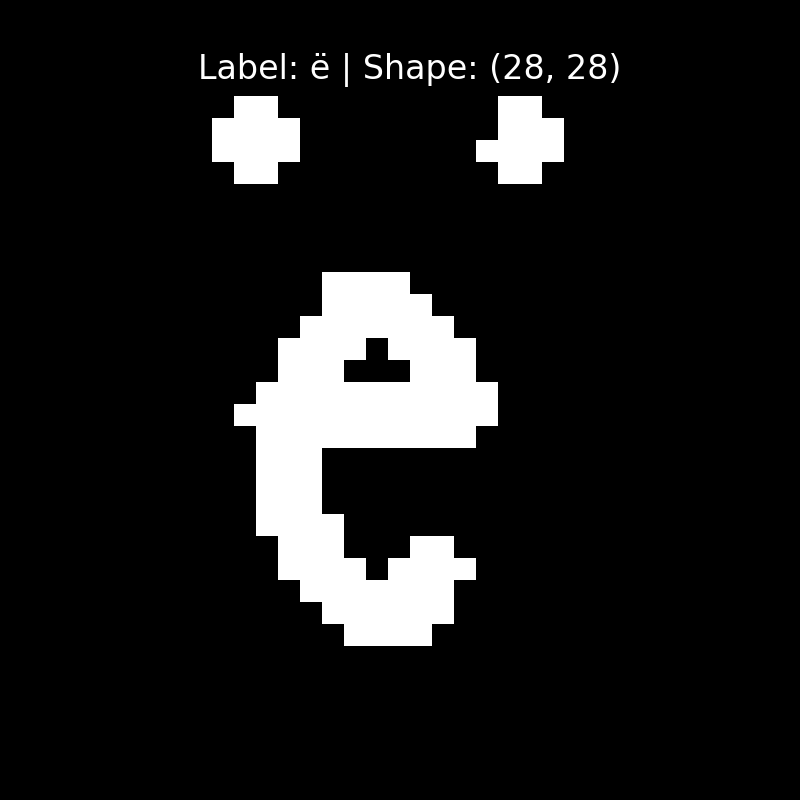

In [17]:
# Генерация изображений
# Не доделано
img = generator.generate_ё()
label = 'ё'
plot_single_image(img, label)

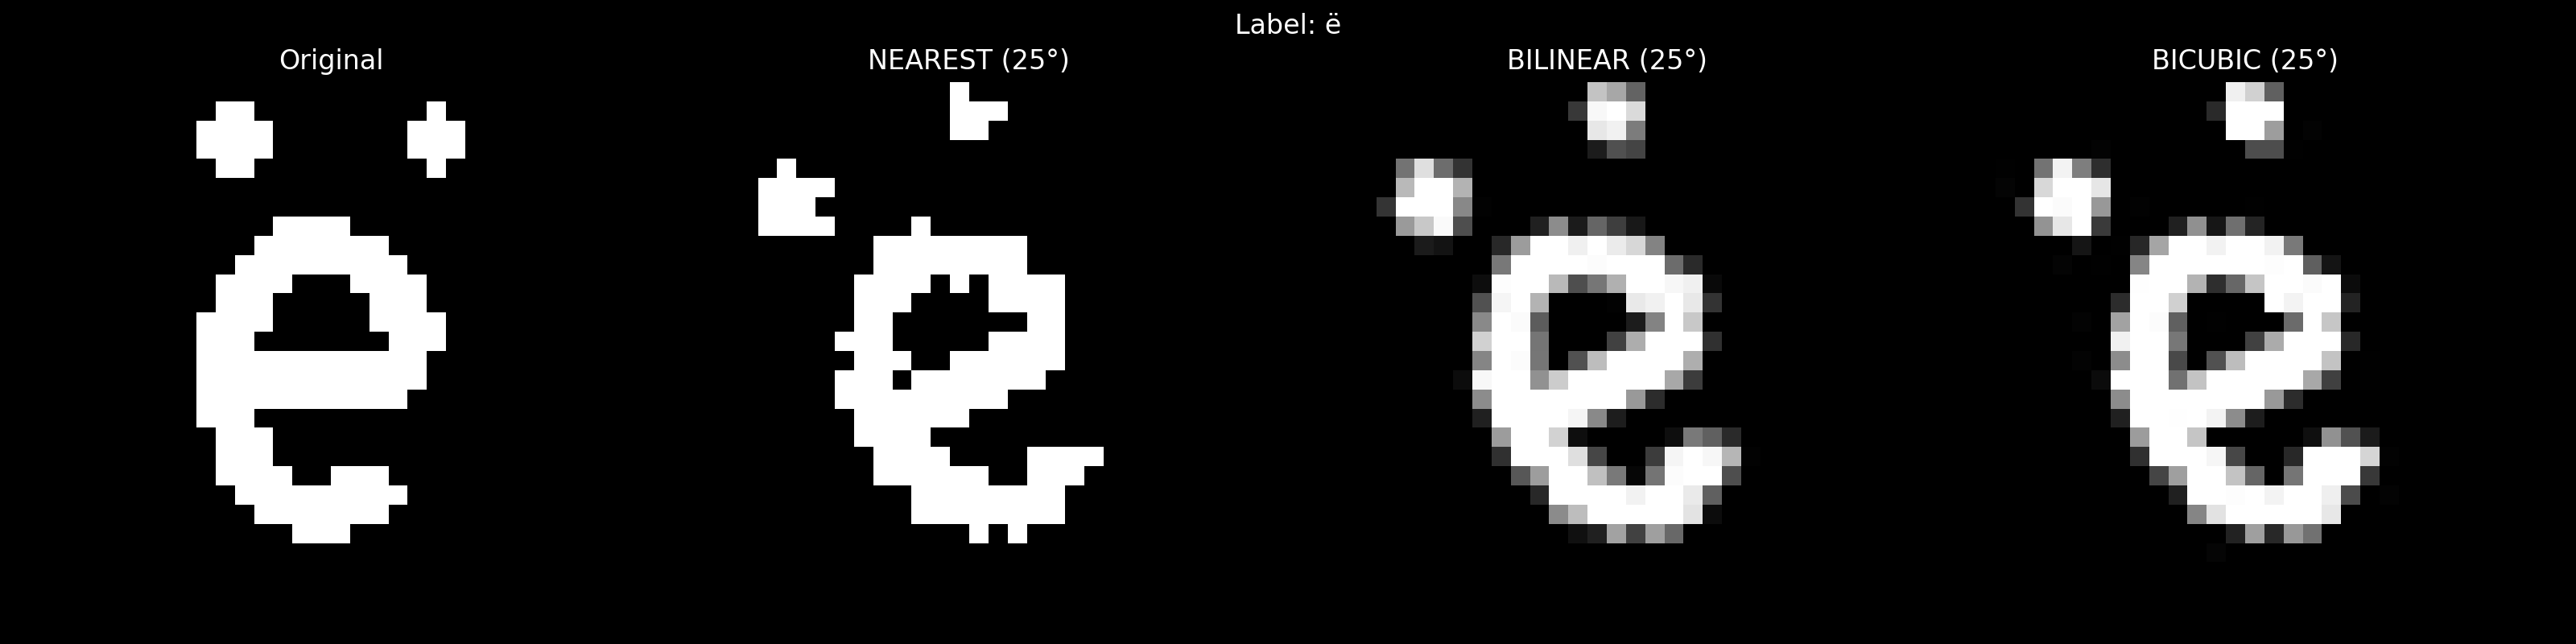

In [18]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ё'])
plot_rotated_with_interpolations(img, label, angle=25)

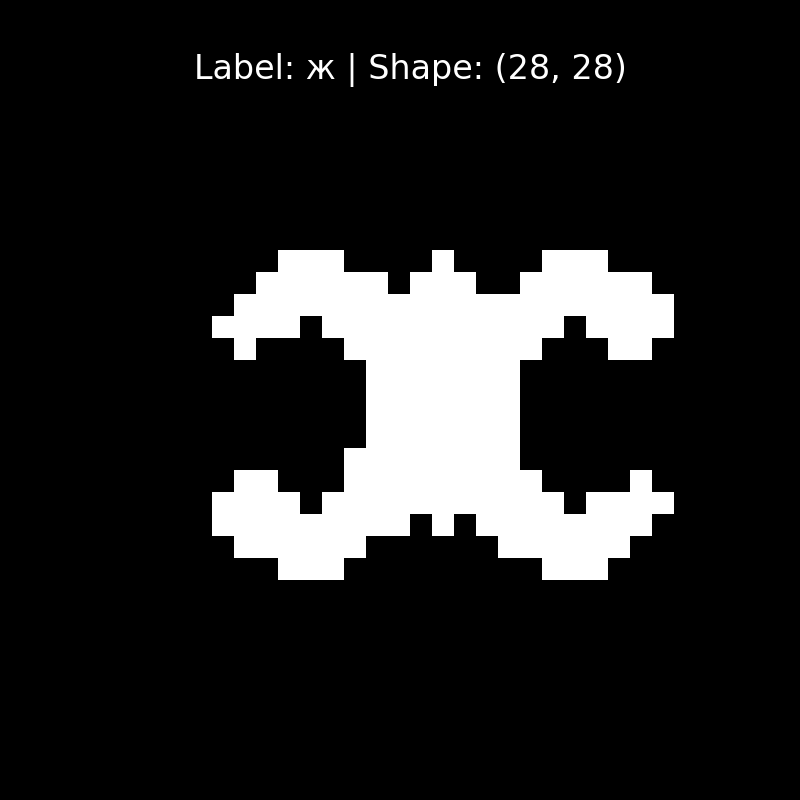

In [19]:
# Генерация изображений
# Не доделано
img = generator.generate_ж()
label = 'ж'
plot_single_image(img, label)

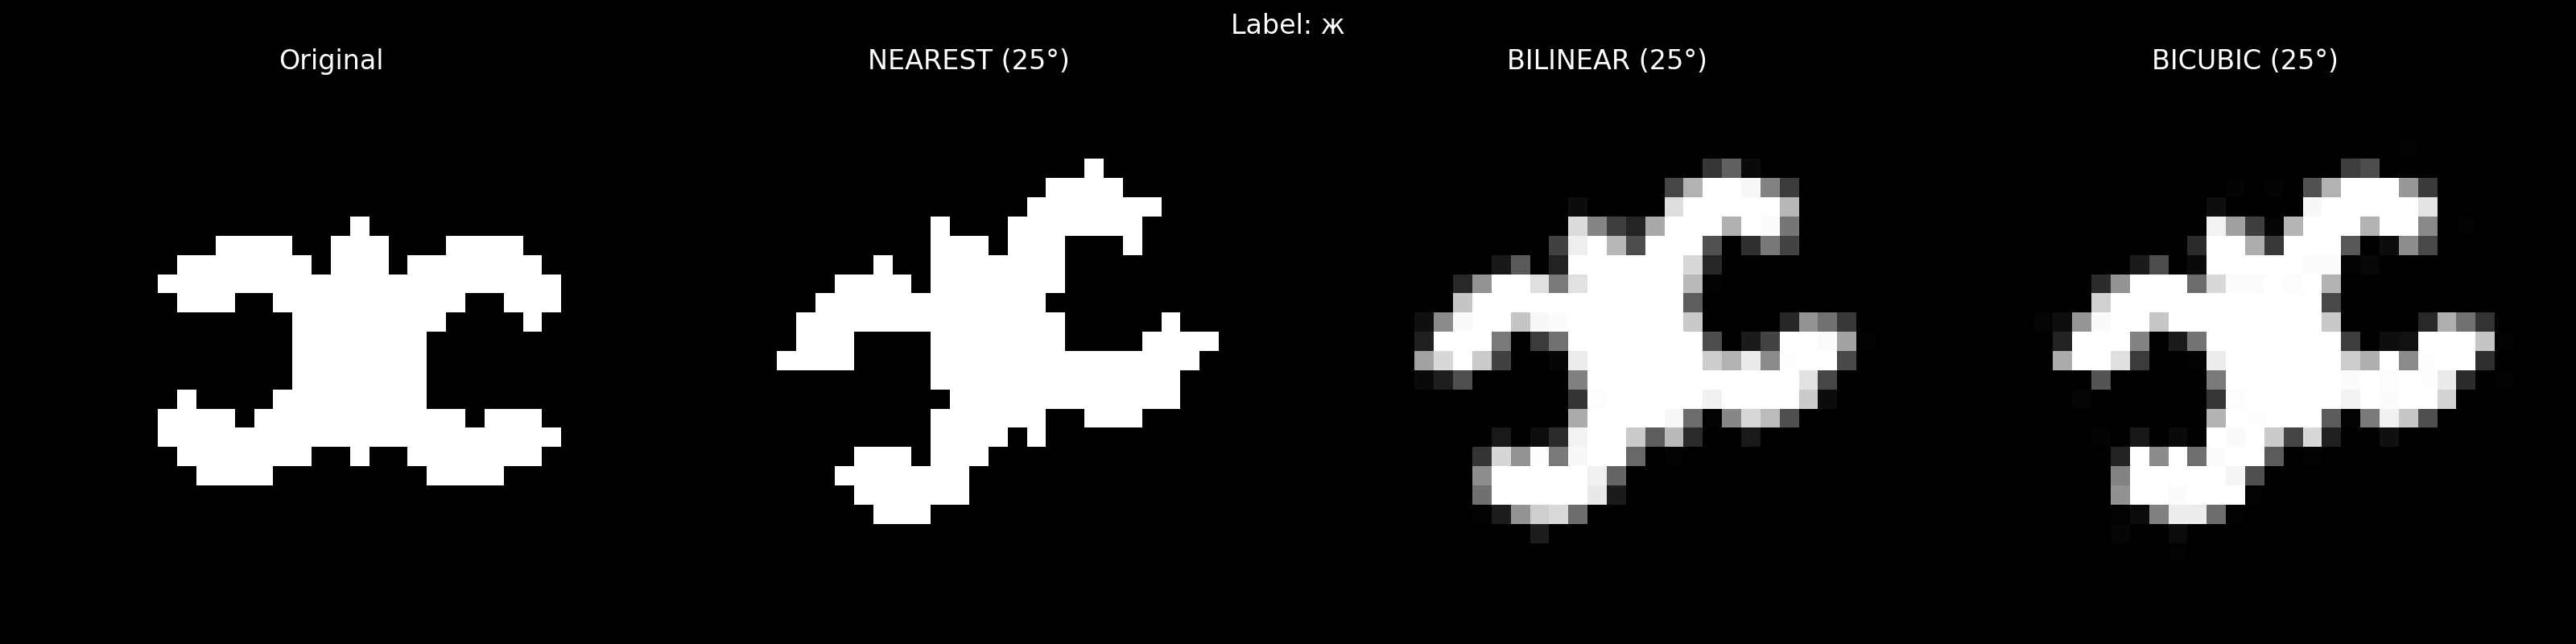

In [20]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ж'])
plot_rotated_with_interpolations(img, label, angle=25)

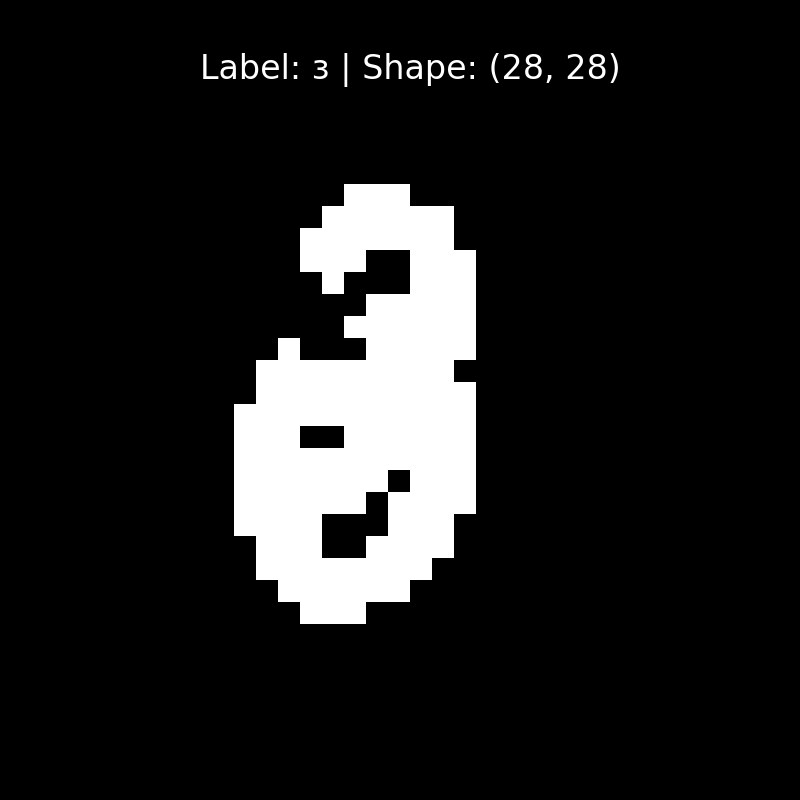

In [21]:
# Генерация изображений
# Не доделано
img = generator.generate_з()
label = 'з'
plot_single_image(img, label)

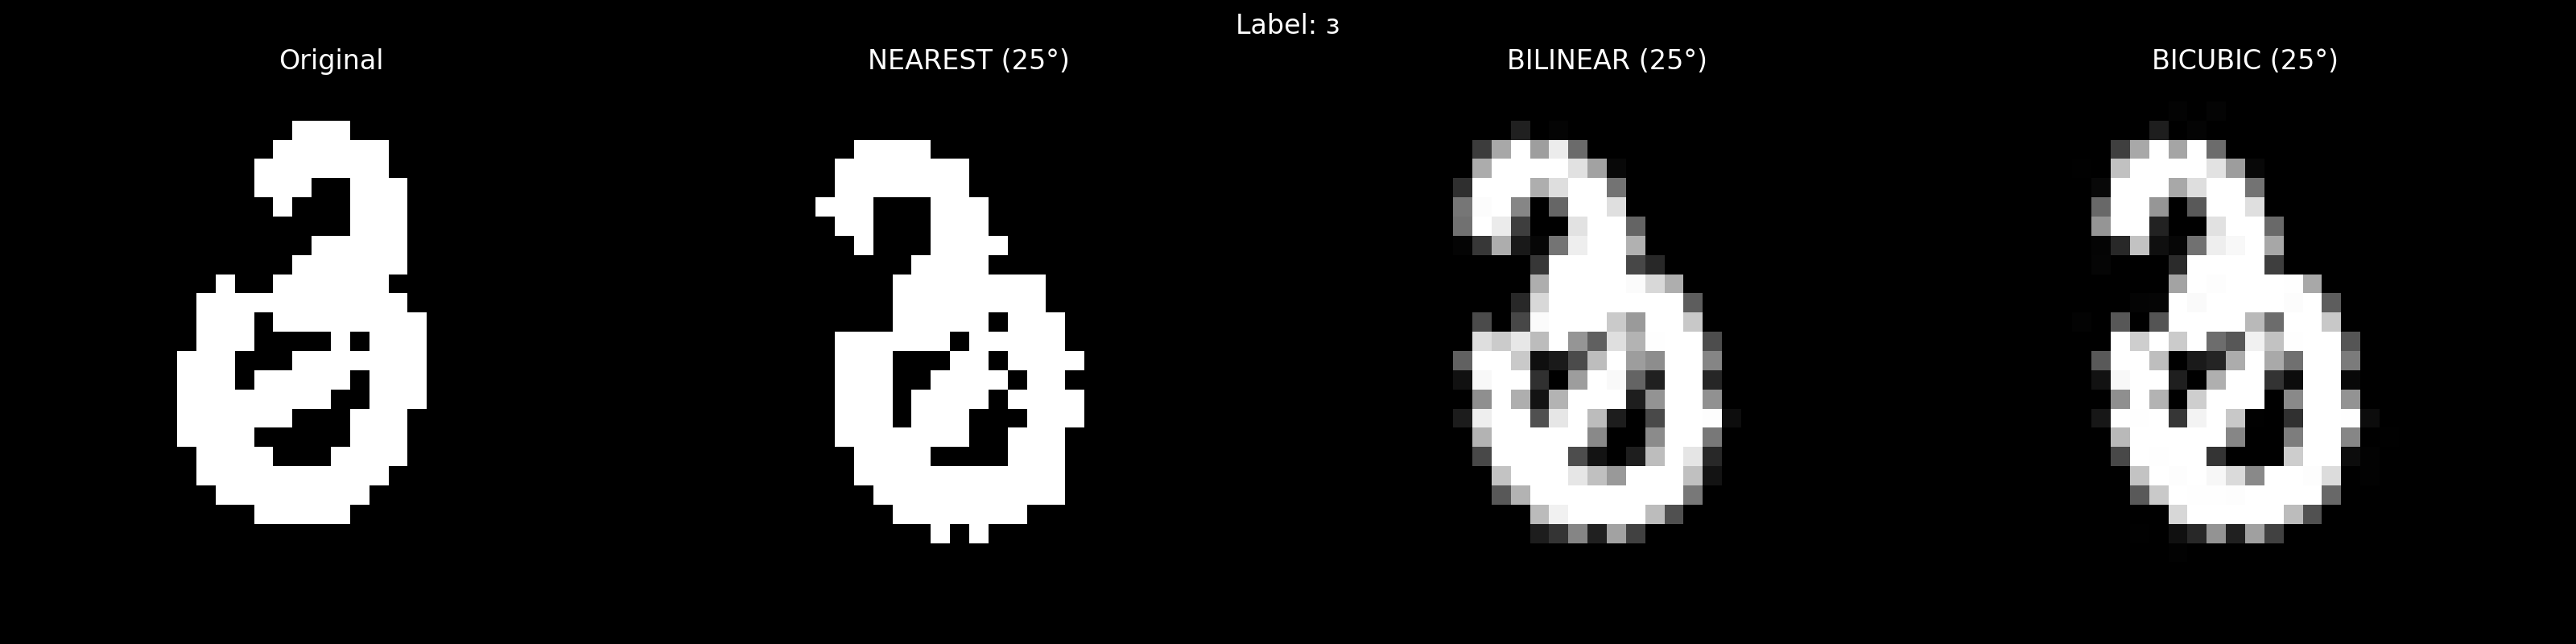

In [22]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['з'])
plot_rotated_with_interpolations(img, label, angle=25)

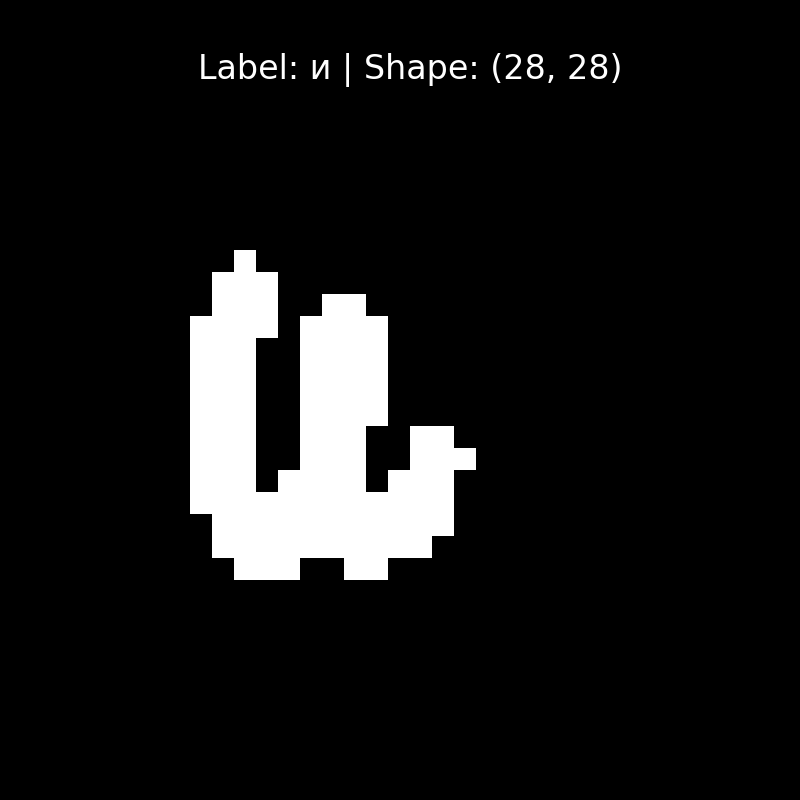

In [23]:
# Генерация изображений
# Не доделано
img = generator.generate_и()
label = 'и'
plot_single_image(img, label)

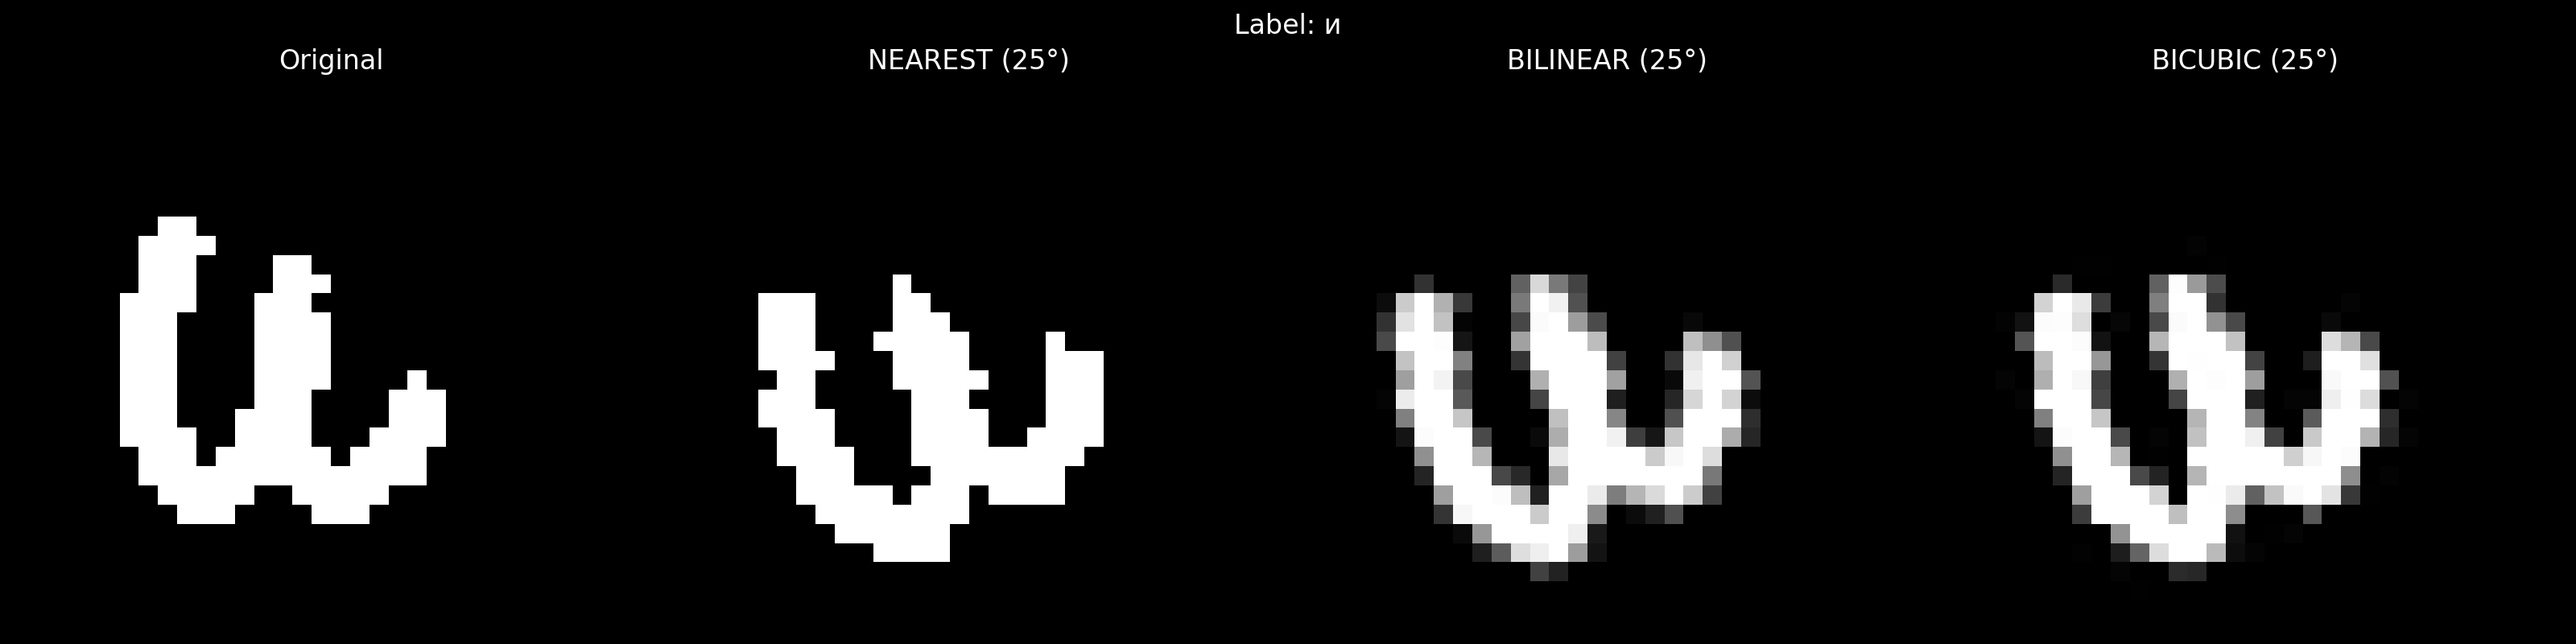

In [24]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['и'])
plot_rotated_with_interpolations(img, label, angle=25)

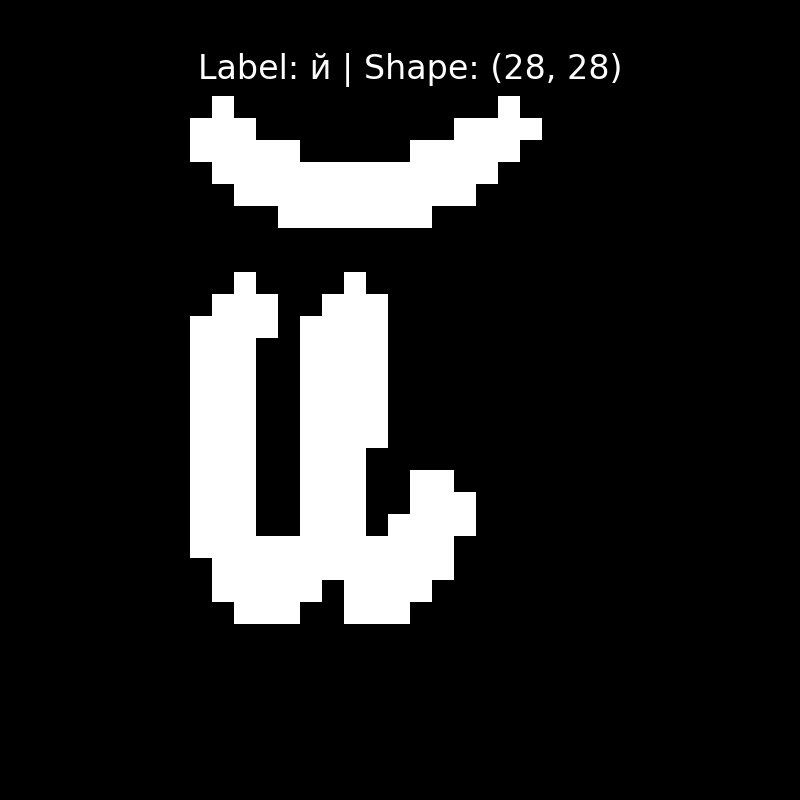

In [25]:
# Генерация изображений
img = generator.generate_й()
label = 'й'
plot_single_image(img, label)

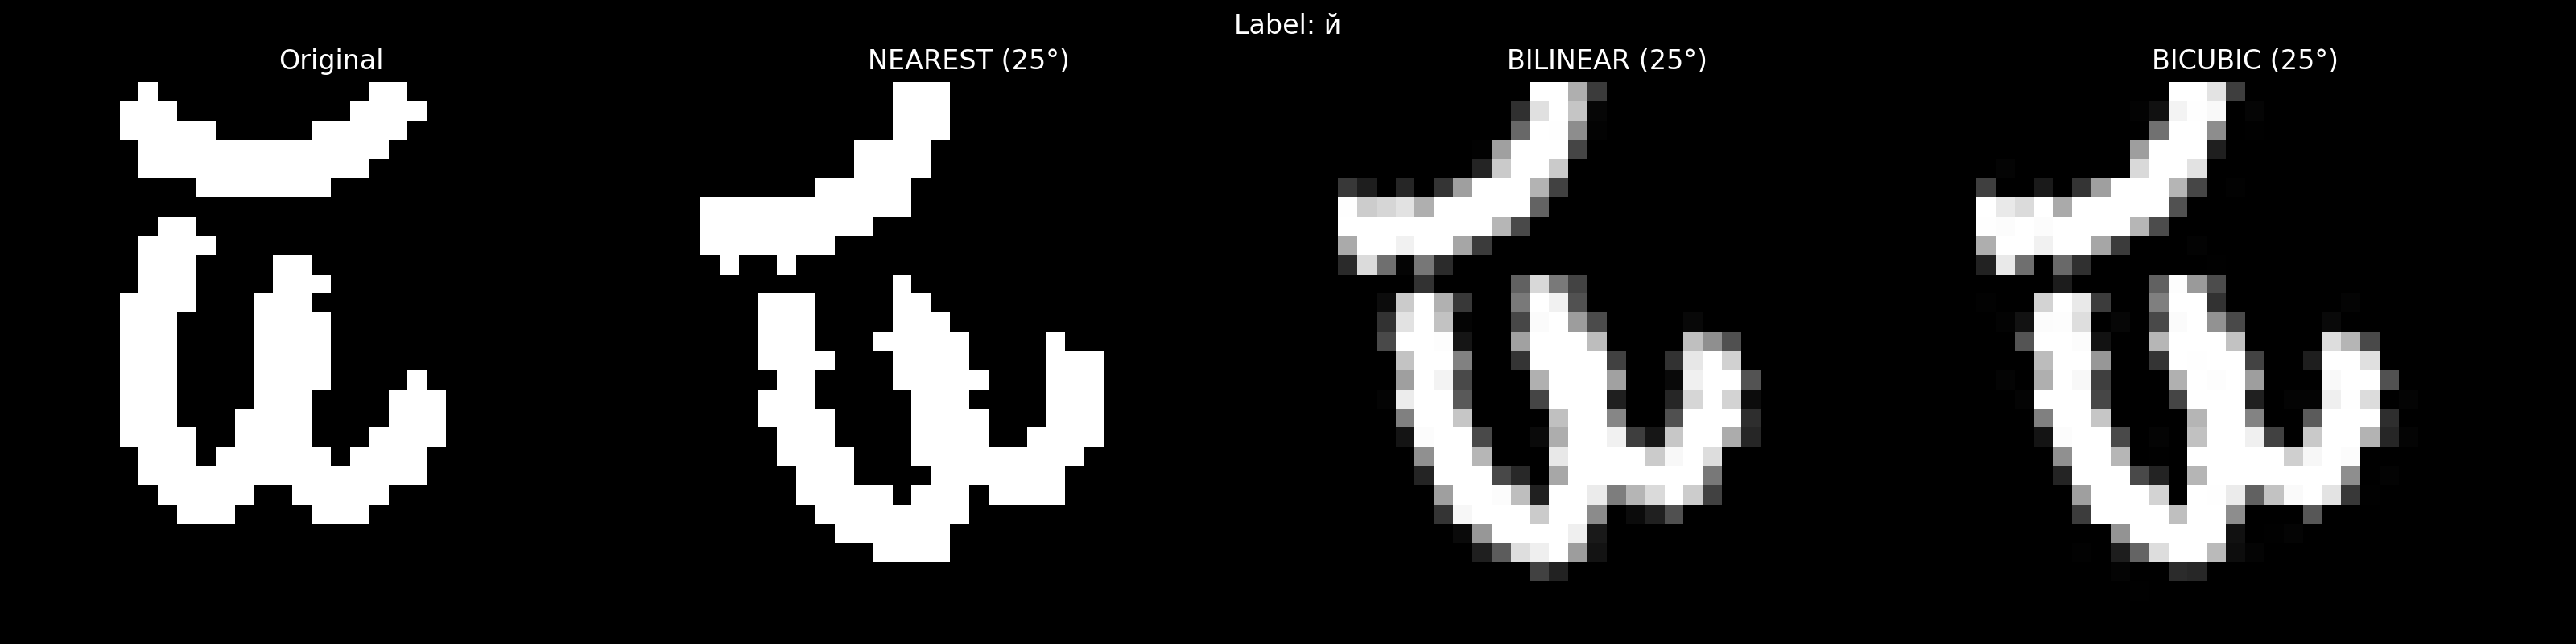

In [26]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['й'])
plot_rotated_with_interpolations(img, label, angle=25)

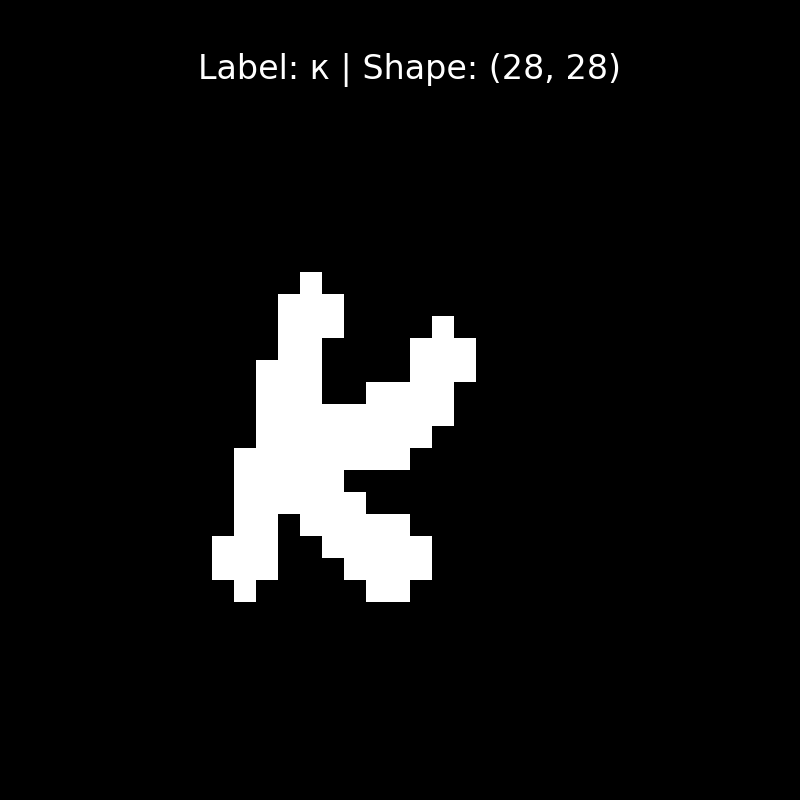

In [27]:
# Генерация изображений
img = generator.generate_к()
label = 'к'
plot_single_image(img, label)

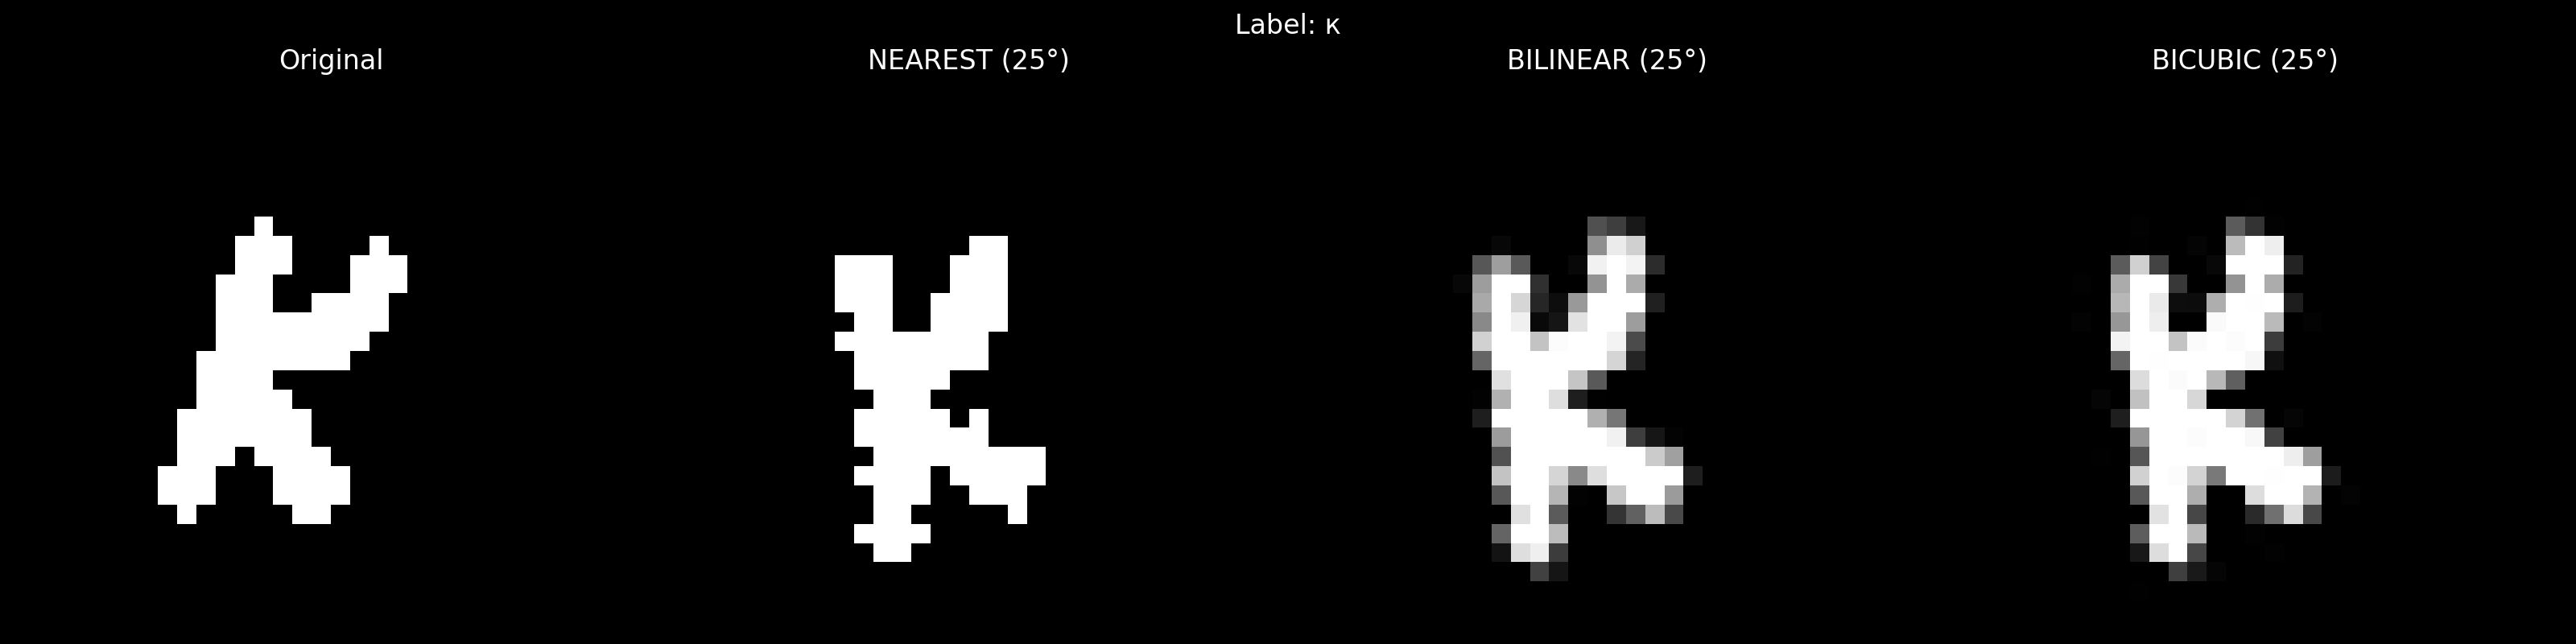

In [28]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['к'])
plot_rotated_with_interpolations(img, label, angle=25)

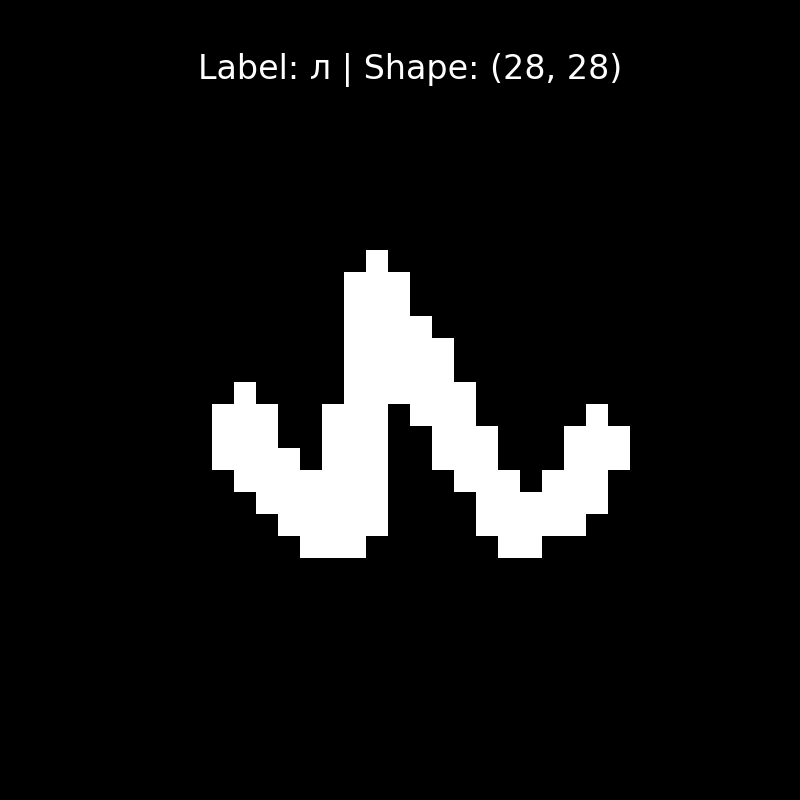

In [29]:
# Генерация изображений
img = generator.generate_л()
label = 'л'
plot_single_image(img, label)

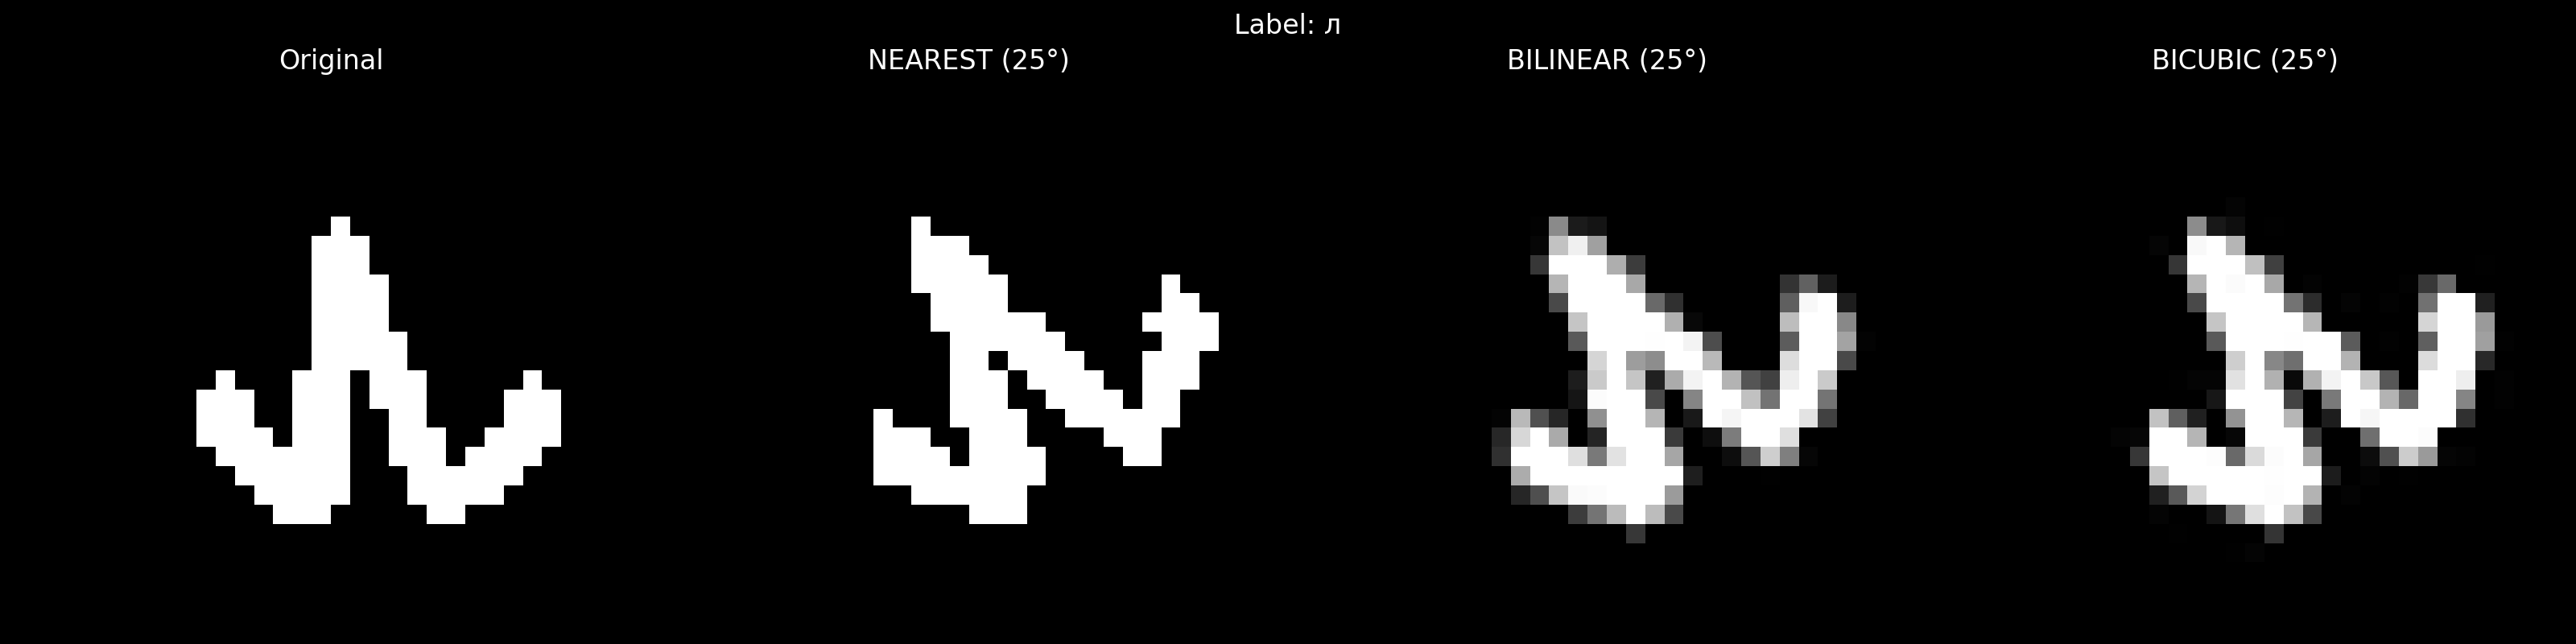

In [30]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['л'])
plot_rotated_with_interpolations(img, label, angle=25)

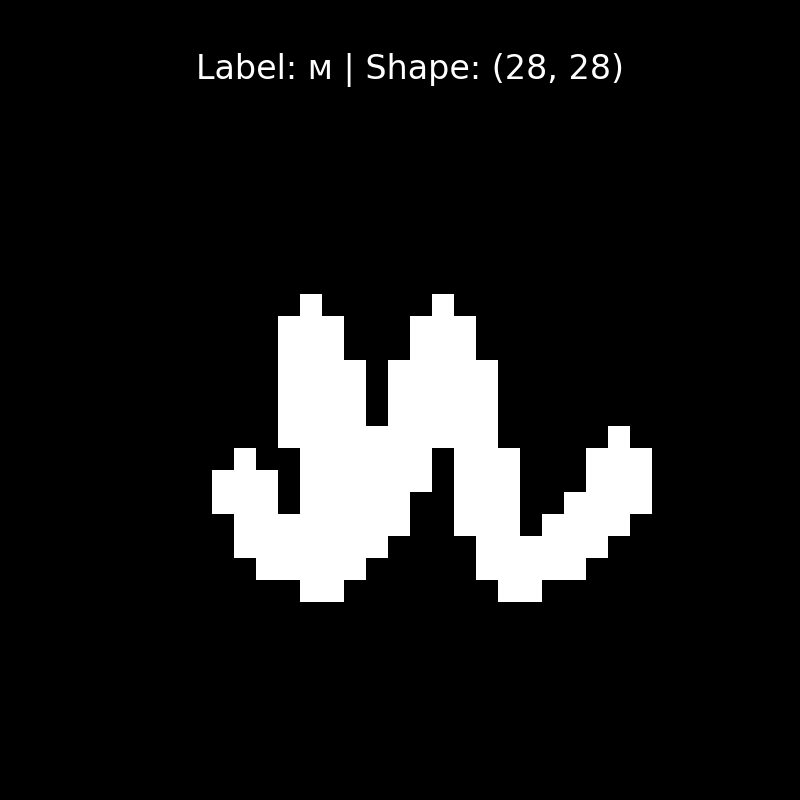

In [31]:
# Генерация изображений
img = generator.generate_м()
label = 'м'
plot_single_image(img, label)

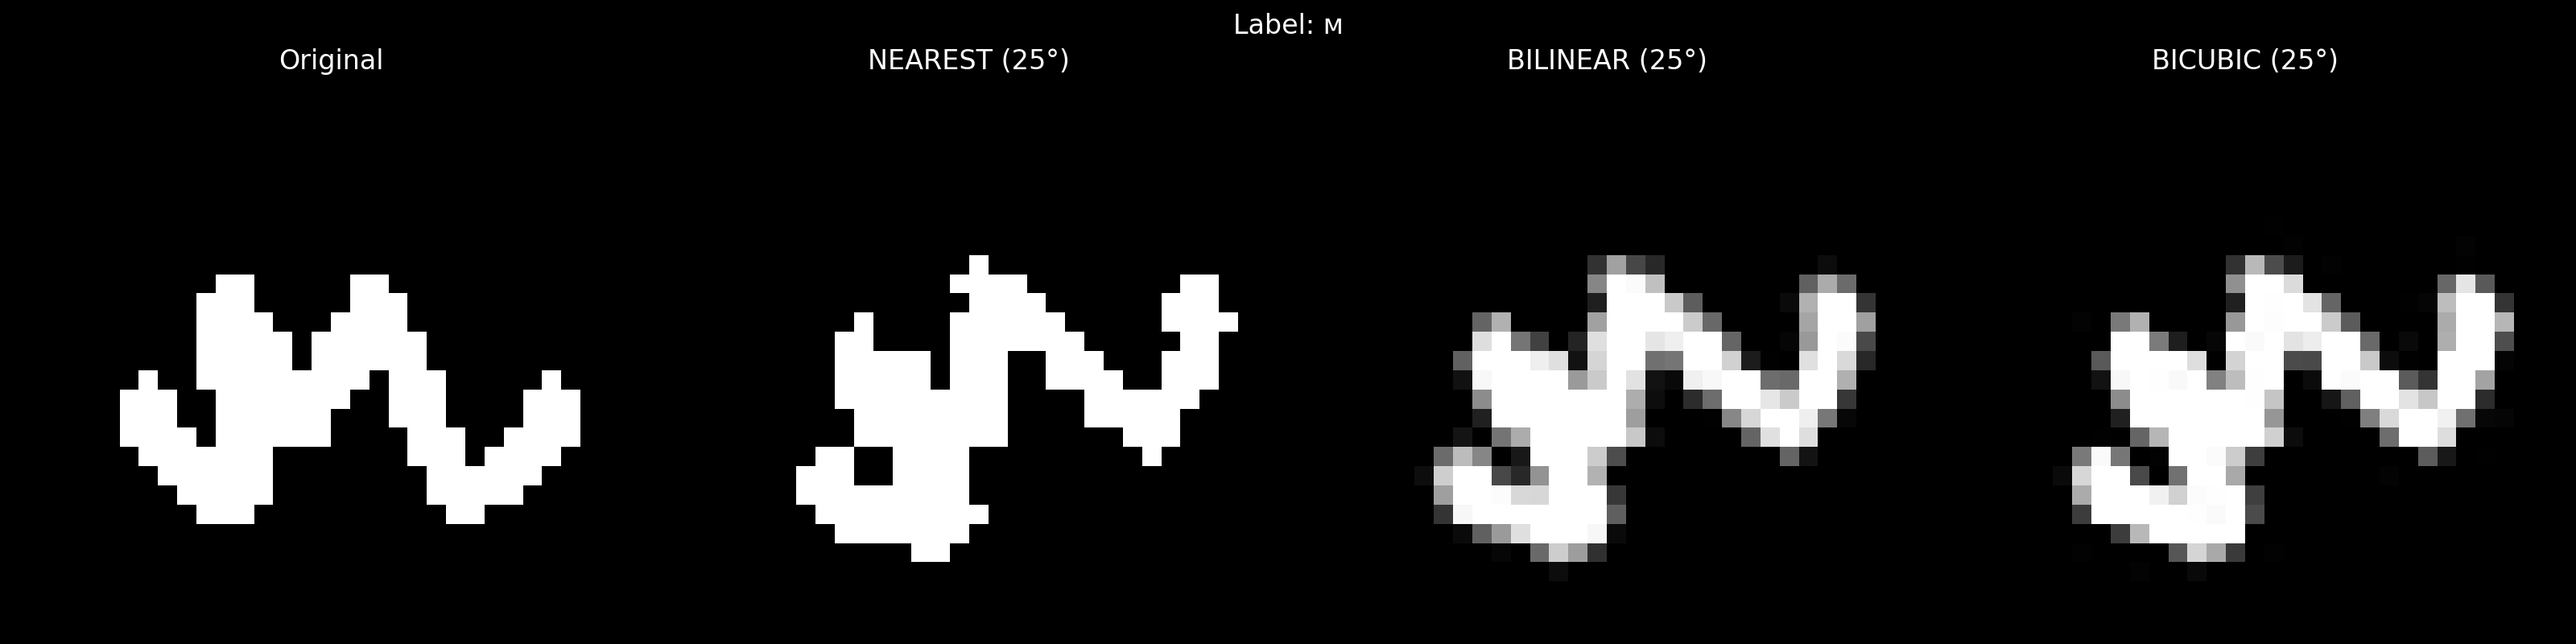

In [32]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['м'])
plot_rotated_with_interpolations(img, label, angle=25)

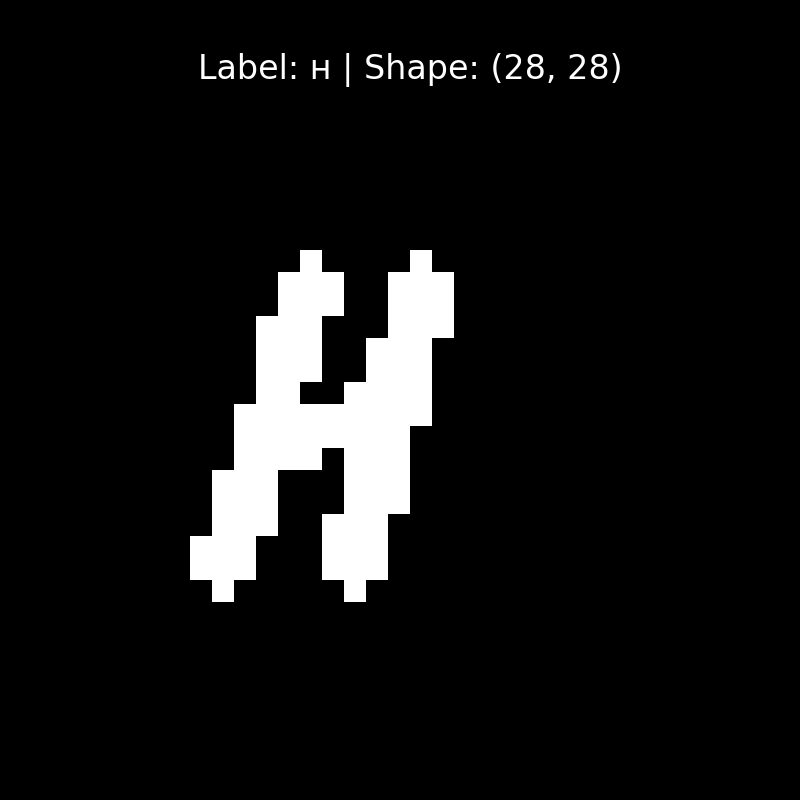

In [33]:
# Генерация изображений
img = generator.generate_н()
label = 'н'
plot_single_image(img, label)

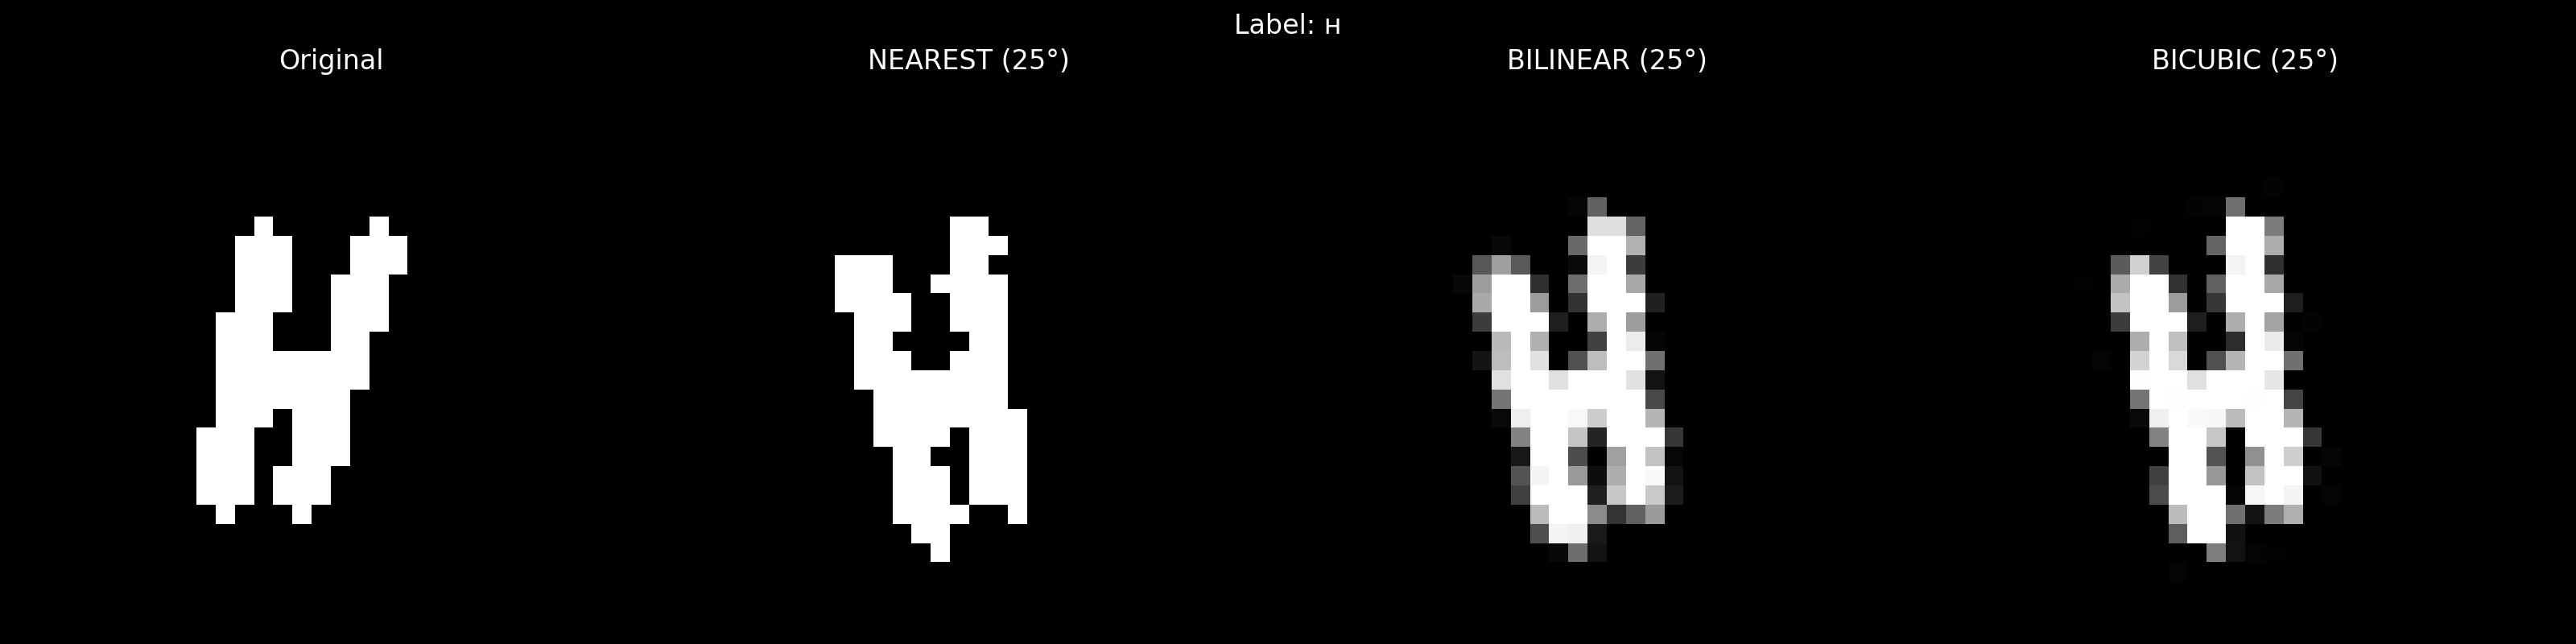

In [34]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['н'])
plot_rotated_with_interpolations(img, label, angle=25)

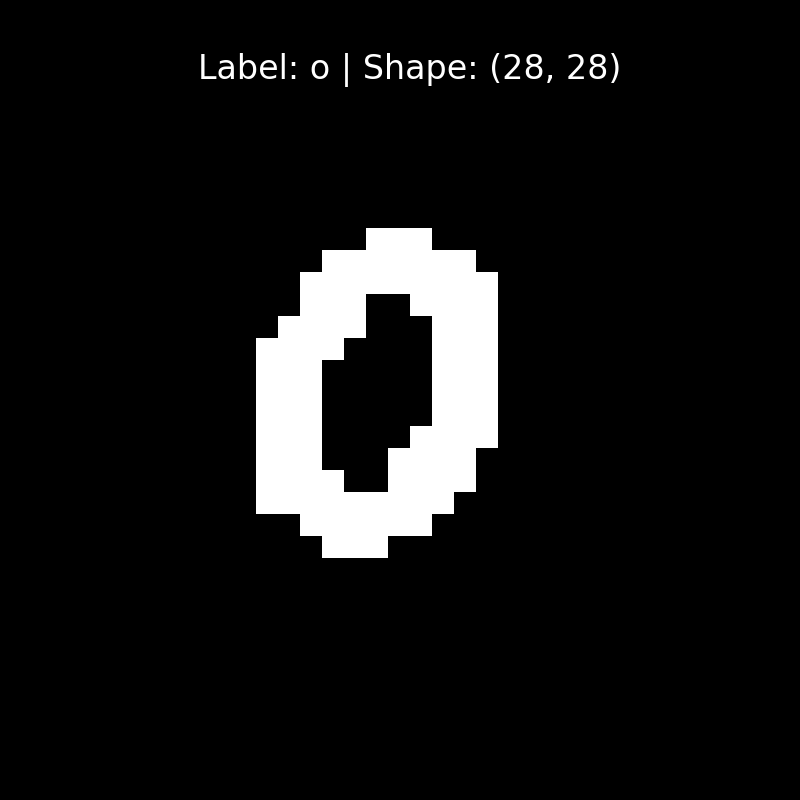

In [35]:
# Генерация изображений
img = generator.generate_о()
label = 'о'
plot_single_image(img, label)

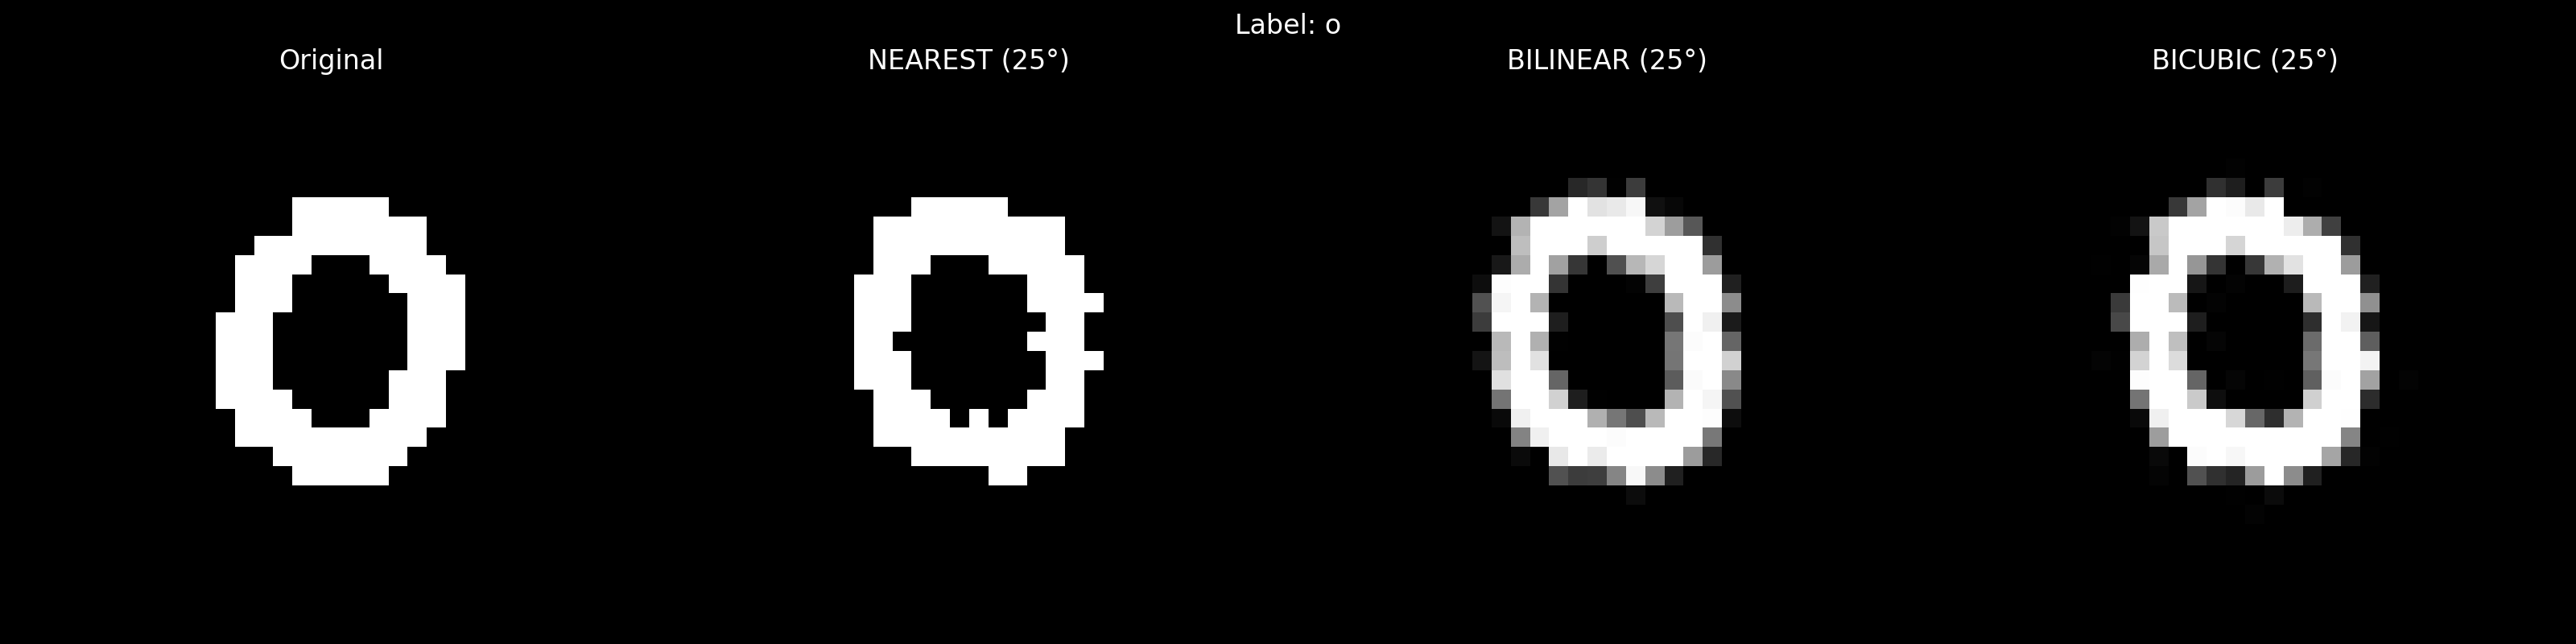

In [36]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['о'])
plot_rotated_with_interpolations(img, label, angle=25)

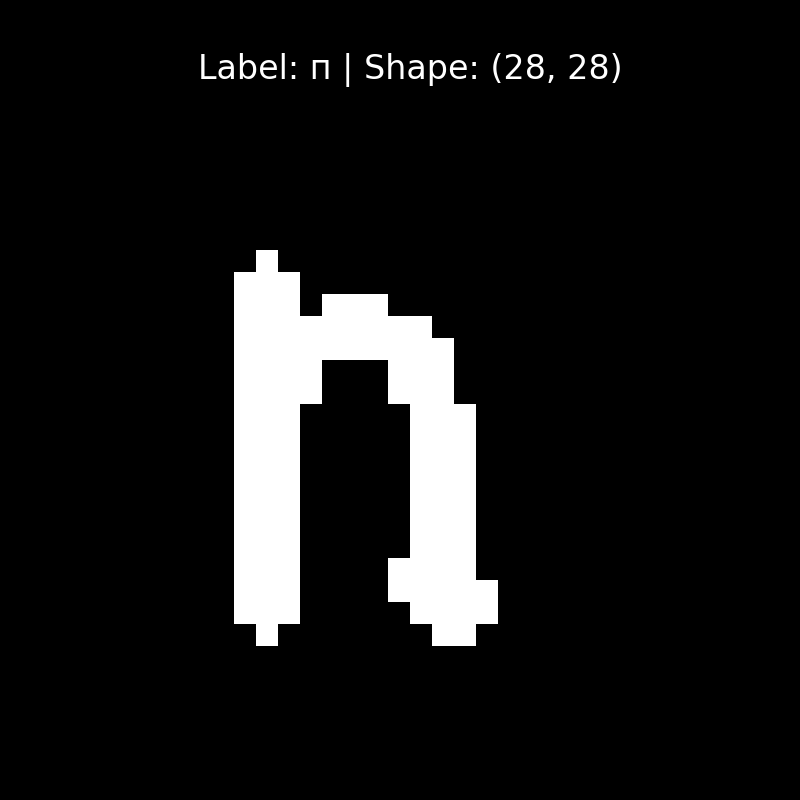

In [37]:
# Генерация изображений
img = generator.generate_п()
label = 'п'
plot_single_image(img, label)

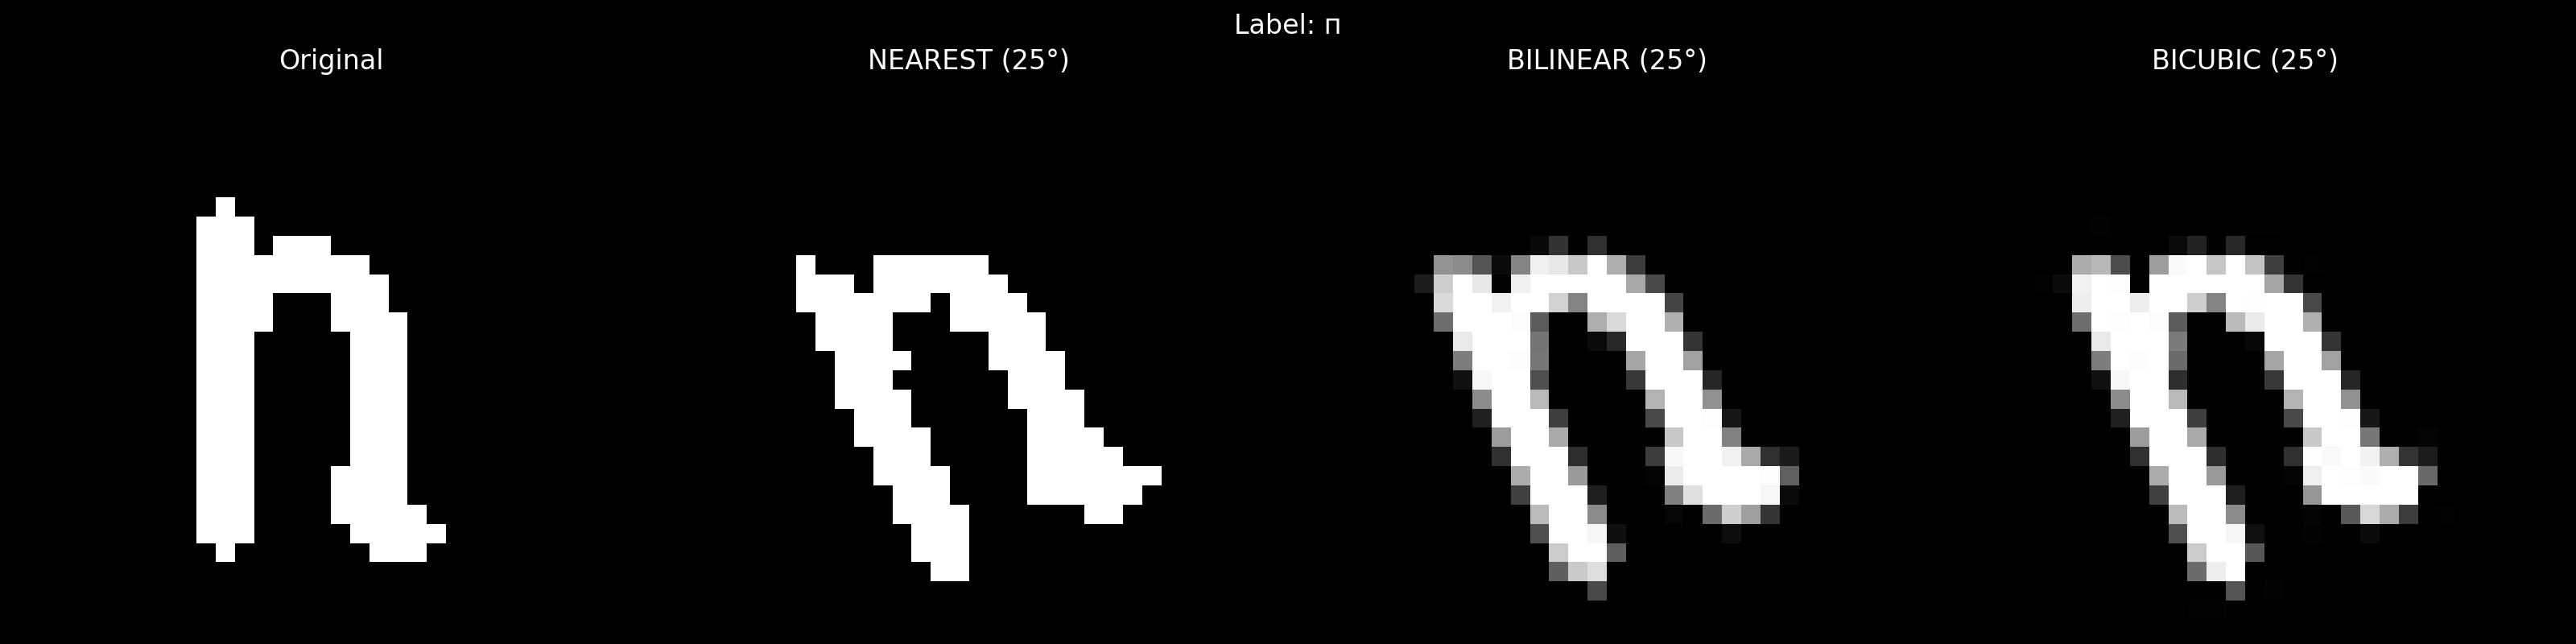

In [38]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['п'])
plot_rotated_with_interpolations(img, label, angle=25)

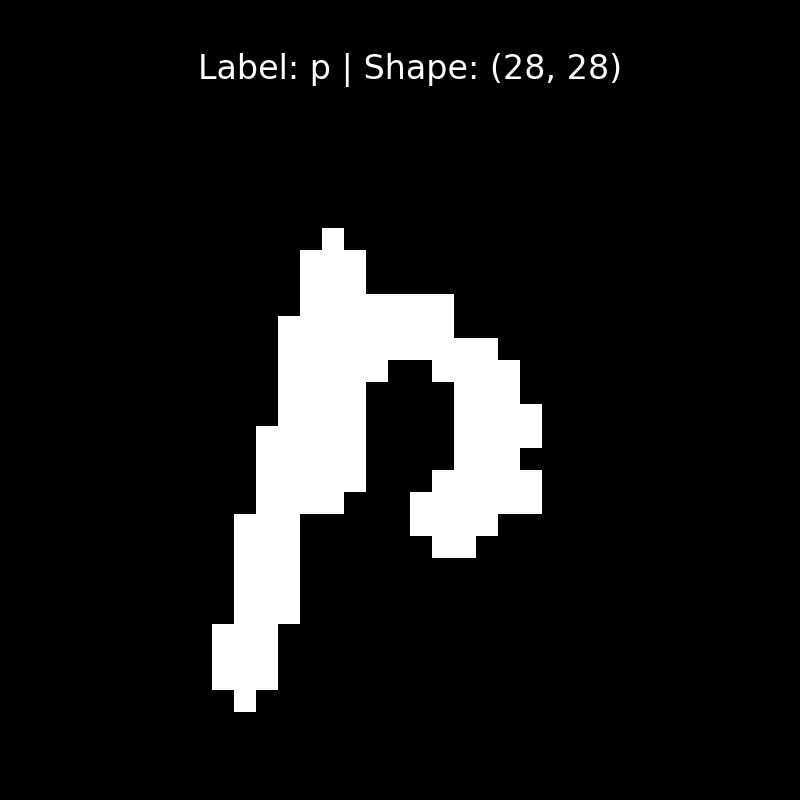

In [39]:
# Генерация изображений
img = generator.generate_р()
label = 'р'
plot_single_image(img, label)

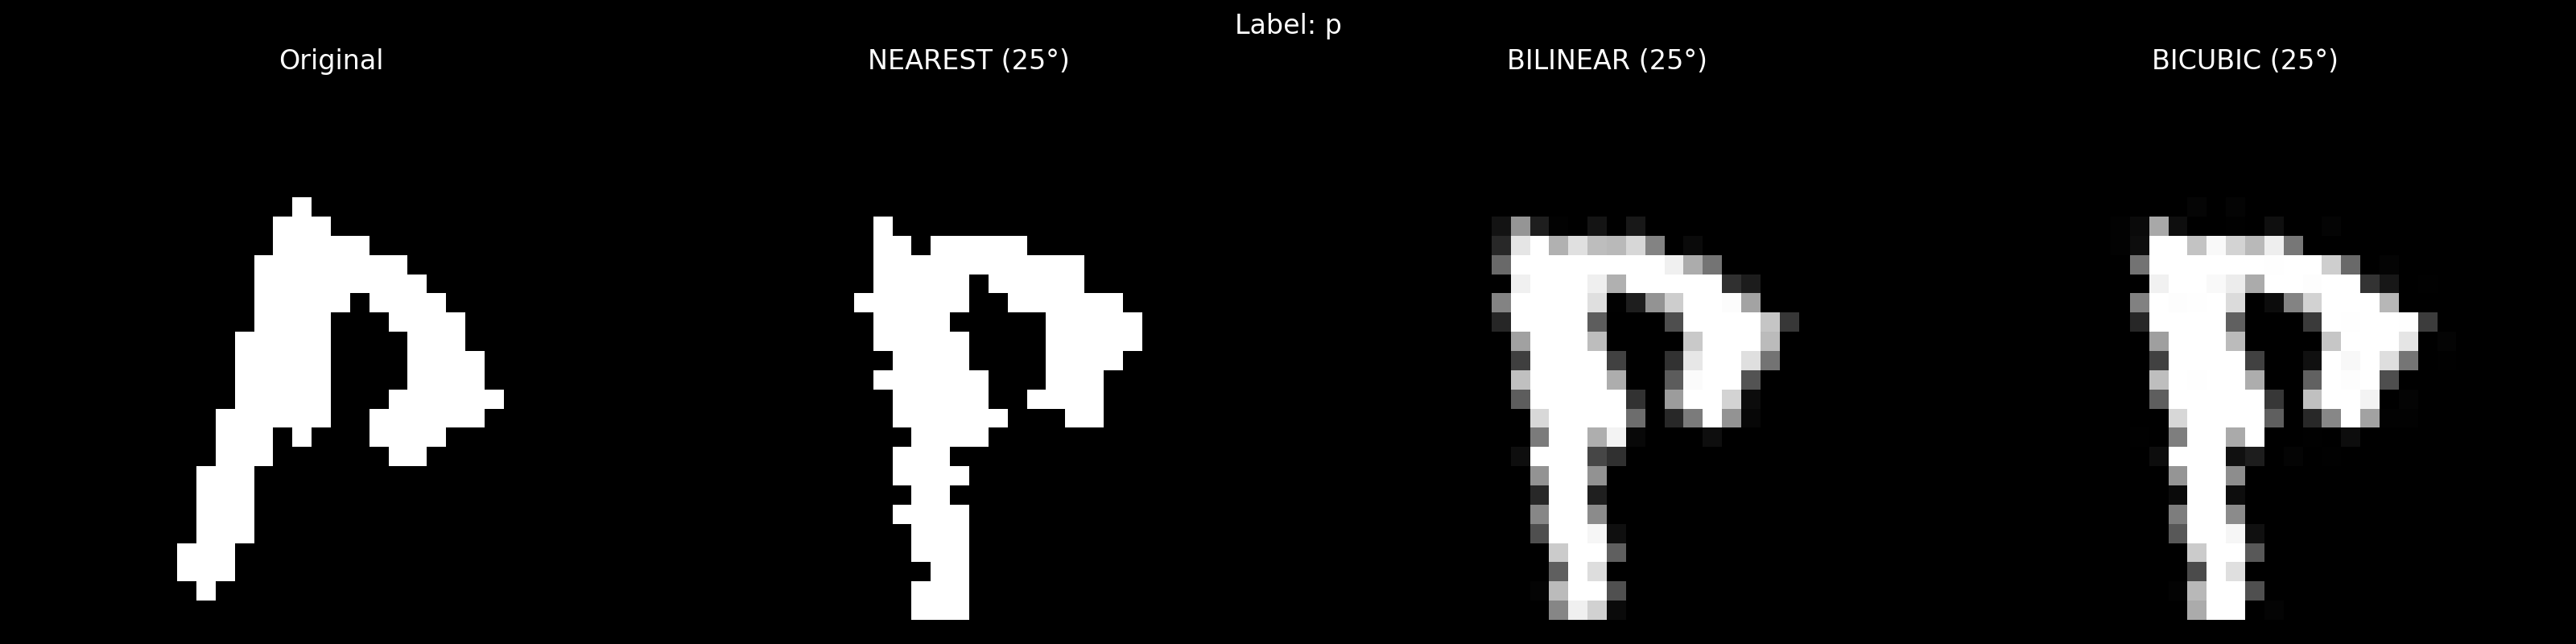

In [40]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['р'])
plot_rotated_with_interpolations(img, label, angle=25)

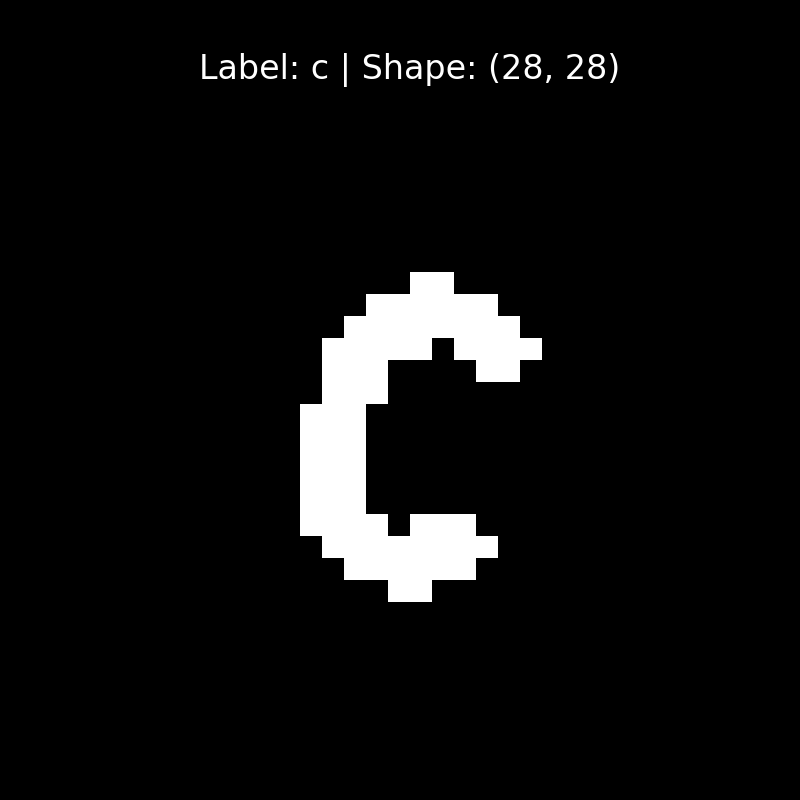

In [41]:
# Генерация изображений
img = generator.generate_с()
label = 'с'
plot_single_image(img, label)

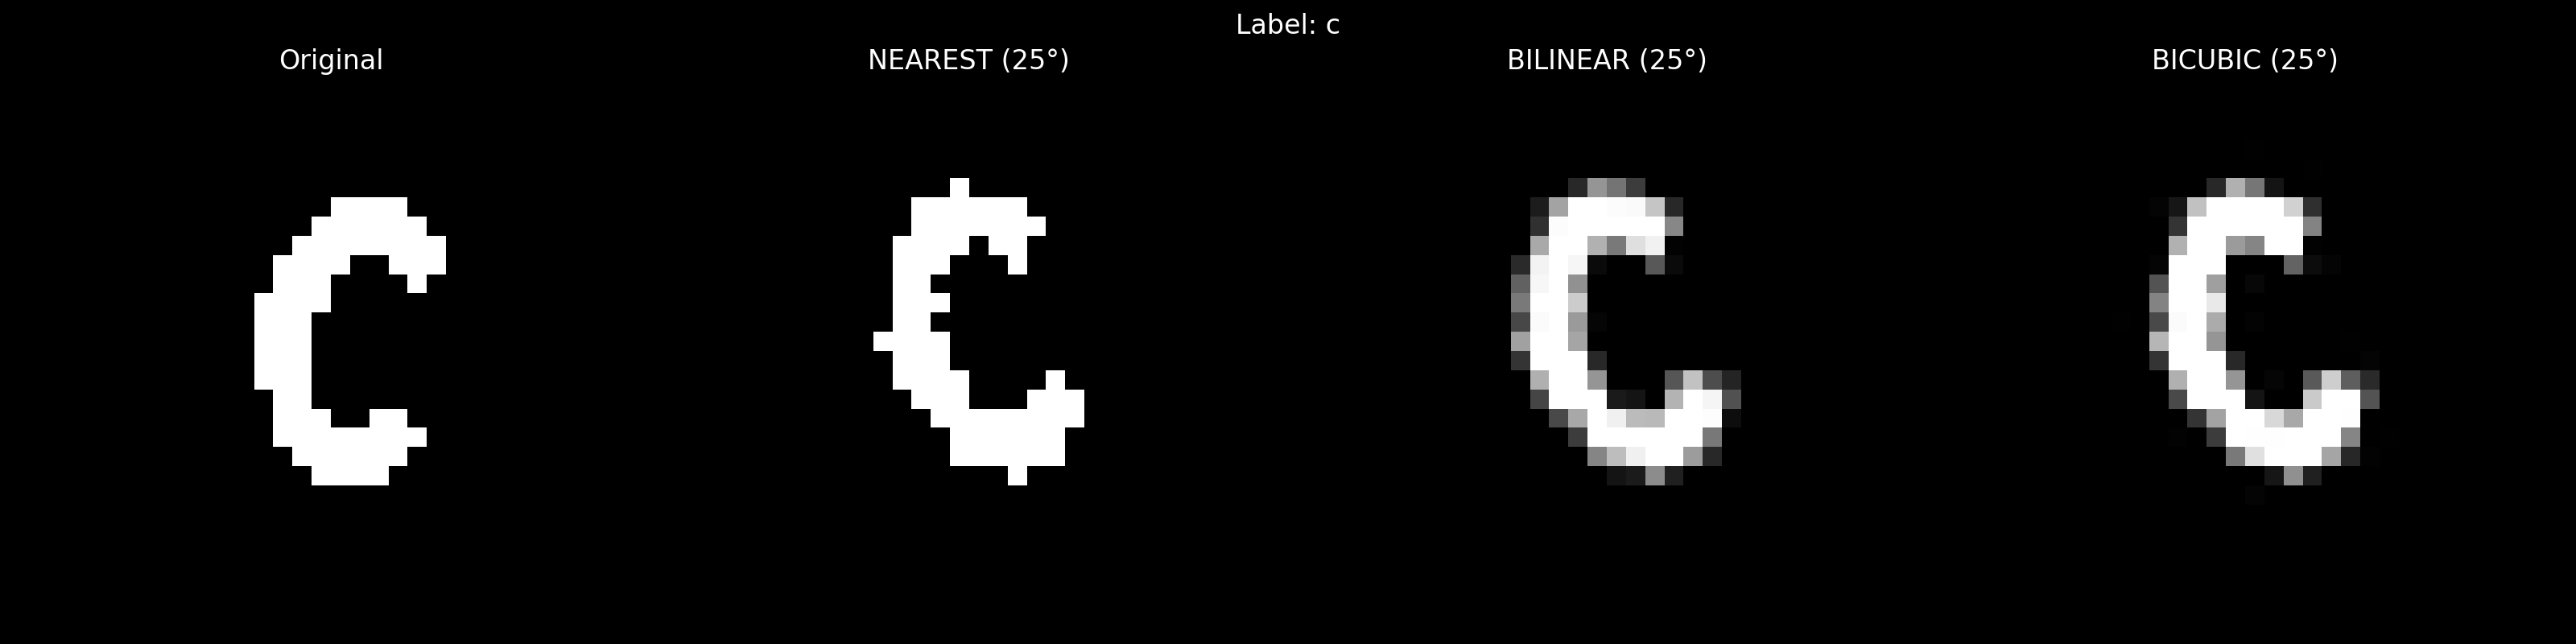

In [42]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['с'])
plot_rotated_with_interpolations(img, label, angle=25)

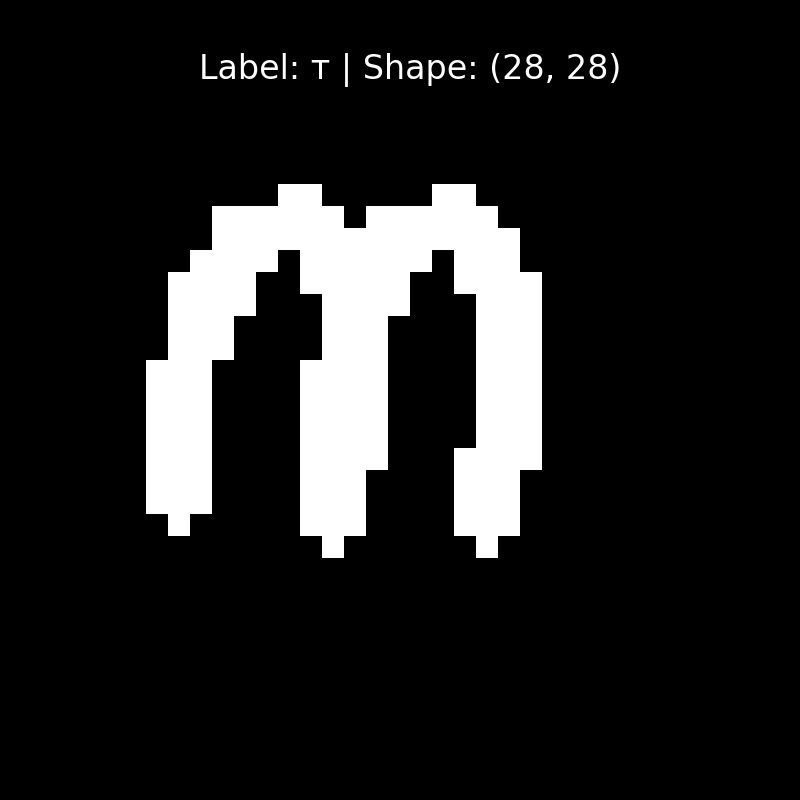

In [43]:
# Генерация изображений
img = generator.generate_т()
label = 'т'
plot_single_image(img, label)

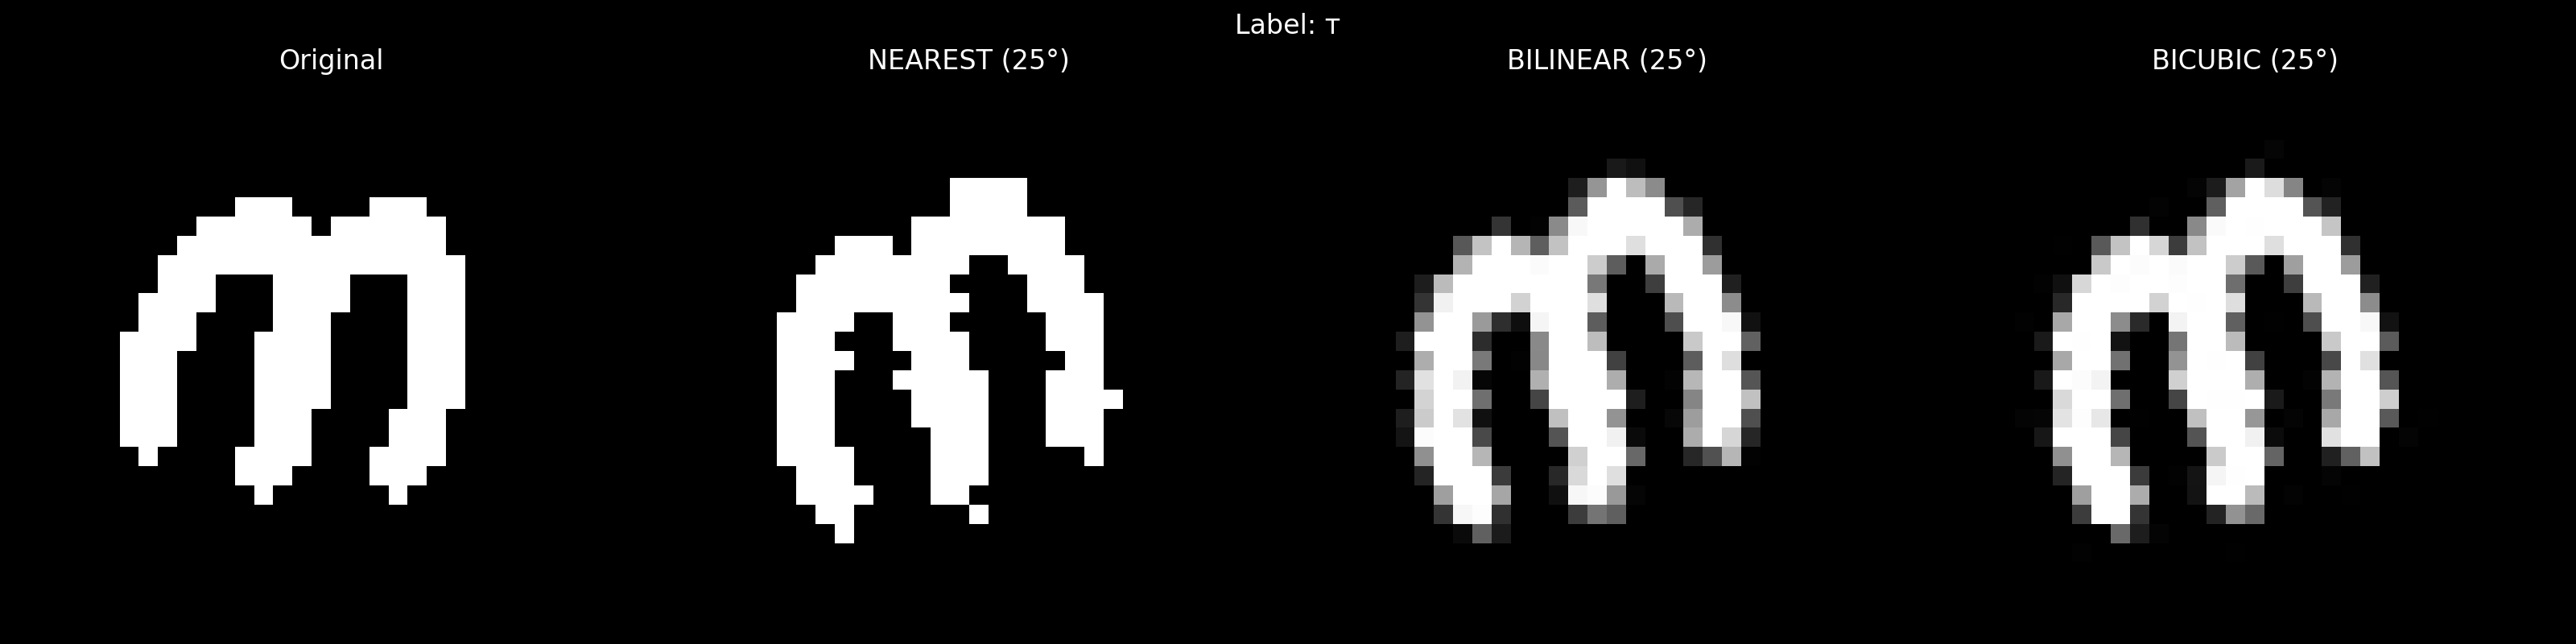

In [44]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['т'])
plot_rotated_with_interpolations(img, label, angle=25)

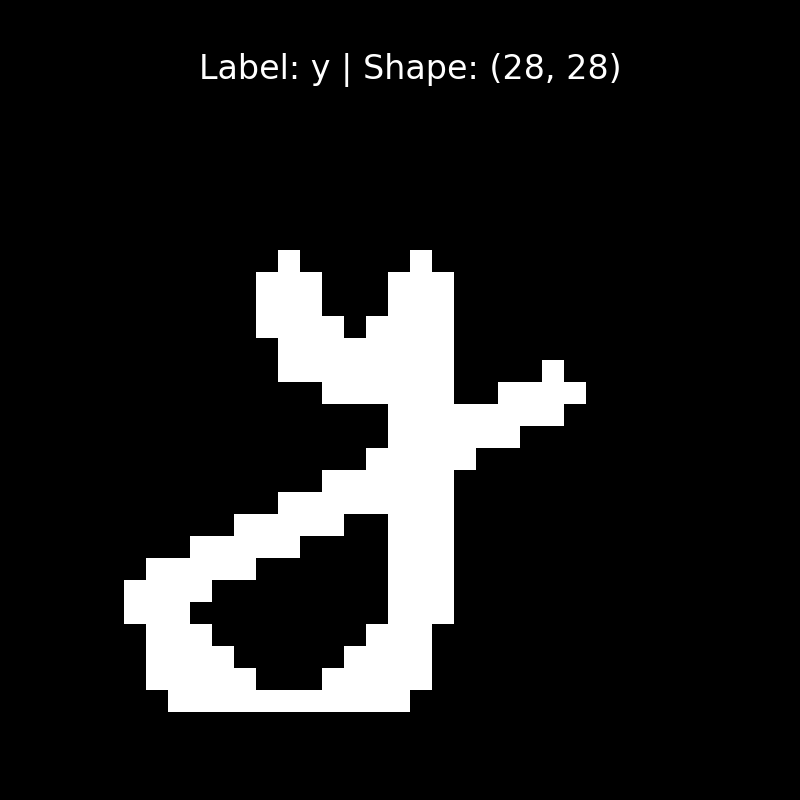

In [45]:
# Генерация изображений
img = generator.generate_у()
label = 'у'
plot_single_image(img, label)

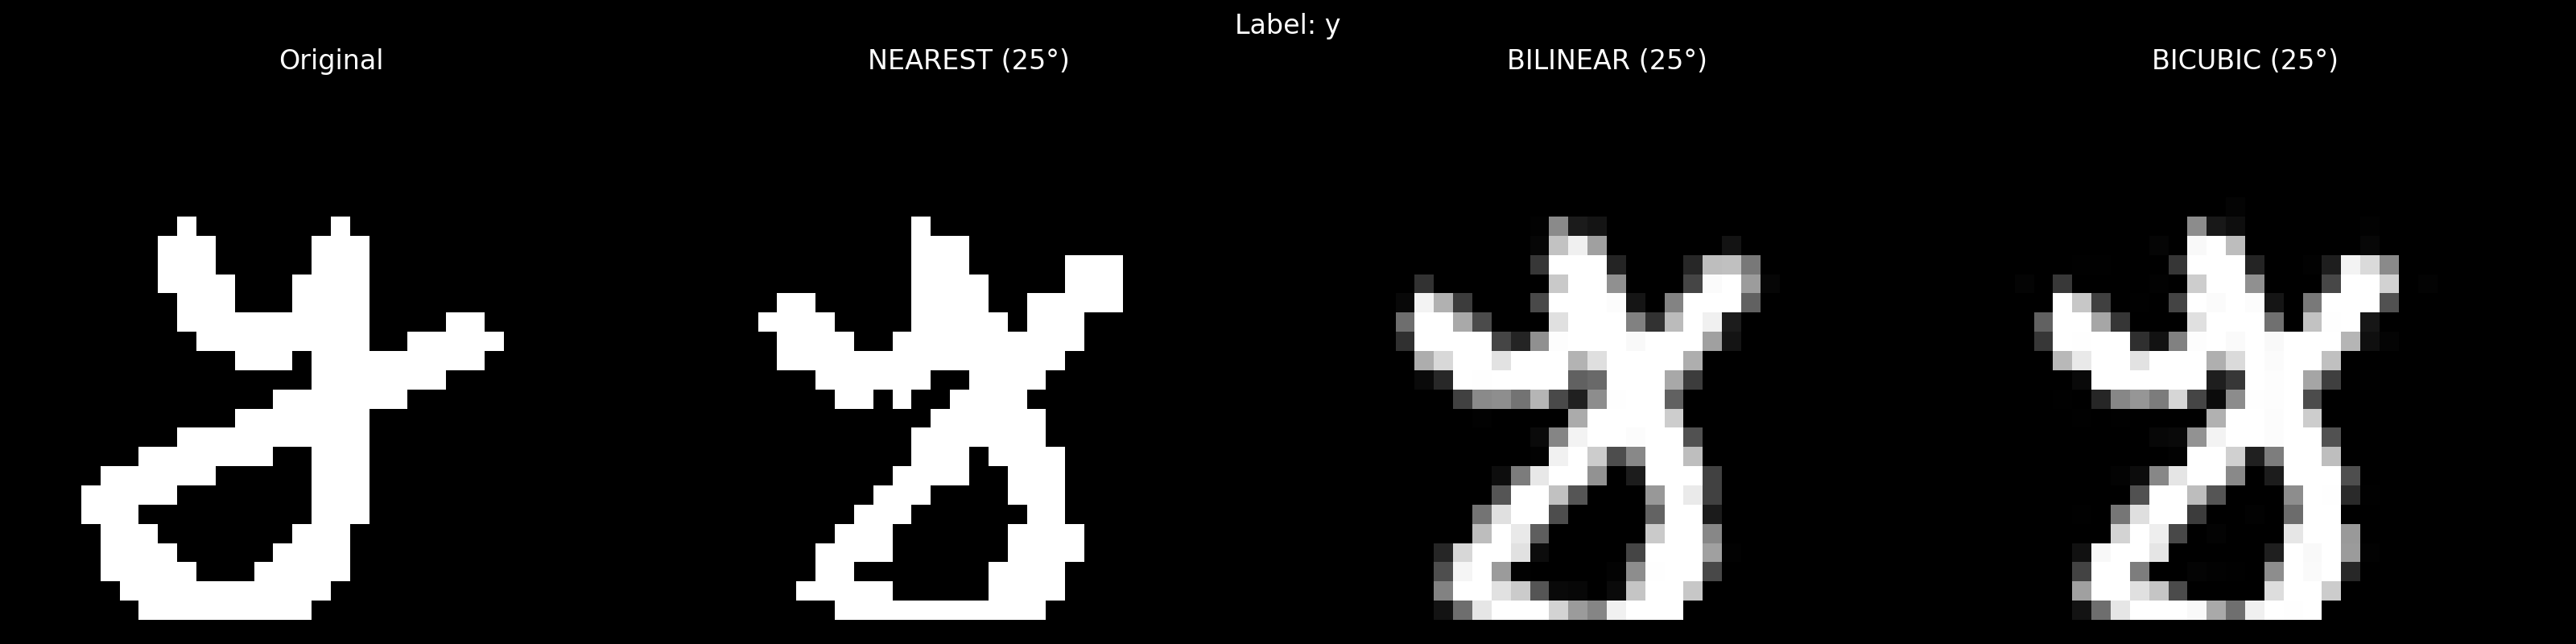

In [46]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['у'])
plot_rotated_with_interpolations(img, label, angle=25)

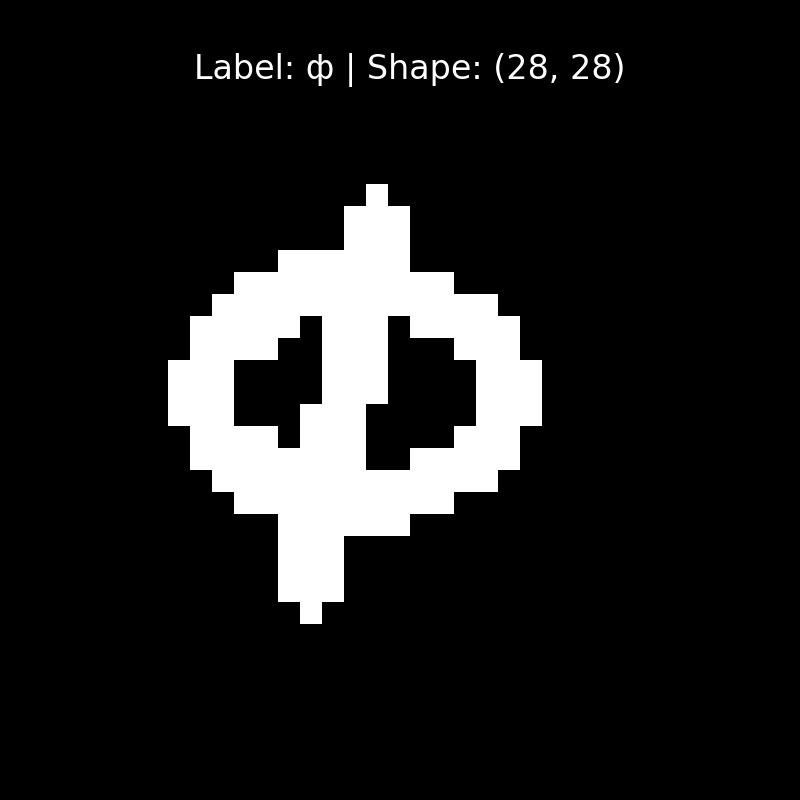

In [47]:
# Генерация изображений
img = generator.generate_ф()
label = 'ф'
plot_single_image(img, label)

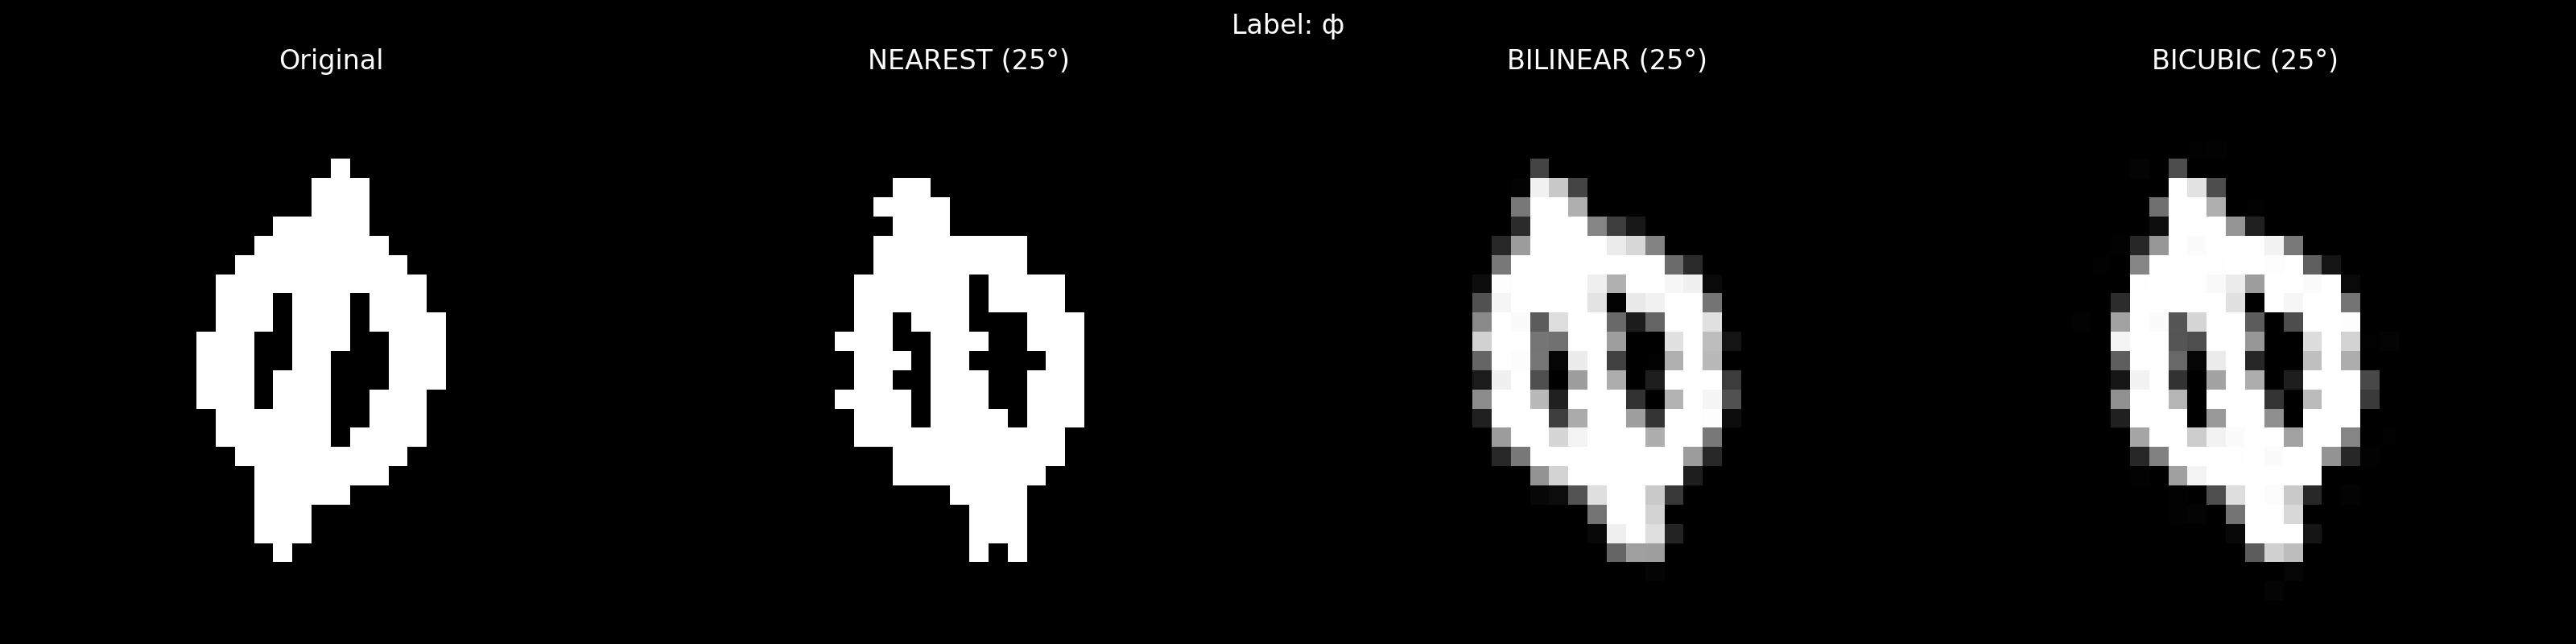

In [48]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ф'])
plot_rotated_with_interpolations(img, label, angle=25)

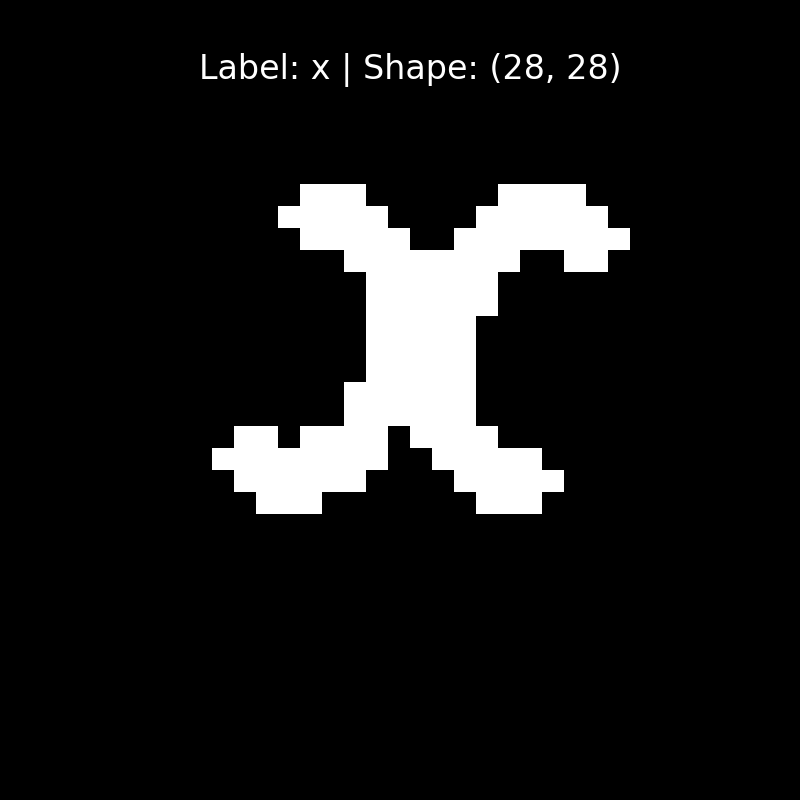

In [49]:
# Генерация изображений
img = generator.generate_х()
label = 'х'
plot_single_image(img, label)

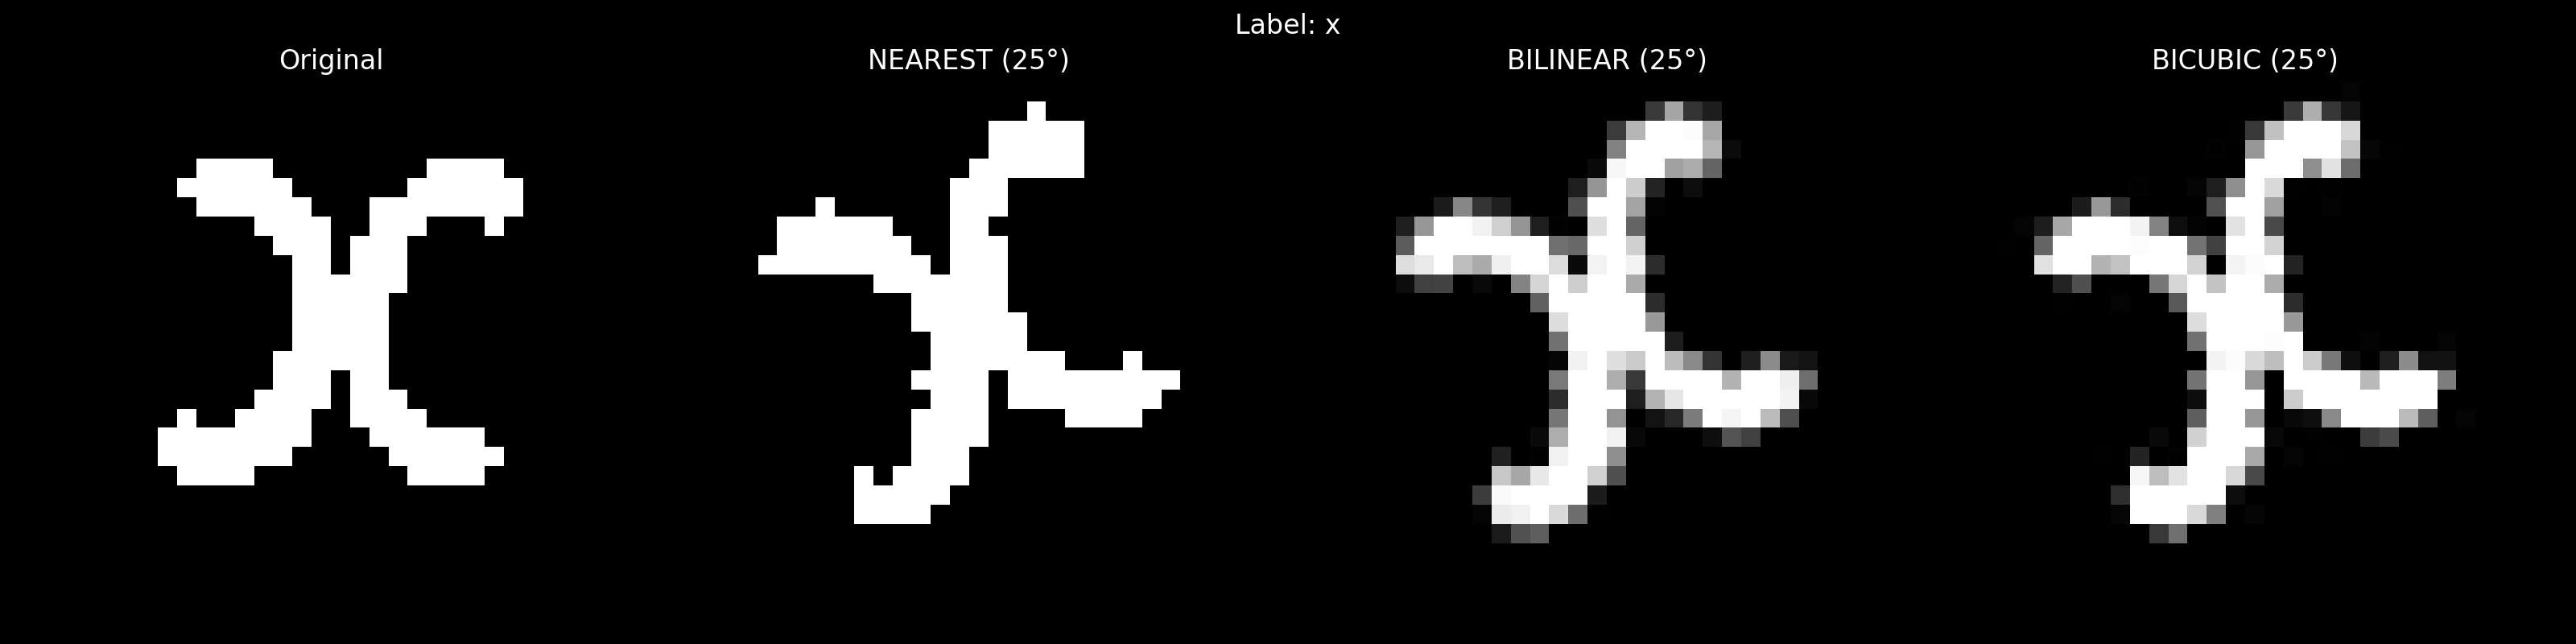

In [50]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['х'])
plot_rotated_with_interpolations(img, label, angle=25)

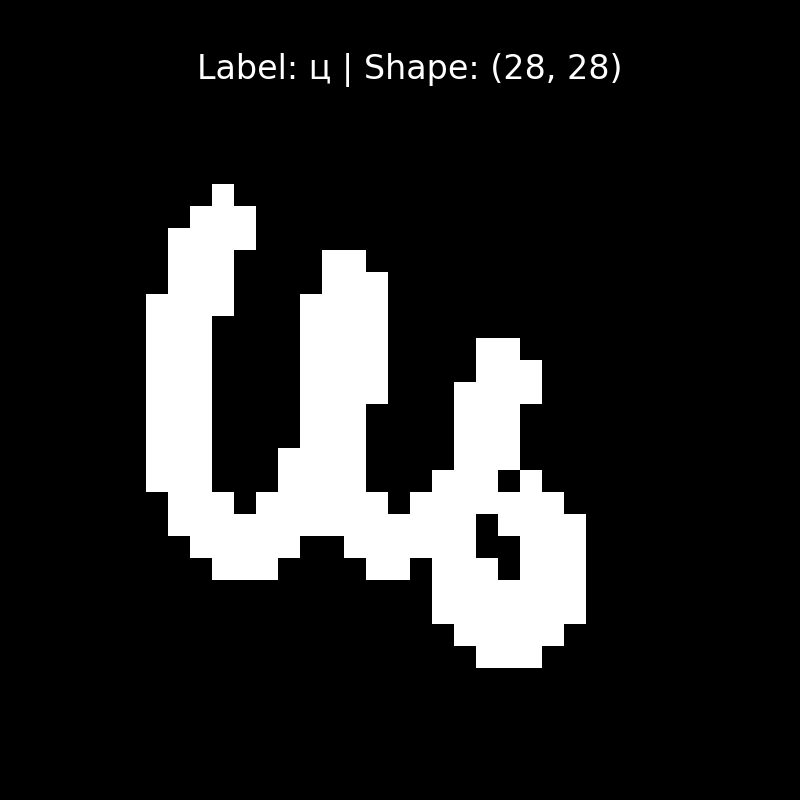

In [51]:
# Генерация изображений
img = generator.generate_ц()
label = 'ц'
plot_single_image(img, label)

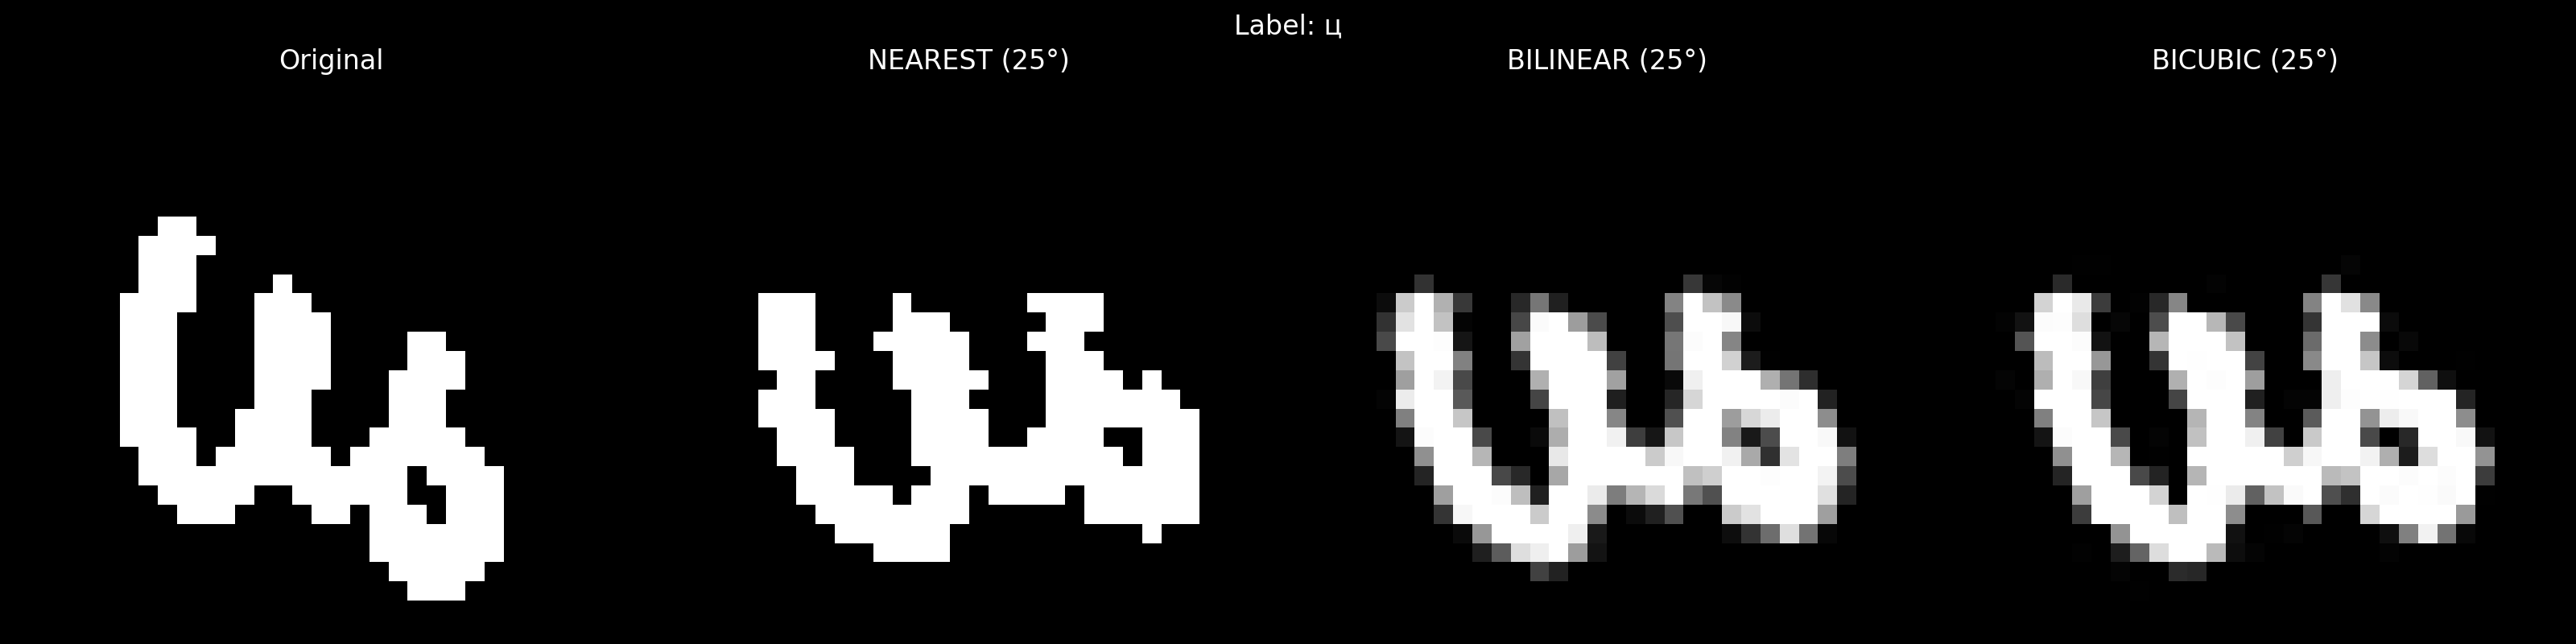

In [52]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ц'])
plot_rotated_with_interpolations(img, label, angle=25)

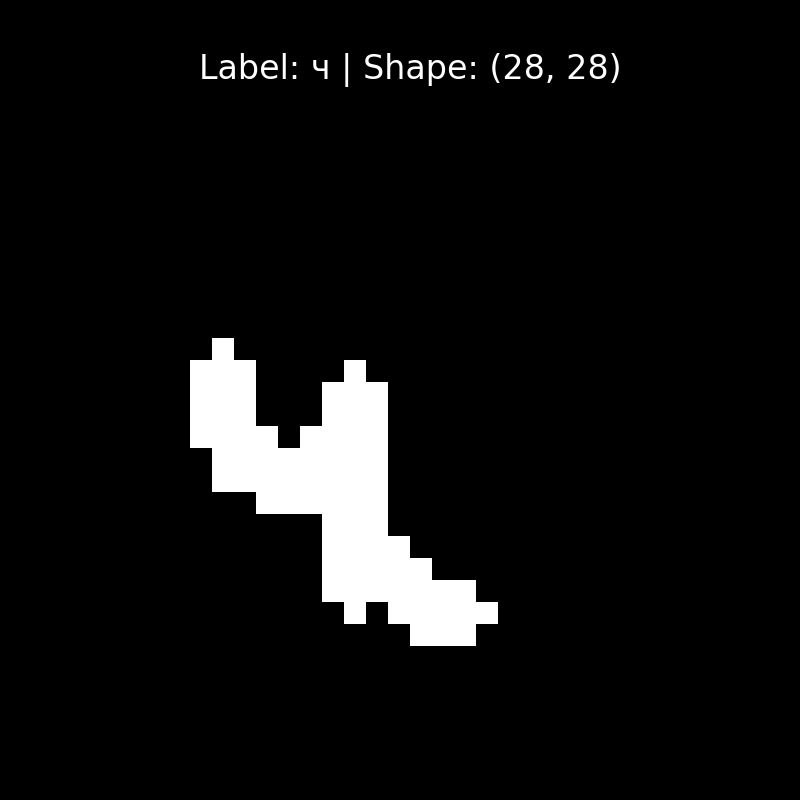

In [53]:
# Генерация изображений
img = generator.generate_ч()
label = 'ч'
plot_single_image(img, label)

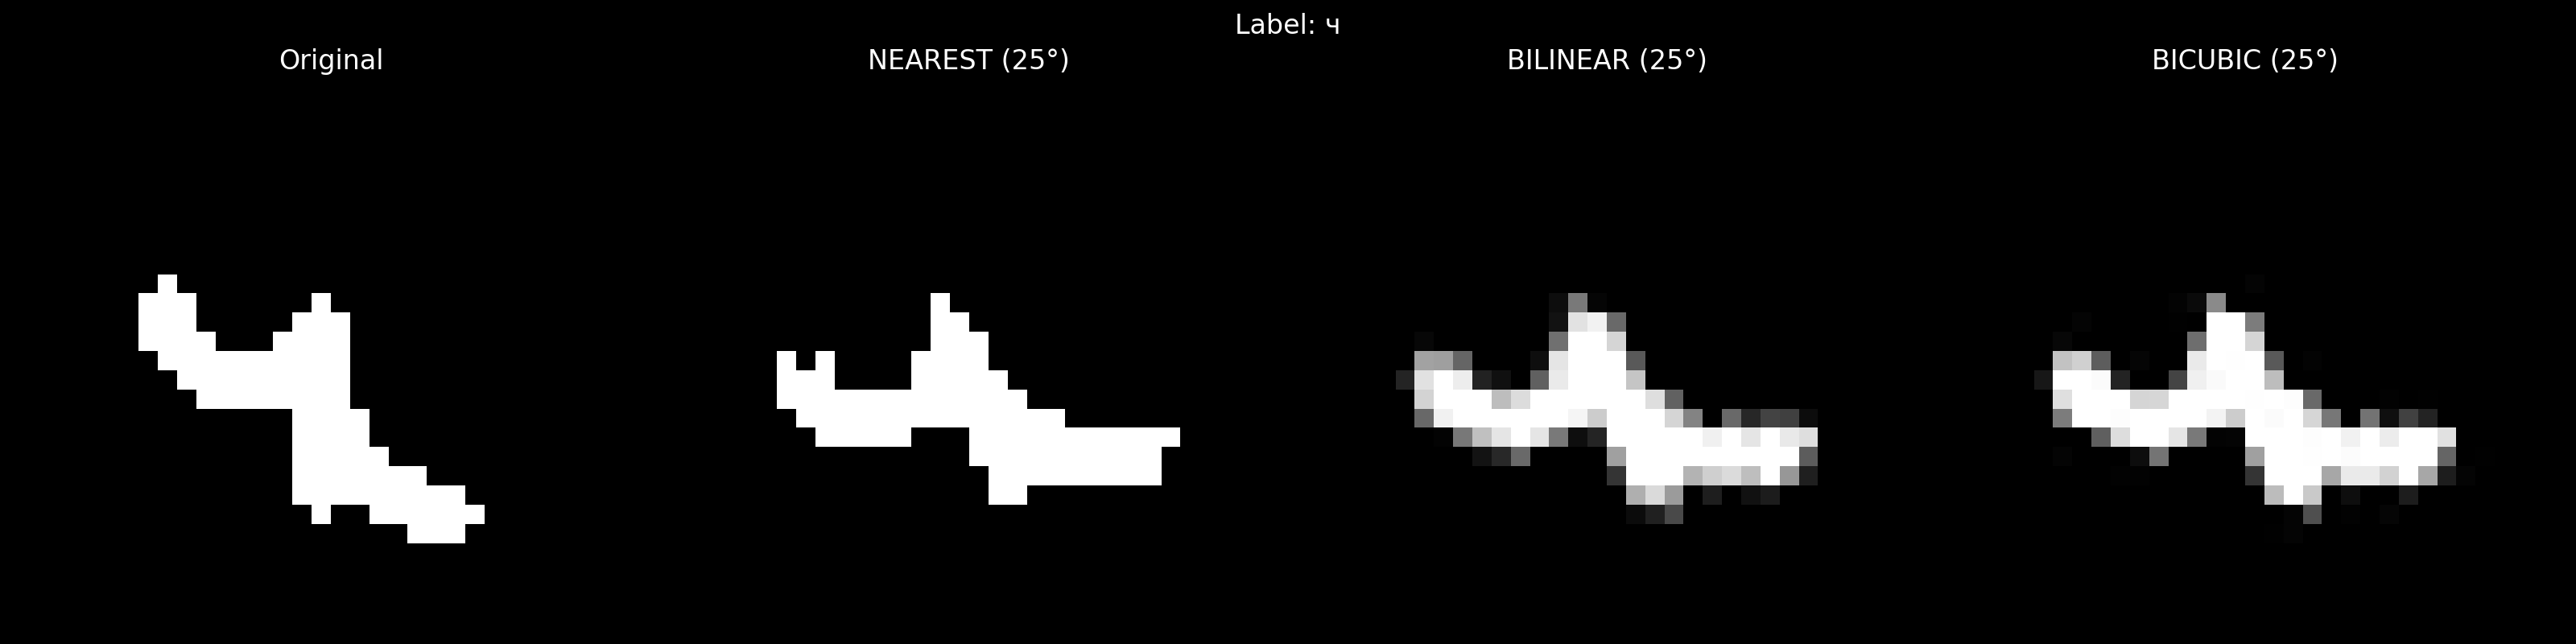

In [54]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ч'])
plot_rotated_with_interpolations(img, label, angle=25)

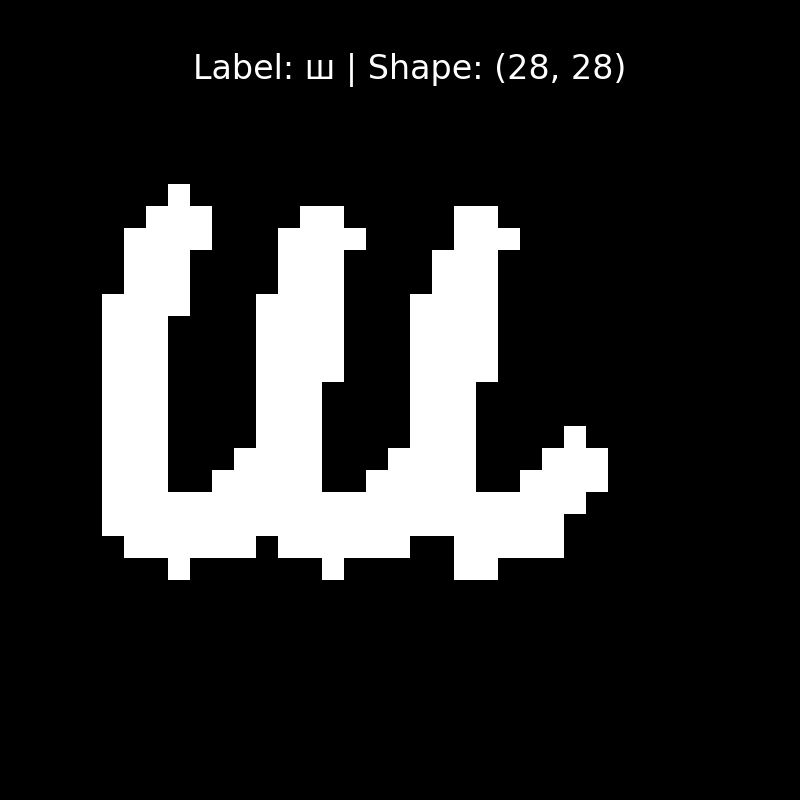

In [55]:
# Генерация изображений
img = generator.generate_ш()
label = 'ш'
plot_single_image(img, label)

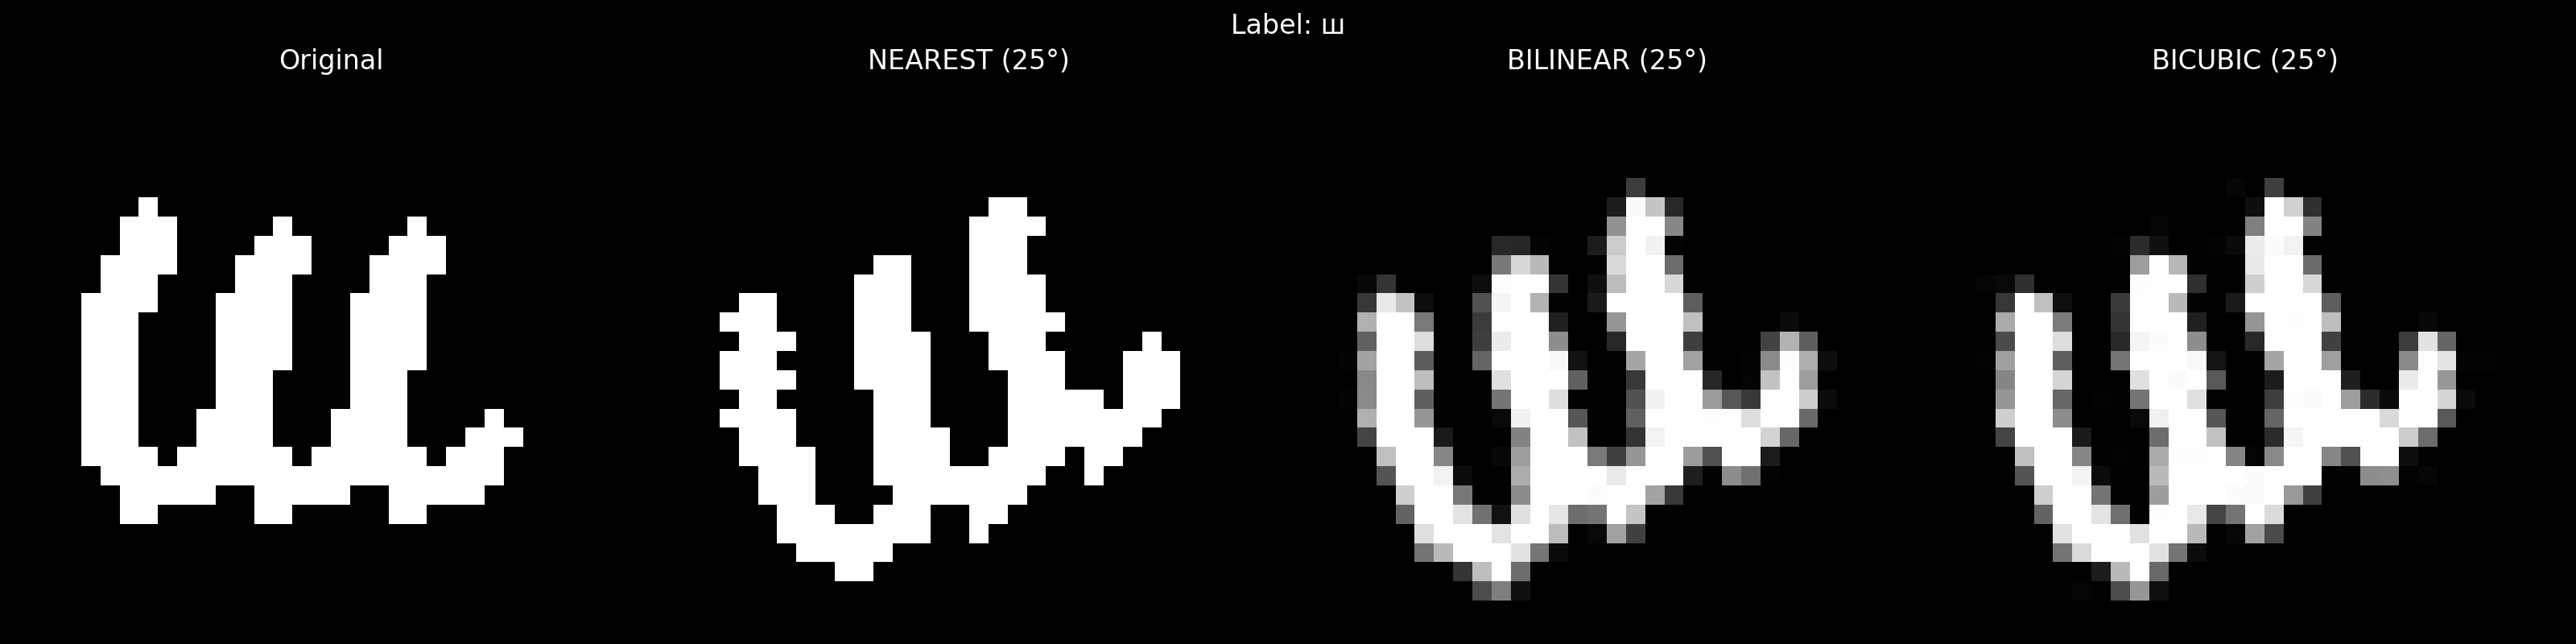

In [56]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ш'])
plot_rotated_with_interpolations(img, label, angle=25)

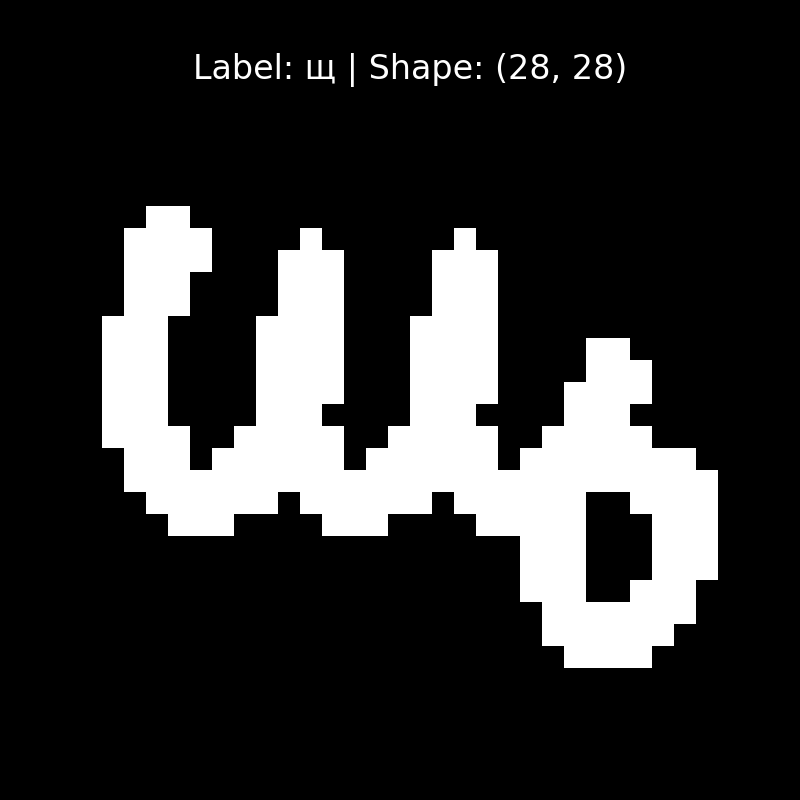

In [57]:
# Генерация изображений
img = generator.generate_щ()
label = 'щ'
plot_single_image(img, label)

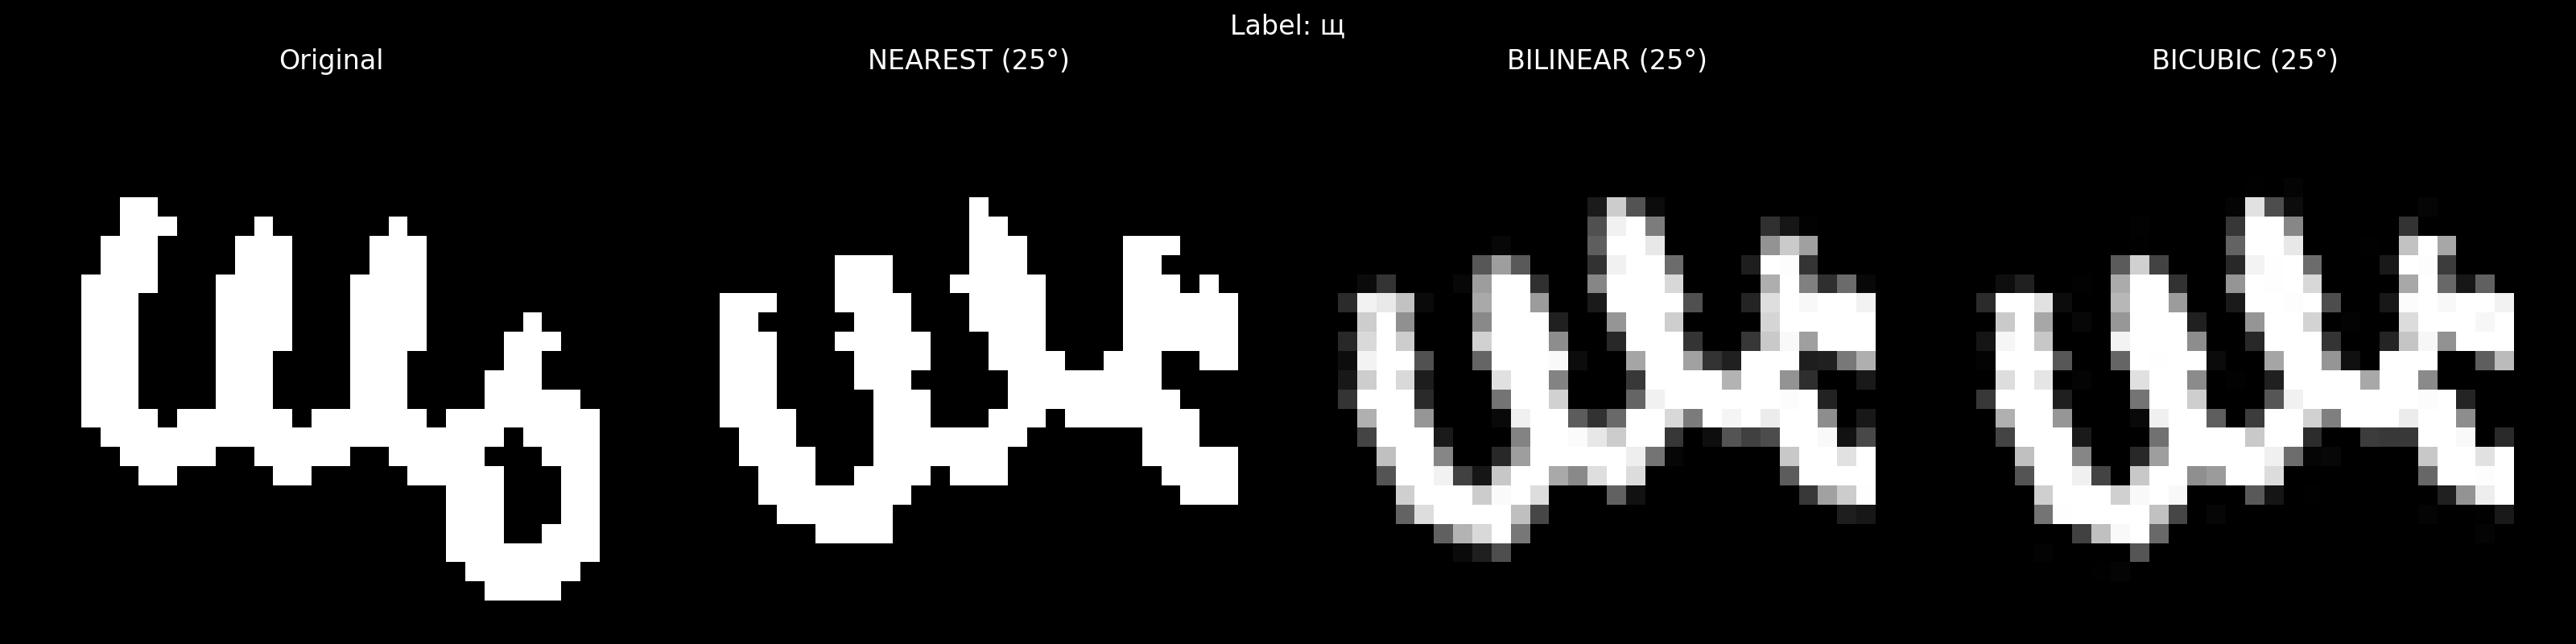

In [58]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['щ'])
plot_rotated_with_interpolations(img, label, angle=25)

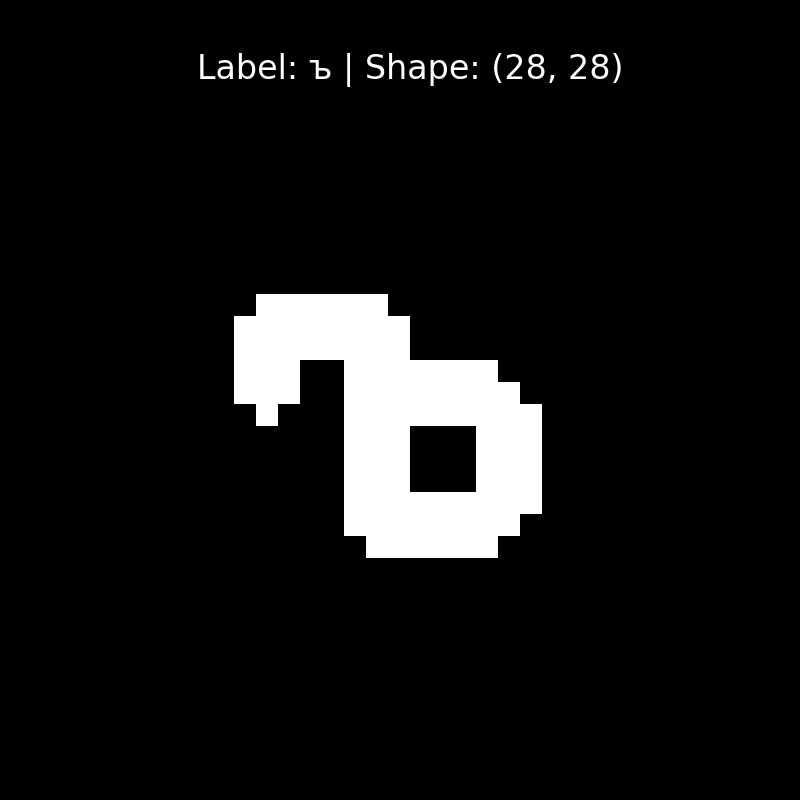

In [59]:
# Генерация изображений
img = generator.generate_ъ()
label = 'ъ'
plot_single_image(img, label)

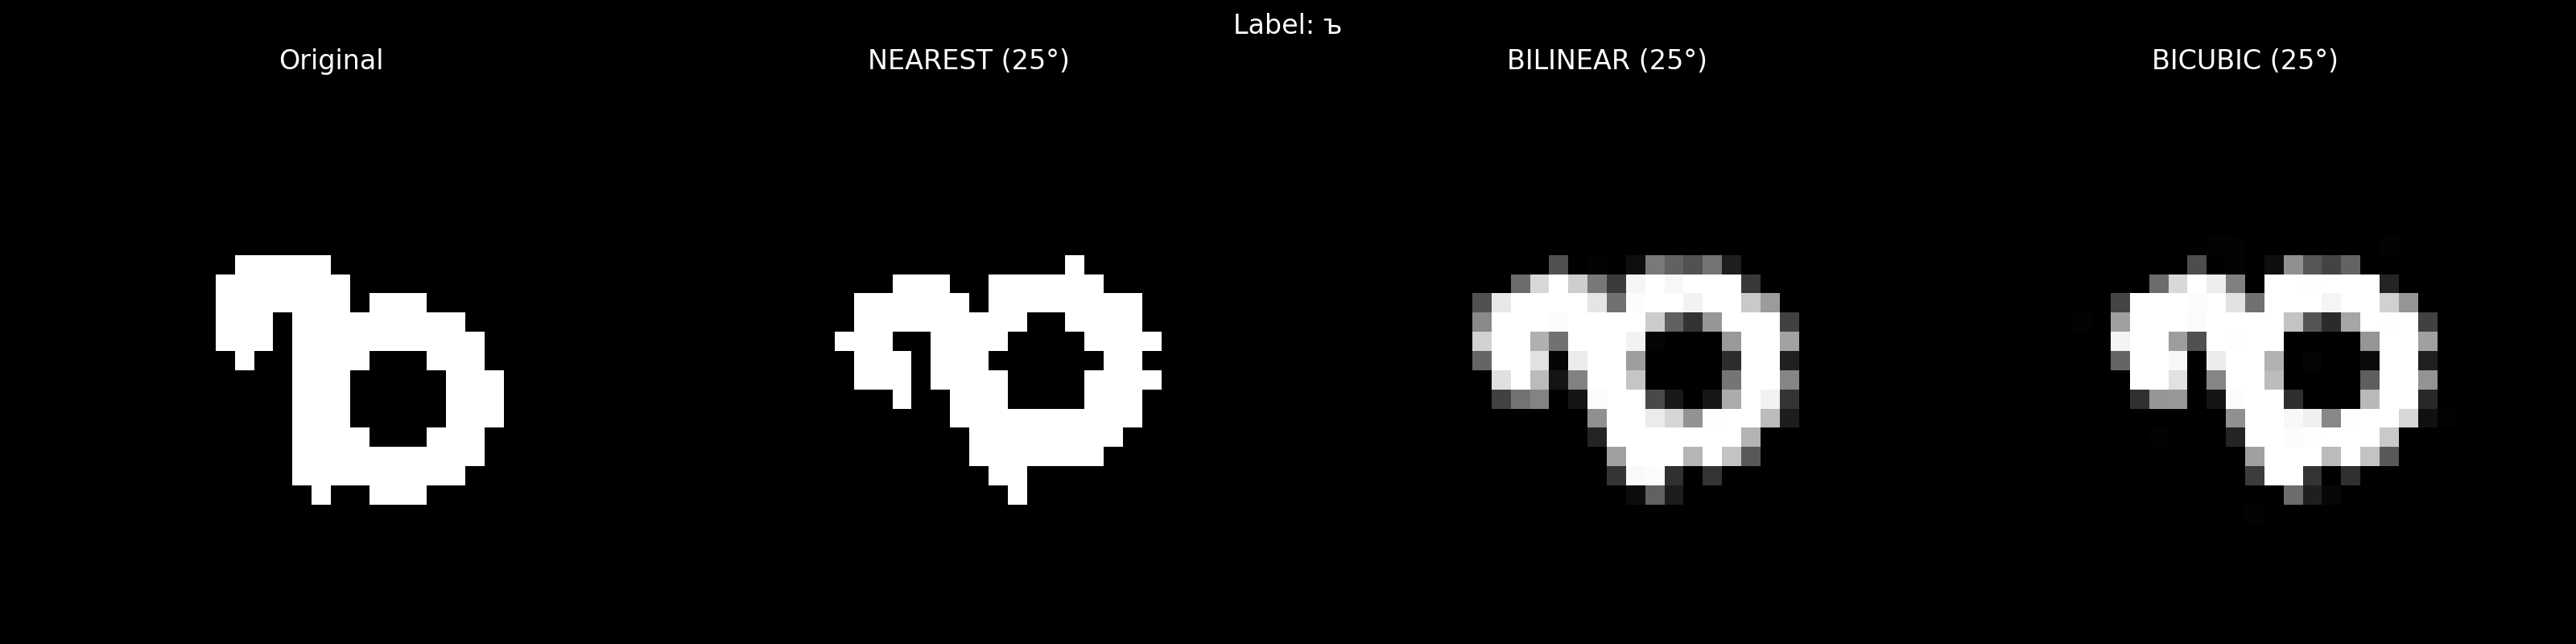

In [60]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ъ'])
plot_rotated_with_interpolations(img, label, angle=25)

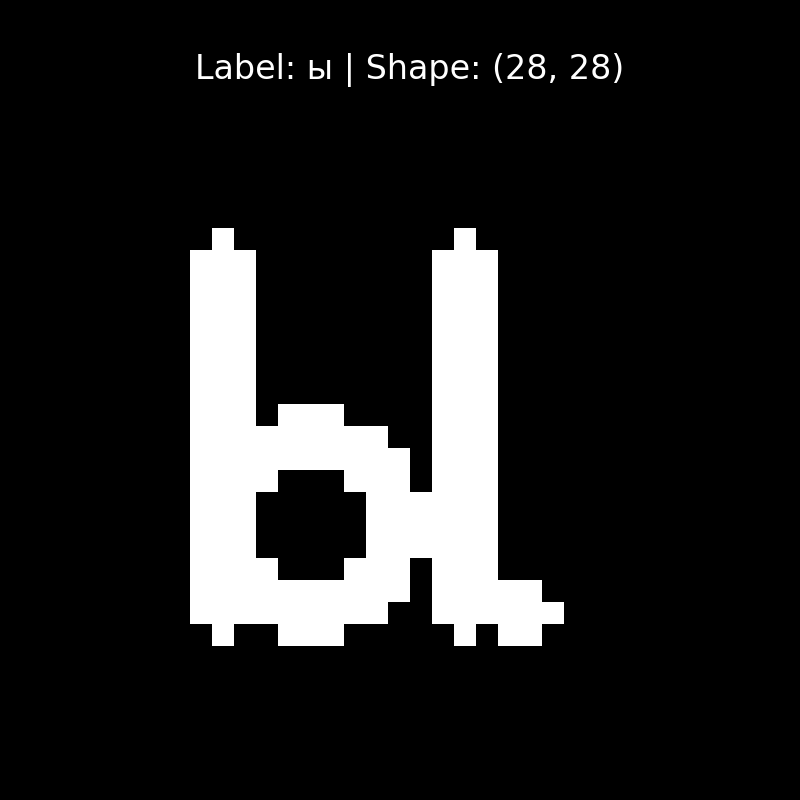

In [61]:
# Генерация изображений
img = generator.generate_ы()
label = 'ы'
plot_single_image(img, label)

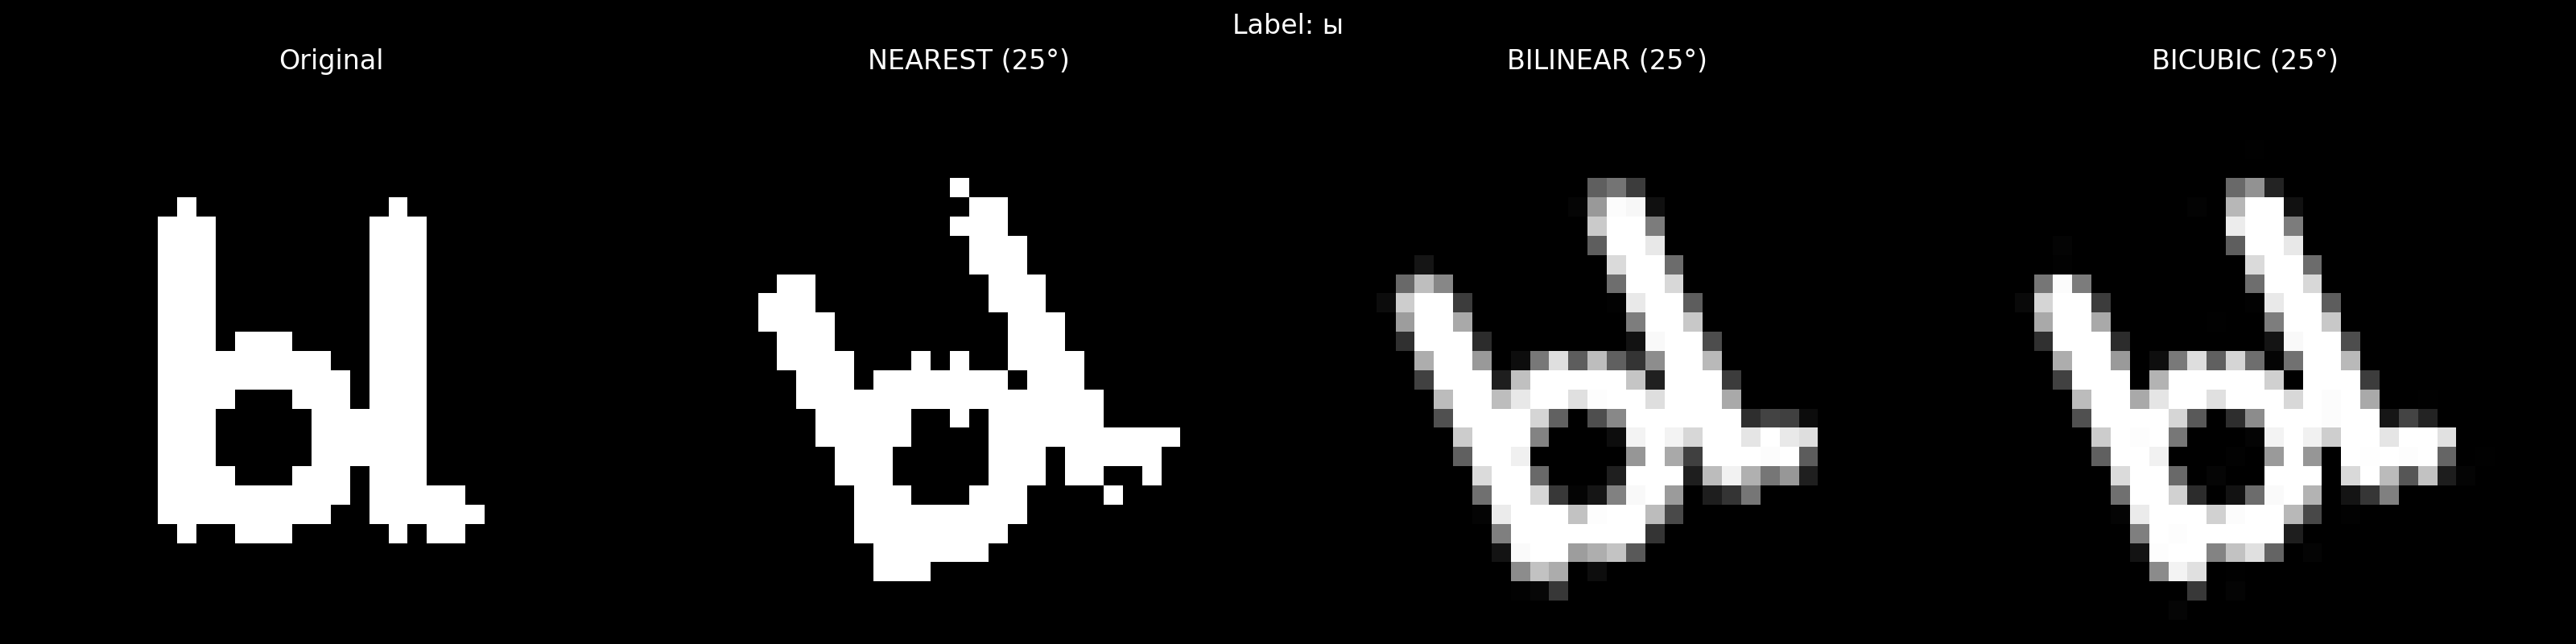

In [62]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ы'])
plot_rotated_with_interpolations(img, label, angle=25)

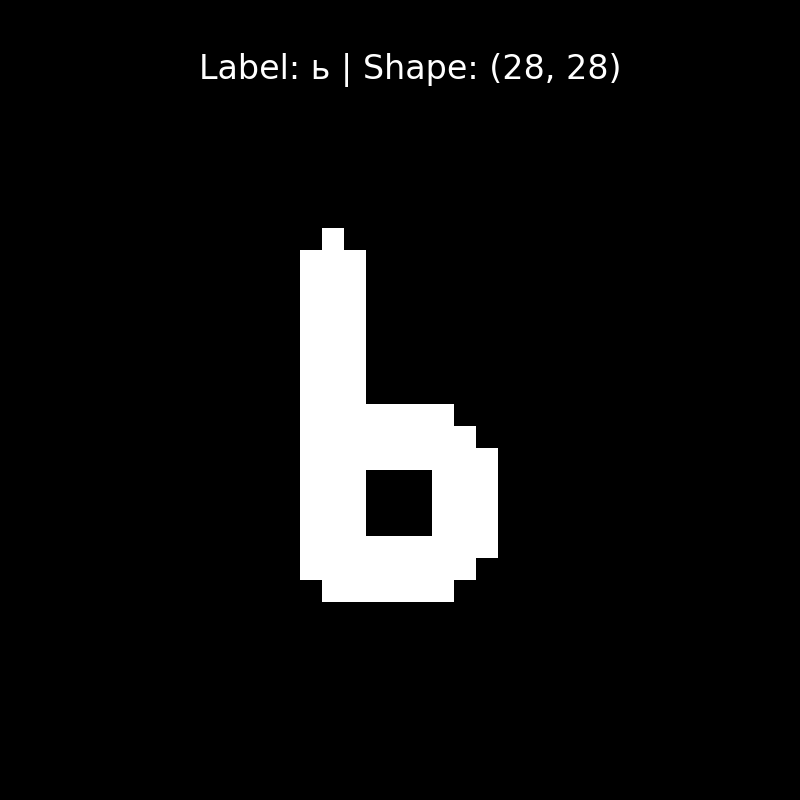

In [63]:
# Генерация изображений
img = generator.generate_ь()
label = 'ь'
plot_single_image(img, label)

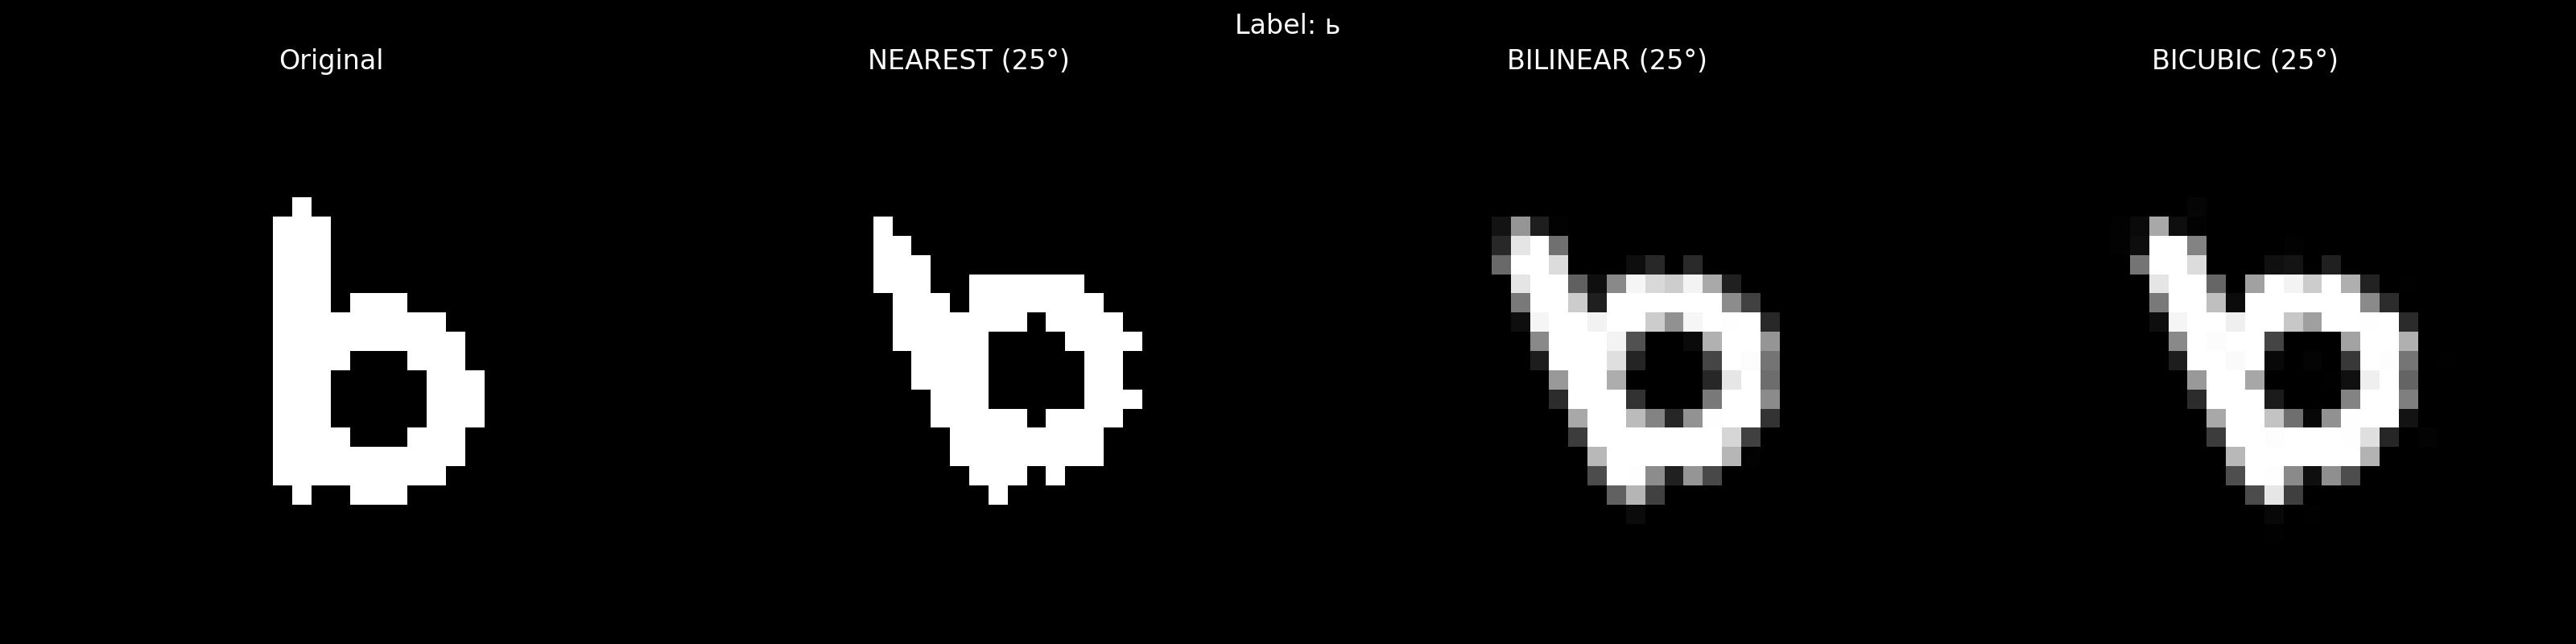

In [64]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ь'])
plot_rotated_with_interpolations(img, label, angle=25)

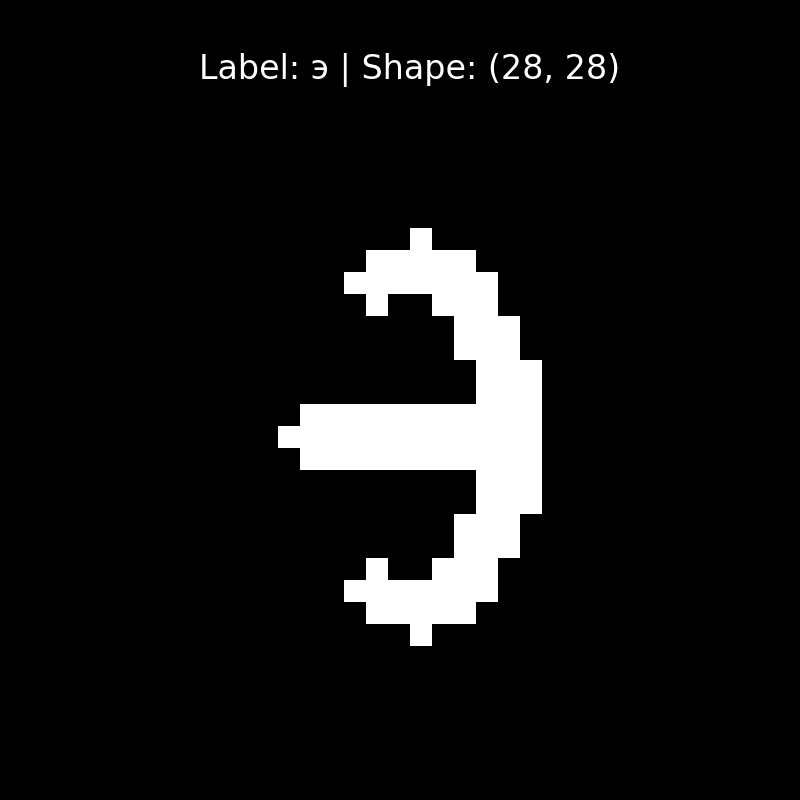

In [65]:
# Генерация изображений
img = generator.generate_э()
label = 'э'
plot_single_image(img, label)

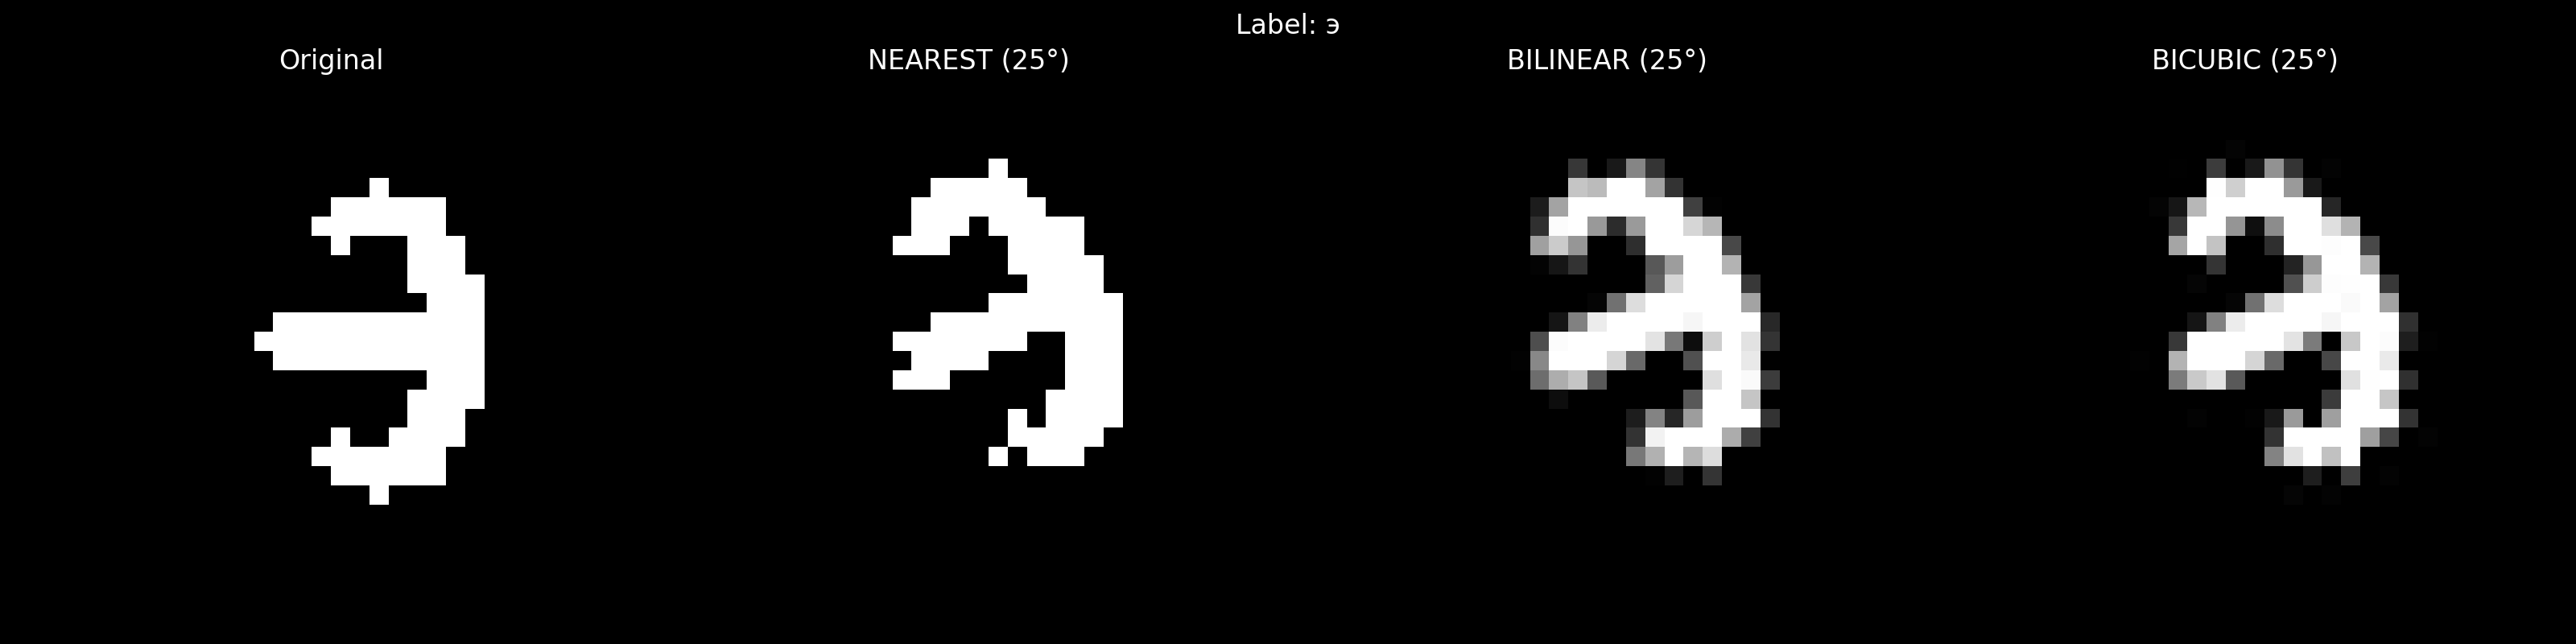

In [66]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['э'])
plot_rotated_with_interpolations(img, label, angle=25)

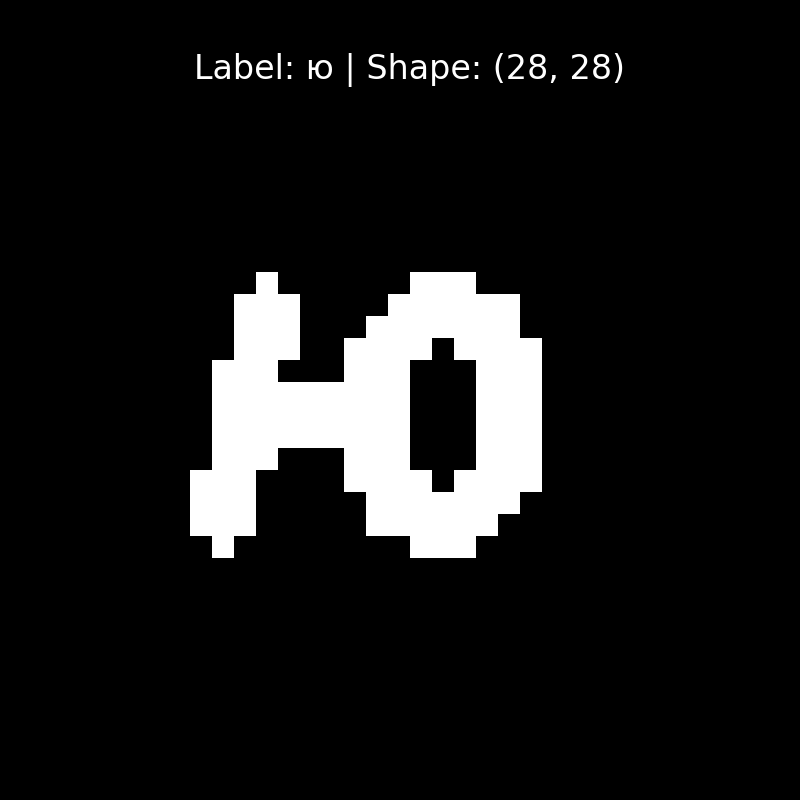

In [67]:
# Генерация изображений
img = generator.generate_ю()
label = 'ю'
plot_single_image(img, label)

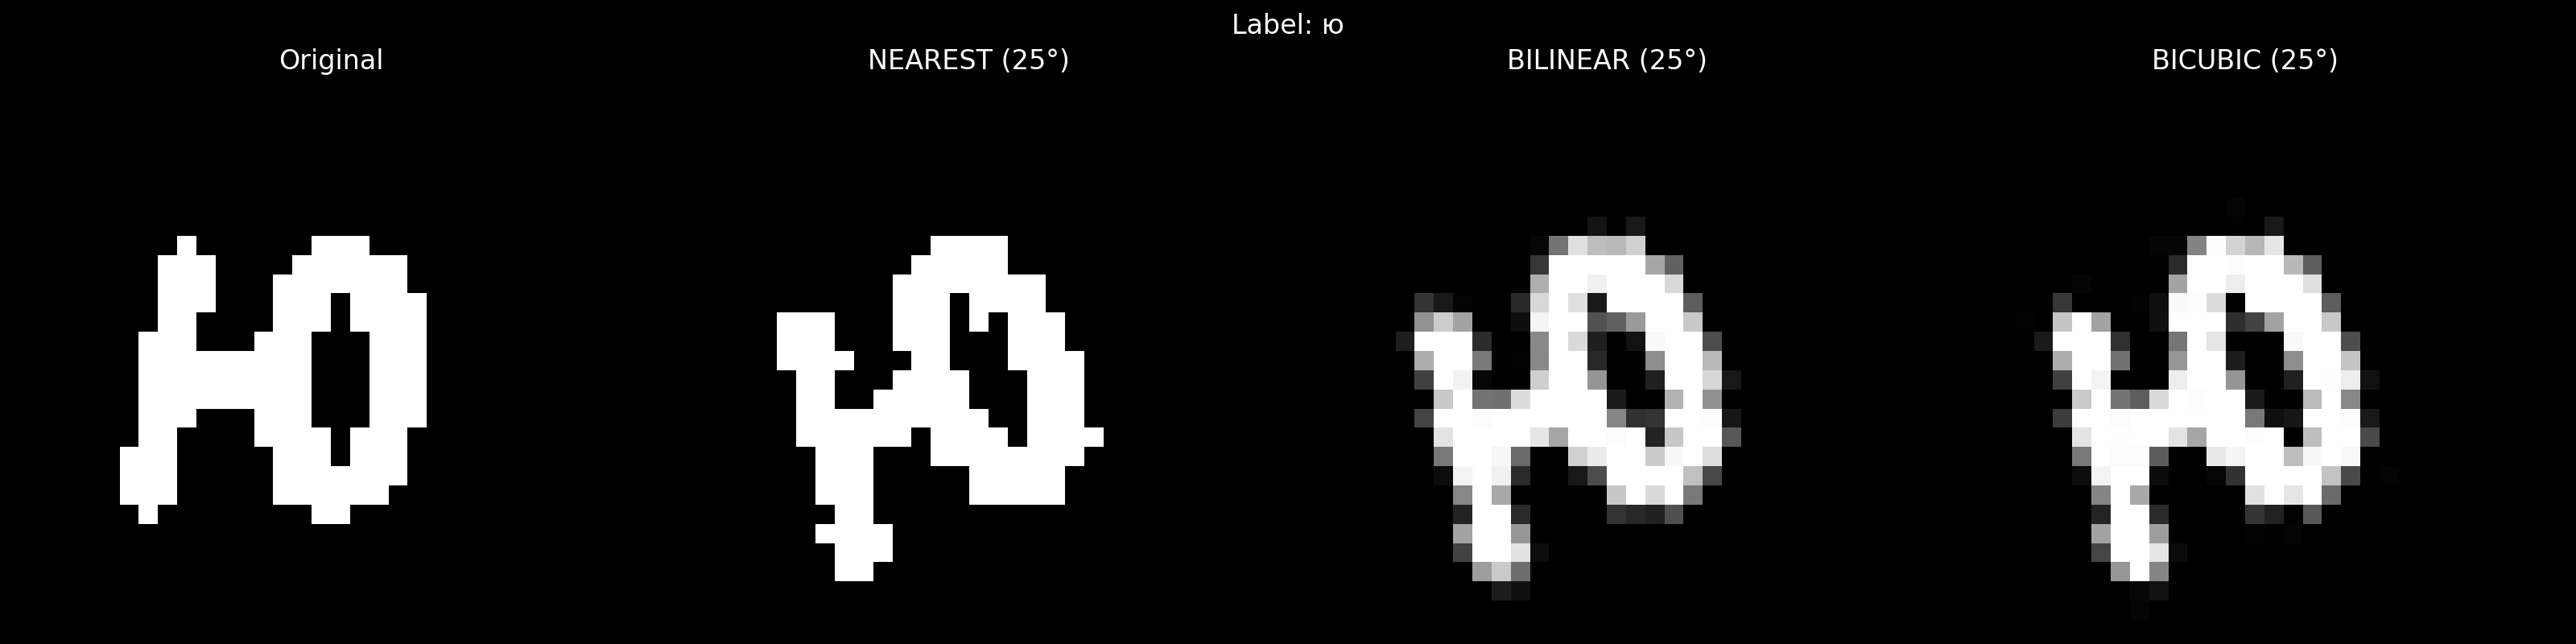

In [68]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['ю'])
plot_rotated_with_interpolations(img, label, angle=25)

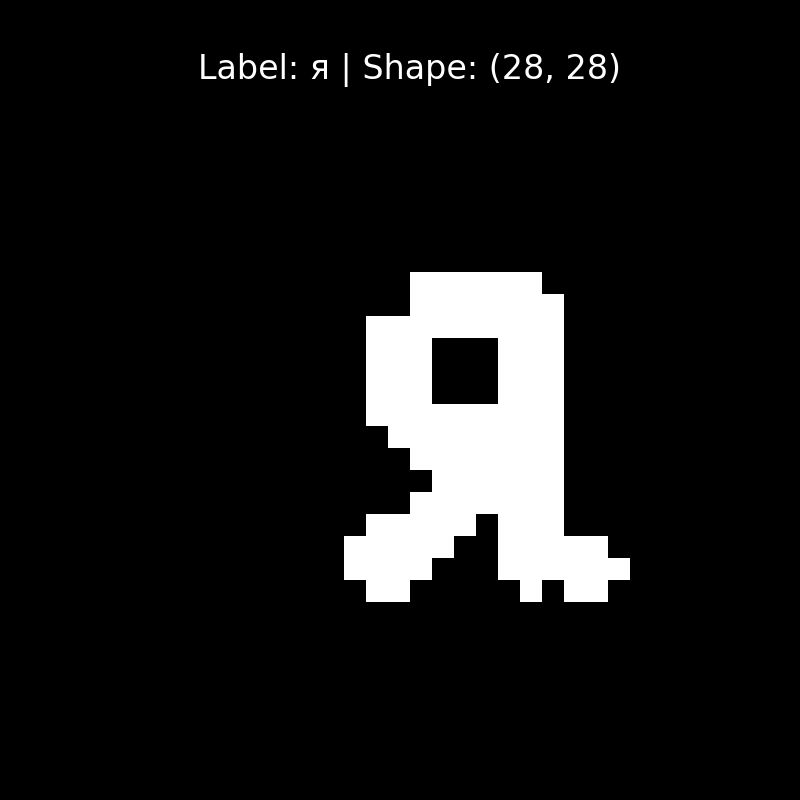

In [69]:
# Генерация изображений
img = generator.generate_я()
label = 'я'
plot_single_image(img, label)

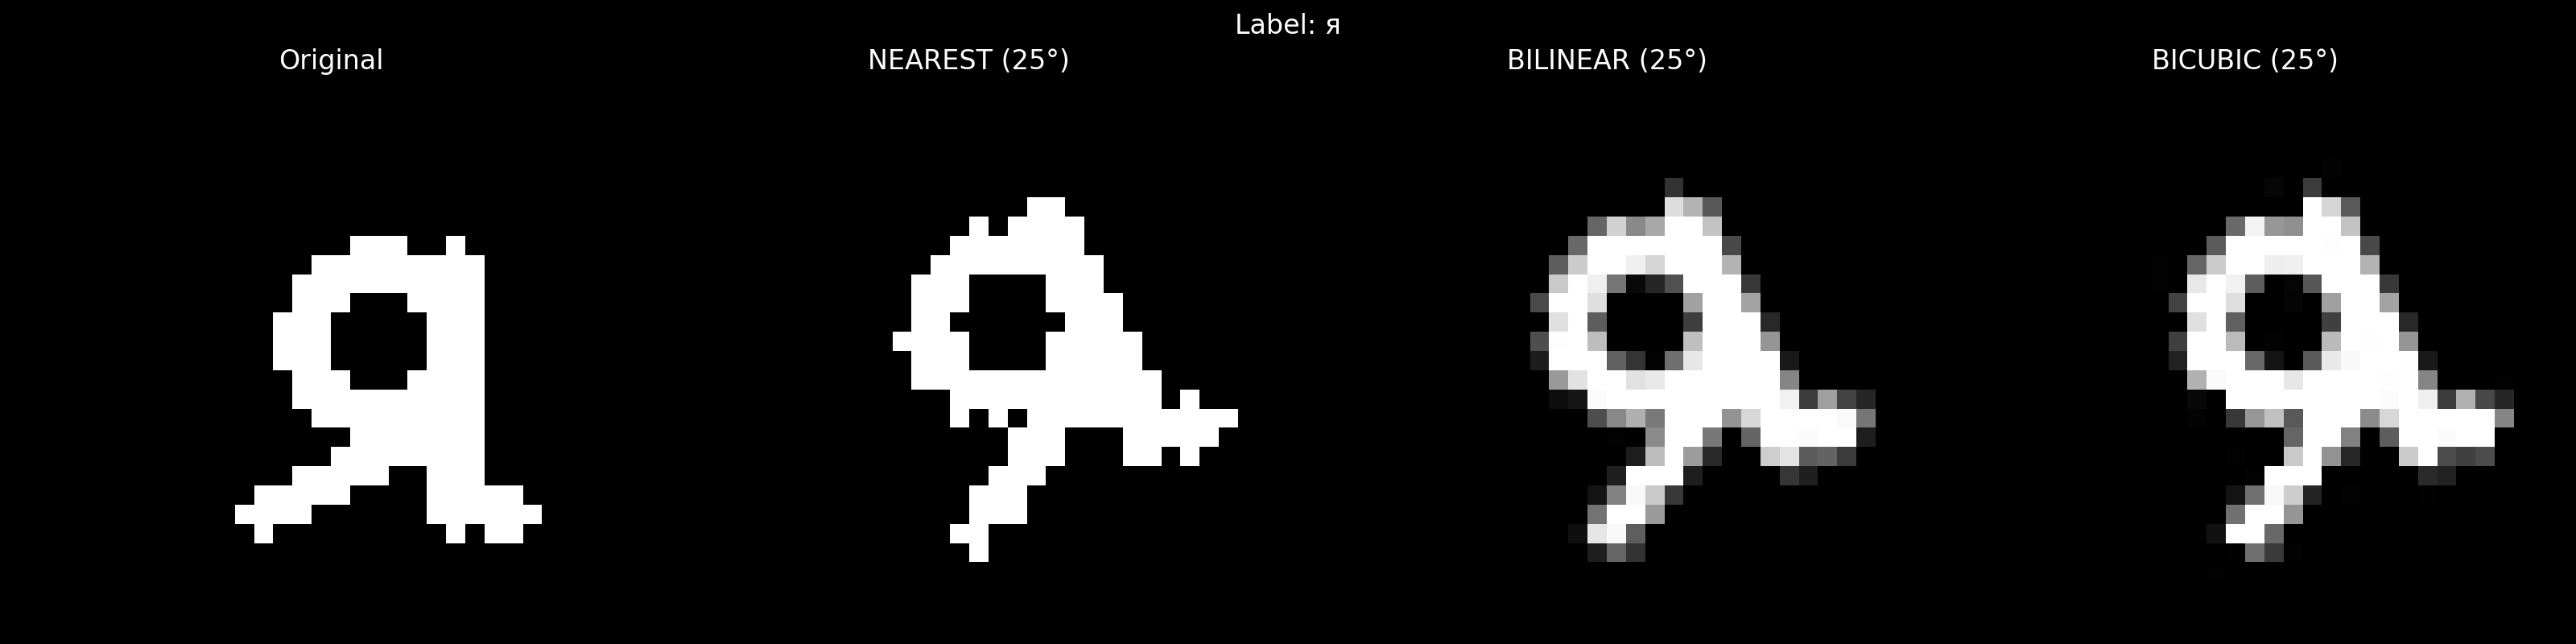

In [70]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['я'])
plot_rotated_with_interpolations(img, label, angle=25)